In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt


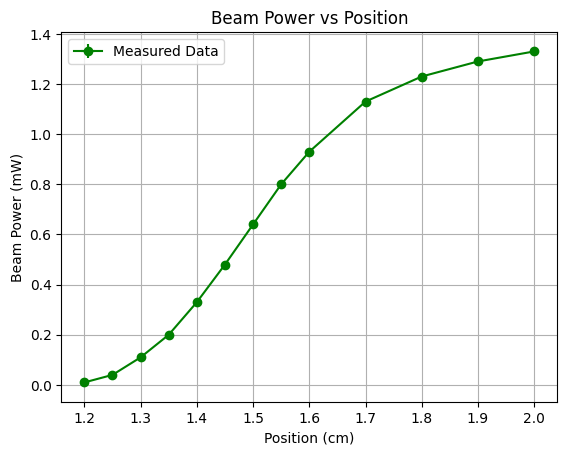

In [5]:
#measure position in x-axis in cm and beam-power in mW in y axis
position_razor = np.array([2.0, 1.9, 1.8, 1.7, 1.6, 1.55, 1.5, 1.45, 1.4, 1.35, 1.3, 1.25, 1.2])
power = np.array([1.33, 1.29, 1.23,1.13, 0.93, 0.80,  0.64, 0.48, 0.33, 0.20, 0.11, 0.04, 0.01 ])
position_razor_err = np.array([0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001 ])
power_err = np.array([0.01,  0.01, 0.01, 0.01, 0.01, 0.01,  0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01 ])
plt.errorbar(position_razor, power, xerr=position_razor_err, yerr=power_err, fmt='o-', label='Measured Data', color = "green")
plt.title('Beam Power vs Position')
plt.xlabel('Position (cm)')
plt.ylabel('Beam Power (mW)')
plt.grid()
plt.legend()
plt.savefig('beam_power_vs_position.png')
plt.show()

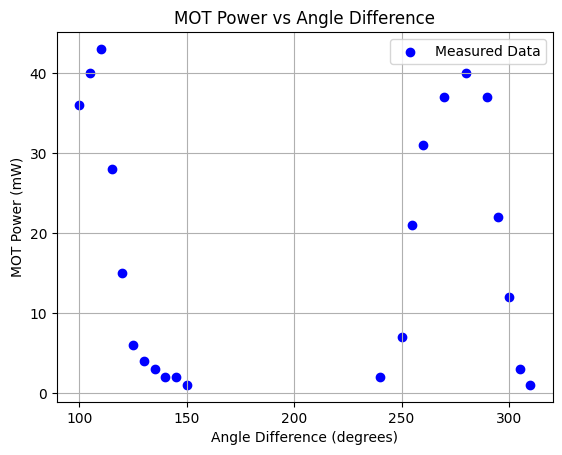

In [9]:
#2nd plot of the experiment
#MOT power in mW in y-axis and angle difference of the MOT in cm in x-axis
angle_diff = np.array([100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 240, 250, 255, 260, 270, 280, 290,295, 300, 305, 310])
mot_power = np.array([115, 119, 122, 107, 94, 85, 83, 82, 81, 81 ,80, 81, 86,100, 110, 116, 119, 116, 101, 91,82, 80 ]) #background = 79
mot_power = mot_power - 79 # subtracting the background power of 79 mW
angle_diff_err = np.array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01])
mot_power_err = np.array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10])
plt.scatter(angle_diff, mot_power,   label='Measured Data', color = "blue")
plt.title('MOT Power vs Angle Difference')
plt.xlabel('Angle Difference (degrees)')
plt.ylabel('MOT Power (mW)')
plt.grid()
plt.legend()
plt.show()

Fit parameters:
A = -80.7673 ± 14.8299
b = 0.018208 ± 0.000534
c = -0.2918 ± 0.1299
d = 33.0839 ± 3.2453
Reduced chi-squared: 0.74


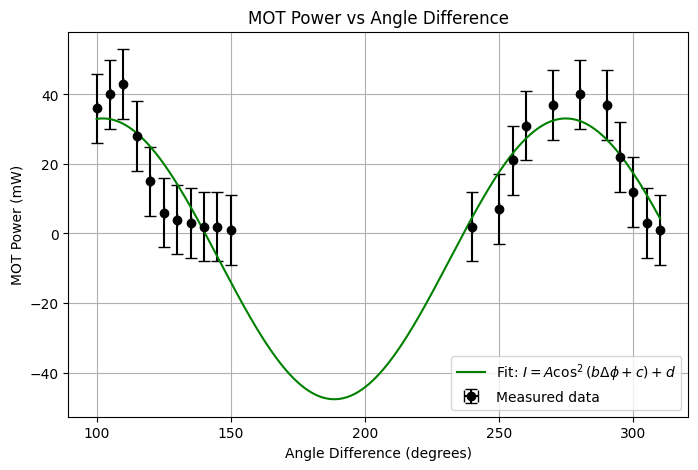

In [11]:

from scipy.optimize import curve_fit

# Data
angle_diff = np.array([100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150,
                       240, 250, 255, 260, 270, 280, 290, 295, 300, 305, 310])

mot_power = np.array([115, 119, 122, 107, 94, 85, 83, 82, 81, 81, 80,
                      81, 86, 100, 110, 116, 119, 116, 101, 91, 82, 80])

# subtract background
mot_power = mot_power - 79

# Errors: must match the length of the data arrays
angle_diff_err = np.full(len(angle_diff), 0.01)
mot_power_err = np.full(len(mot_power), 10.0)

# Model: I = A * cos^2(b * Δφ + c) + d
def cos2_model(phi, A, b, c, d):
    return A * np.cos(b * phi + c)**2 + d

# Initial guesses
# A ~ amplitude, d ~ offset
# b ~ period factor. Since cos^2 has period pi in its argument,
# and your data look roughly periodic over ~180 degrees,
# a reasonable starting guess is b ~ pi/180.
p0 = [45, np.pi/180, 0, 0]

# Fit
popt, pcov = curve_fit(
    cos2_model,
    angle_diff,
    mot_power,
    sigma=mot_power_err,
    absolute_sigma=True,
    p0=p0,
    maxfev=10000
)

# Best-fit parameters and uncertainties
A_fit, b_fit, c_fit, d_fit = popt
A_err, b_err, c_err, d_err = np.sqrt(np.diag(pcov))
# reduced chi squared
residuals = mot_power - cos2_model(angle_diff, *popt)
chi_squared = np.sum((residuals / mot_power_err) ** 2)
dof = len(mot_power) - len(popt)  # degrees of freedom
reduced_chi_squared = chi_squared / dof

print("Fit parameters:")
print(f"A = {A_fit:.4f} ± {A_err:.4f}")
print(f"b = {b_fit:.6f} ± {b_err:.6f}")
print(f"c = {c_fit:.4f} ± {c_err:.4f}")
print(f"d = {d_fit:.4f} ± {d_err:.4f}")
print(f"Reduced chi-squared: {reduced_chi_squared:.2f}")

# Smooth curve for plotting
phi_fit = np.linspace(min(angle_diff), max(angle_diff), 1000)
I_fit = cos2_model(phi_fit, *popt)

# Plot
plt.figure(figsize=(8, 5))
plt.errorbar(
    angle_diff,
    mot_power,
    xerr=angle_diff_err,
    yerr=mot_power_err,
    fmt='o',
    color='black',
    capsize=4,
    label='Measured data'
)
plt.plot(phi_fit, I_fit, label='Fit: $I = A\\cos^2(b\\Delta\\phi + c) + d$', color = "green")

plt.title('MOT Power vs Angle Difference')
plt.xlabel('Angle Difference (degrees)')
plt.ylabel('MOT Power (mW)')
plt.grid(True)
plt.legend()
plt.savefig('mot_power_vs_angle_difference_fit.png')
plt.show()

In [6]:
print(len(angle_diff))
print(
len(mot_power))

24
22


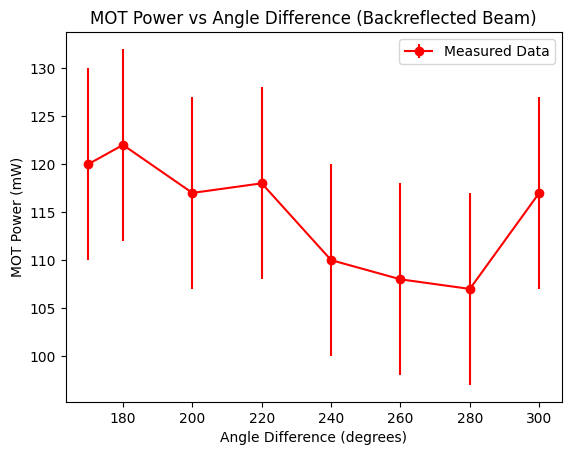

In [13]:
degree = np.array([170, 180,200,  220, 240, 260, 280, 300])
power = np.array([120,122,117, 118, 110, 108, 107, 117 ]) #background = 78
power_err = np.array([10, 10, 10, 10, 10, 10, 10, 10])
# go from 145 in 95 in y axis
plt.errorbar(degree, power, yerr=power_err, fmt='o-', label='Measured Data', color = "red")

plt.title('MOT Power vs Angle Difference (Backreflected Beam)')
plt.xlabel('Angle Difference (degrees)')
plt.ylabel('MOT Power (mW)')
plt.legend()
plt.savefig('mot_power_vs_angle_difference_backreflected.png')
plt.show()

Linear fit coefficients:
Slope: 30.6116 nW/A
Intercept: 25.3909 nW
Reduced chi-squared: 0.11


Text(0.5, 1.0, 'MOT Power vs Helmholtz Current')

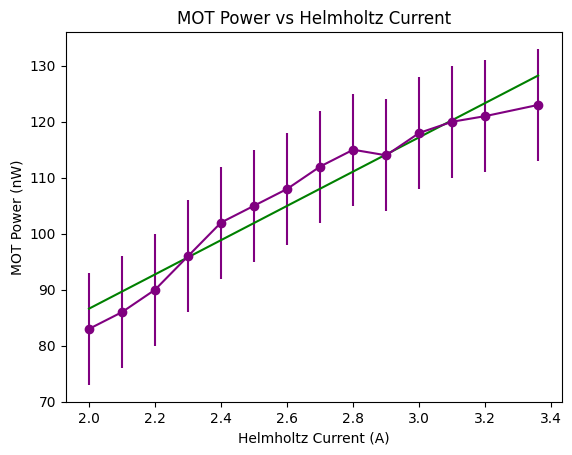

In [16]:
current = np.array([ 3.36, 3.2, 3.1, 3 , 2.9, 2.8, 2.7, 2.6, 2.5, 2.4, 2.3, 2.2, 2.1, 2]) #Ampere
current_err = 0.001* current # assuming 0.1% error in current measurement
power = np.array([123, 121, 120, 118, 114, 115, 112, 108, 105, 102 , 96, 90, 86,  83]) #nWatt
#background = 79
power_err = np.array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10])  
#plotting the data with error bars, x-axis is current and y-axis is power in nWatt, with error bars of 10 nWatt without a line passing through the points
plt.errorbar(current, power, xerr=current_err, yerr=power_err, fmt='o-', label='Measured Data', color = "purple")
#fit a linear line to the data
coefficients = np.polyfit(current, power, 1)
linear_fit = np.poly1d(coefficients)
current_fit = np.linspace(min(current), max(current), 100)
power_fit = linear_fit(current_fit)
#print the coefficients of the linear fit
print("Linear fit coefficients:")
print(f"Slope: {coefficients[0]:.4f} nW/A")
print(f"Intercept: {coefficients[1]:.4f} nW")
#reduced chi squared
residuals = power - linear_fit(current)
chi_squared = np.sum((residuals / power_err) ** 2)
dof = len(power) - len(coefficients)  # degrees of freedom
reduced_chi_squared = chi_squared / dof
print(f"Reduced chi-squared: {reduced_chi_squared:.2f}")    


plt.plot(current_fit, power_fit, label='Linear Fit', color = "green")
plt.xlabel('Helmholtz Current (A)')
plt.ylabel('MOT Power (nW)')
plt.savefig('mot_power_vs_helmholtz_current.png')
plt.title('MOT Power vs Helmholtz Current')

In [32]:
len(current)

14

# Laser Spectroscopy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.optimize import curve_fit


Linear fit coefficients:
Slope: 63.8877 µW/mA
Intercept: -3015.0130 µW
Reduced chi-squared: 3.07


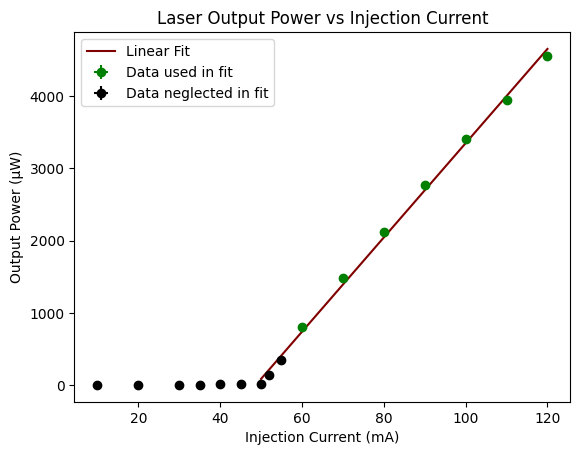

In [21]:

injection_current = np.array([10, 20, 30, 35, 40, 45, 50,52,  55, 60, 70, 80, 90, 100, 110, 120]) #mAmpere
output_power = np.array([0.457,2.395, 4.686, 5.848, 7.01, 8.16, 9.29,  140.6, 340.4, 808, 1483, 2118, 2770, 3410, 3947, 4559   ]) #microWatt
output_power_err = output_power * 1/100 # assuming 1% error in power measurement
injection_current_err = 0.1 #mAmpere, assuming 0.1 mA error in current measurement
background = 0
#fit a linear line to the data neglecting first six points 
mask = injection_current >= 60
x = injection_current[mask]
y = output_power[mask]
sigma = output_power_err[mask]

coefficients = np.polyfit(x, y, 1, w=1/sigma)
linear_fit = np.poly1d(coefficients)

residuals = y - linear_fit(x)
chi_squared = np.sum((residuals / sigma)**2)
dof = len(y) - 2
reduced_chi_squared = chi_squared / dof
#print the coefficients of the linear fit
print("Linear fit coefficients:")
print(f"Slope: {coefficients[0]:.4f} µW/mA")
print(f"Intercept: {coefficients[1]:.4f} µW")
#reduced chi squared for only linear fit without the first six points
residuals = output_power[mask] - linear_fit(injection_current[mask])
chi_squared = np.sum((residuals / output_power_err[mask]) ** 2)
dof = len(output_power[mask]) - len(coefficients)  # degrees of freedom
reduced_chi_squared = chi_squared / dof

print(f"Reduced chi-squared: {reduced_chi_squared:.2f}")
plt.plot(current_fit, power_fit, label='Linear Fit', color = "maroon")
#plot data points with errorbars after the first six points, x-axis is injection current and y-axis is output power in microWatt, with error bars of 1/1000 of the output power without a line passing through the points and in legends have points in the fit and have points neglected in the fit
plt.errorbar(injection_current[mask], output_power[mask], yerr=output_power_err[mask], xerr=injection_current_err, fmt='o', label='Data used in fit', color = "green")
plt.errorbar(injection_current[~mask], output_power[~mask], yerr=output_power_err[~mask], xerr=injection_current_err, fmt='o', label='Data neglected in fit', color = "black")
plt.xlabel('Injection Current (mA)')
plt.ylabel('Output Power (µW)')
plt.title('Laser Output Power vs Injection Current')
plt.legend()
plt.savefig('laser_output_power_vs_injection_current.png')
plt.show()

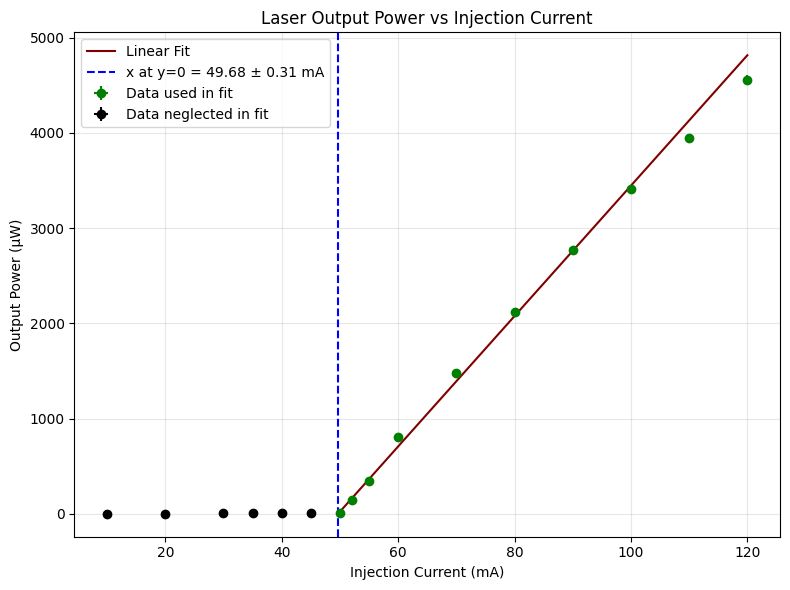

Linear fit coefficients:
Slope: 68.4820 ± 1.5742 µW/mA
Intercept: -3401.8874 ± 90.8626 µW
Reduced chi-squared: 2478.65
x-value where y = 0: 49.6756 ± 0.3073 mA


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr

# ----------------------------
# Data
# ----------------------------
injection_current = np.array([10, 20, 30, 35, 40, 45, 50, 52, 55, 60, 70, 80, 90, 100, 110, 120])  # mA
output_power = np.array([0.457, 2.395, 4.686, 5.848, 7.01, 8.16, 9.29, 140.6, 340.4, 808, 1483, 2118, 2770, 3410, 3947, 4559])  # µW

output_power_err = output_power * 0.01      # 1% error in power
injection_current_err = 0.1                 # mA
background = 0

# ----------------------------
# Choose linear region
# ----------------------------
mask = injection_current >= 50
x = injection_current[mask]
y = output_power[mask]
sx = np.full_like(x, injection_current_err, dtype=float)
sy = output_power_err[mask]

# ----------------------------
# Define linear model for ODR
# y = m*x + b
# ----------------------------
def linear_model(B, x):
    return B[0] * x + B[1]

model = odr.Model(linear_model)
data = odr.RealData(x, y, sx=sx, sy=sy)

# Initial guess from ordinary polyfit
beta0 = np.polyfit(x, y, 1)

odr_fit = odr.ODR(data, model, beta0=beta0)
output = odr_fit.run()

m, b = output.beta
m_err, b_err = output.sd_beta

# Covariance matrix of fit parameters
cov = output.cov_beta * output.res_var
var_m = cov[0, 0]
var_b = cov[1, 1]
cov_mb = cov[0, 1]

# ----------------------------
# Reduced chi-squared
# ----------------------------
residuals = y - linear_model(output.beta, x)
chi_squared = np.sum((residuals / sy) ** 2)
dof = len(x) - 2
reduced_chi_squared = chi_squared / dof

# ----------------------------
# x-intercept (threshold current): y = 0
# 0 = m*x + b  --> x0 = -b/m
# ----------------------------
x0 = -b / m

# Error propagation including covariance:
# x0 = -b/m
# dx0/dm = b/m^2
# dx0/db = -1/m
x0_var = (b / m**2)**2 * var_m + (1 / m**2) * var_b - 2 * (b / m**3) * cov_mb
x0_err = np.sqrt(x0_var)

# ----------------------------
# Plot
# ----------------------------
current_fit = np.linspace(np.min(x), np.max(x), 300)
power_fit = linear_model(output.beta, current_fit)

plt.figure(figsize=(8, 6))
plt.plot(current_fit, power_fit, label='Linear Fit', color='maroon')

plt.errorbar(
    injection_current[mask],
    output_power[mask],
    yerr=output_power_err[mask],
    xerr=injection_current_err,
    fmt='o',
    label='Data used in fit',
    color='green'
)

plt.errorbar(
    injection_current[~mask],
    output_power[~mask],
    yerr=output_power_err[~mask],
    xerr=injection_current_err,
    fmt='o',
    label='Data neglected in fit',
    color='black'
)

# Mark x-intercept on graph
plt.axvline(x0, color='blue', linestyle='--', label=f'x at y=0 = {x0:.2f} ± {x0_err:.2f} mA')

plt.xlabel('Injection Current (mA)')
plt.ylabel('Output Power (µW)')
plt.title('Laser Output Power vs Injection Current')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('laser_output_power_vs_injection_current.png', dpi=300)
plt.show()

# ----------------------------
# Print results
# ----------------------------
print("Linear fit coefficients:")
print(f"Slope: {m:.4f} ± {m_err:.4f} µW/mA")
print(f"Intercept: {b:.4f} ± {b_err:.4f} µW")
print(f"Reduced chi-squared: {reduced_chi_squared:.2f}")
print(f"x-value where y = 0: {x0:.4f} ± {x0_err:.4f} mA")

In [24]:
import numpy as np

# Constants
e = 1.602176634e-19      # C
h = 6.62607015e-34       # J·s
c = 2.99792458e8         # m/s
lam = 794e-9             # m

# Fit results (your values)
slope = 65.333           # µW/mA
slope_err = 0.22         # µW/mA  (replace with your actual fit error)

# Unit conversion:
# µW/mA -> W/A  (important!)
slope_SI = slope * 1e-3
slope_err_SI = slope_err * 1e-3

# Quantum efficiency
Q = (e * lam / (h * c)) * slope_SI

# Uncertainty propagation (linear scaling)
Q_err = Q * (slope_err_SI / slope_SI)

print(f"Quantum efficiency = {Q:.4f} ± {Q_err:.4f}")
print(f"In percent: {Q*100:.2f} ± {Q_err*100:.2f} %")

Quantum efficiency = 0.0418 ± 0.0001
In percent: 4.18 ± 0.01 %


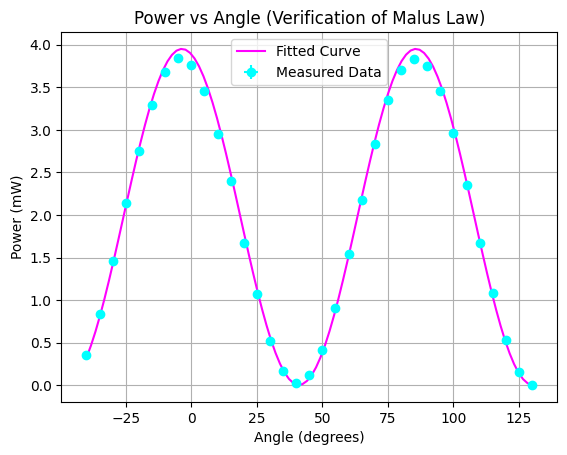

Reduced Chi-Squared: 178.89
Fitted Parameters:
P0: -3.946 mW
Offset: 3.951 mW
Phi_0: 41.036 degrees
a: 2.017


In [29]:
#verification of malus law
angle = np.array([-40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130]) # in degrees
power = np.array([ 0.354 ,0.835 ,1.464 , 2.136, 2.749 , 3.293, 3.676,3.839,3.767, 3.462, 2.95, 2.394, 1.676, 1.070, 0.521, 0.168, 0.026, 0.122, 0.419, 0.912, 1.537, 2.178, 2.831, 3.351, 3.7, 3.836, 3.75, 3.454, 2.961, 2.355, 1.67 , 1.083, 0.537, 0.157, 0.005]) # in mW
background =0 
power_err = power * 1/100
angle_error = 1



#fitting cos squared with offset
def malus_law(angle, P0, offset, phi_0, a):
    return P0 * np.cos(np.radians(angle-phi_0)*a)**2 + offset
from scipy.optimize import curve_fit
# Fit the Malus law function to the data by setting amplitude to be 3.8 forcedly and offset to be 0, and phi_0 to be 0, and a to be 1 approximately
popt, pcov = curve_fit(malus_law, angle, power, sigma=power_err, absolute_sigma=True, p0=[3.8, 0, 0, 1], maxfev=1000)
P0_fit, offset_fit, phi_0_fit, a_fit = popt
# Generate fitted intensity values using the fitted parameters
angle_fit = np.linspace(-40, 130, 100)
power_fit = malus_law(angle_fit, P0_fit, offset_fit, phi_0_fit, a_fit)
# Plot the original data and the fitted curve
plt.errorbar(angle, power, yerr=power_err, xerr=angle_error, fmt='o', label='Measured Data', color = "cyan")
plt.plot(angle_fit, power_fit, label='Fitted Curve', color='magenta')   
plt.title('Power vs Angle (Verification of Malus Law)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Power (mW)')
plt.legend()
plt.grid()
plt.show()

#value of reduced chi squared
residuals = power - malus_law(angle, *popt)
chi_squared = np.sum((residuals / power_err) ** 2)
degrees_of_freedom = len(angle) - len(popt)
reduced_chi_squared = chi_squared / degrees_of_freedom
print(f"Reduced Chi-Squared: {reduced_chi_squared:.2f}")

#value of our fitted parameters
print(f"Fitted Parameters:")
print(f"P0: {P0_fit:.3f} mW")
print(f"Offset: {offset_fit:.3f} mW")
print(f"Phi_0: {phi_0_fit:.3f} degrees")
print(f"a: {a_fit:.3f}")


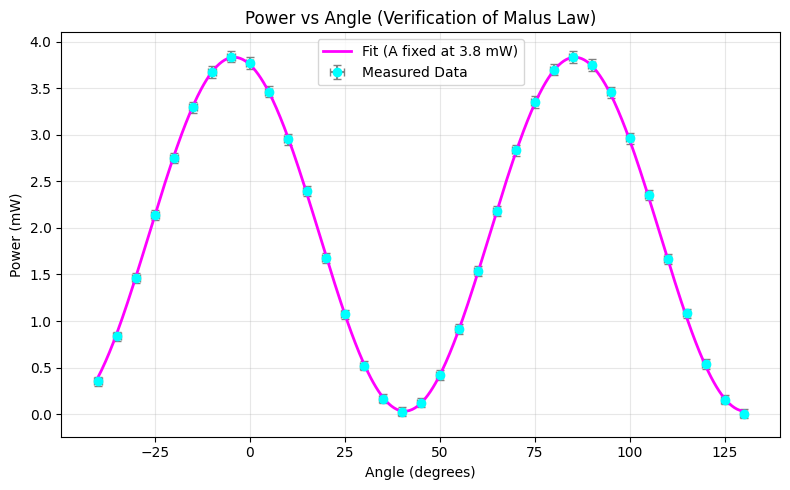

Fitted parameters (with amplitude fixed at 3.8 mW):
Amplitude A = 3.800 mW (fixed)
Offset     = 0.0316 ± 0.0101 mW
Phi_0      = 85.6142 ± 0.1332 degrees
a          = 2.0070 ± 0.0041
Reduced chi-squared = 0.147
Reduced chi-squared error: ± 0.037


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------
# Data
# -----------------------
angle = np.array([
    -40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35,
    40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130
], dtype=float)

power = np.array([
    0.354, 0.835, 1.464, 2.136, 2.749, 3.293, 3.676, 3.839, 3.767, 3.462,
    2.95, 2.394, 1.676, 1.070, 0.521, 0.168, 0.026, 0.122, 0.419, 0.912,
    1.537, 2.178, 2.831, 3.351, 3.7, 3.836, 3.75, 3.454, 2.961, 2.355,
    1.67, 1.083, 0.537, 0.157, 0.005
], dtype=float)

angle_error = 1.0  # degrees

# -----------------------
# More realistic uncertainty model
# 1% relative + 0.05 mW floor
# -----------------------
power_err = np.sqrt((0.01 * power)**2 + 0.05**2)

# -----------------------
# Malus-type model with amplitude fixed to 3.8 mW
# -----------------------
A_fixed = 3.8

def malus_fixed_amp(theta, offset, phi0, a):
    return A_fixed * np.cos(np.radians(theta - phi0) * a)**2 + offset

# Initial guesses:
# offset ~ 0
# phi0 ~ 85 deg works well with your data
# a ~ 2 because the observed period is ~90 deg
p0 = [0.0, 85.0, 2.0]

# Reasonable bounds
bounds = ([-0.2, -180.0, 1.5], [0.2, 180.0, 2.5])

popt, pcov = curve_fit(
    malus_fixed_amp,
    angle,
    power,
    sigma=power_err,
    absolute_sigma=True,
    p0=p0,
    bounds=bounds,
    maxfev=10000
)

offset_fit, phi0_fit, a_fit = popt
offset_err, phi0_err, a_err = np.sqrt(np.diag(pcov))

# -----------------------
# Fitted curve
# -----------------------
angle_fit = np.linspace(angle.min(), angle.max(), 500)
power_fit = malus_fixed_amp(angle_fit, *popt)

# -----------------------
# Reduced chi-squared
# -----------------------
residuals = power - malus_fixed_amp(angle, *popt)
chi_squared = np.sum((residuals / power_err)**2)
dof = len(angle) - len(popt)
reduced_chi_squared = chi_squared / dof

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8, 5))
plt.errorbar(
    angle, power,
    yerr=power_err,
    xerr=angle_error,
    fmt='o',
    color='cyan',
    ecolor='gray',
    capsize=3,
    label='Measured Data'
)
plt.plot(angle_fit, power_fit, color='magenta', lw=2, label='Fit (A fixed at 3.8 mW)')
plt.title('Power vs Angle (Verification of Malus Law)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Power (mW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('malus_law_fit_fixed_amplitude.png', dpi=300)
plt.show()

# -----------------------
# Output
# -----------------------
print("Fitted parameters (with amplitude fixed at 3.8 mW):")
print(f"Amplitude A = {A_fixed:.3f} mW (fixed)")
print(f"Offset     = {offset_fit:.4f} ± {offset_err:.4f} mW")
print(f"Phi_0      = {phi0_fit:.4f} ± {phi0_err:.4f} degrees")
print(f"a          = {a_fit:.4f} ± {a_err:.4f}")
print(f"Reduced chi-squared = {reduced_chi_squared:.3f}")
#error on reduced chi squared
reduced_chi_squared_err = reduced_chi_squared * np.sqrt(2 / dof)
print(f"Reduced chi-squared error: ± {reduced_chi_squared_err:.3f}")

In [ ]:
pump_beam_power = np.array([4.7, 3.4,  3, 1.7, 0.9, 0.7, 2.2, 2.0, 1.2 ]) #mW
power_err = 0.1
data_name = np.array([27,28,29, 30, 31, 32, 33, 34, 35]) 


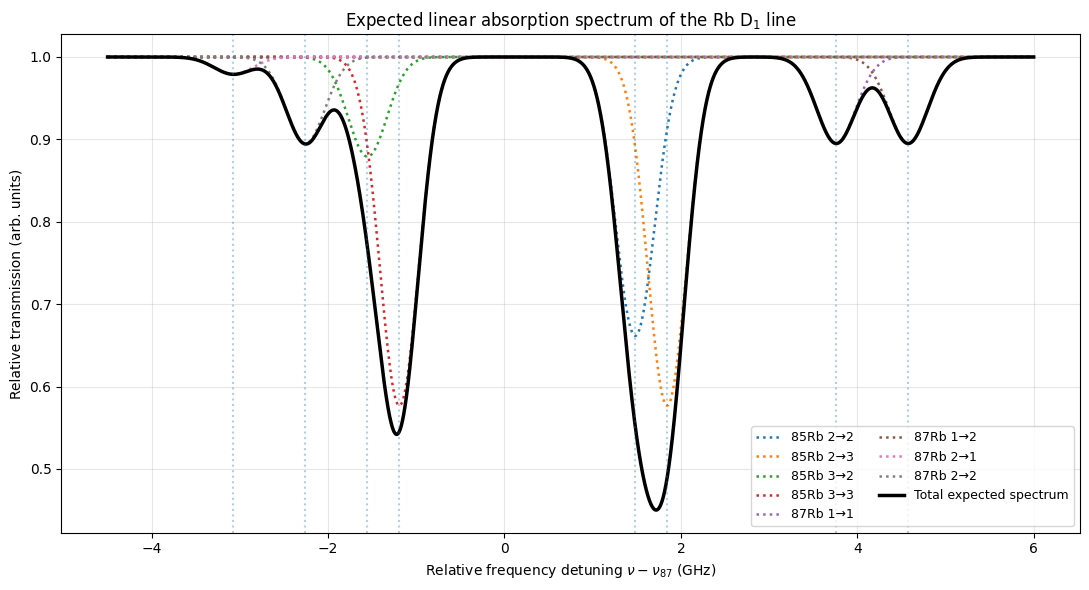

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Expected linear absorption spectrum of Rb D1 line
# 8 individual Doppler-broadened absorption dips + total sum
# Frequencies are in GHz
# ------------------------------------------------------------

# Hyperfine transition offsets relative to each isotope's own center
rb85_lines = {
    "85Rb 2→2":  1.55992,
    "85Rb 2→3":  1.92150,
    "85Rb 3→2": -1.47581,
    "85Rb 3→3": -1.11423,
}

rb87_lines = {
    "87Rb 1→1":  3.761267,
    "87Rb 1→2":  4.577923,
    "87Rb 2→1": -3.073416,
    "87Rb 2→2": -2.256760,
}

# Relative transition strengths from the level scheme / report
# Chosen to match the usual ordering above
rb85_strengths = {
    "85Rb 2→2": 56,
    "85Rb 2→3": 70,
    "85Rb 3→2": 20,
    "85Rb 3→3": 70,
}

rb87_strengths = {
    "87Rb 1→1": 45,
    "87Rb 1→2": 45,
    "87Rb 2→1": 9,
    "87Rb 2→2": 45,
}

# Natural abundances
abundance_85 = 0.7217
abundance_87 = 0.2783

# Isotope shift: nu_87 - nu_85
# Literature value from the report: ~77.69 MHz = 0.07769 GHz
isotope_shift = 0.07769  # GHz

# Put 87Rb center at 0 GHz, shift 85Rb accordingly to the left
rb87_center_shift = 0.0
rb85_center_shift = -isotope_shift

# Doppler width parameter (Gaussian sigma, in GHz)
# Around 0.2-0.3 GHz gives realistic overlap; adjust if wanted
sigma = 0.22

# Frequency axis
x = np.linspace(-4.5, 6.0, 4000)

def gaussian_dip(x, x0, amp, sigma):
    """Positive-valued absorption contribution."""
    return amp * np.exp(-0.5 * ((x - x0) / sigma) ** 2)

# Store individual curves
individual_curves = []

# Build 85Rb curves
for label, nu0 in rb85_lines.items():
    amp = abundance_85 * rb85_strengths[label]
    x0 = nu0 + rb85_center_shift
    y = gaussian_dip(x, x0, amp, sigma)
    individual_curves.append((label, x0, y))

# Build 87Rb curves
for label, nu0 in rb87_lines.items():
    amp = abundance_87 * rb87_strengths[label]
    x0 = nu0 + rb87_center_shift
    y = gaussian_dip(x, x0, amp, sigma)
    individual_curves.append((label, x0, y))

# Total absorption = sum of all individual absorption curves
total_absorption = np.zeros_like(x)
for _, _, y in individual_curves:
    total_absorption += y

# Convert to transmission-like signal if desired
# Baseline = 1, dips downward
scale = total_absorption.max()
transmission = 1.0 - 0.55 * total_absorption / scale

# Individual transmission contributions for plotting as dotted lines
individual_transmissions = []
for label, x0, y in individual_curves:
    ti = 1.0 - 0.55 * y / scale
    individual_transmissions.append((label, x0, ti))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(11, 6))

# Plot individual dotted curves
for label, x0, ti in individual_transmissions:
    plt.plot(x, ti, linestyle=':', linewidth=1.8, label=label)

# Plot final superposed spectrum
plt.plot(x, transmission, linewidth=2.5, label='Total expected spectrum', color='black')

# Optional: vertical markers at line centers
for label, x0, _ in individual_transmissions:
    plt.axvline(x0, linestyle=':', alpha=0.35)

plt.xlabel(r"Relative frequency detuning $\nu - \nu_{87}$ (GHz)")
plt.ylabel("Relative transmission (arb. units)")
plt.title(r"Expected linear absorption spectrum of the Rb D$_1$ line")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_PATH = "scope_20.csv"

# Fabry-Perot calibrated confocal mode spacing from the manual
FPI_MODE_SPACING_GHZ = 149.9348e-3  # GHz

# Background polynomial degree
# Theodor's linear baseline was effectively low-order/linear.
# Increase to 2, 3, ... if your background is more curved.
POLY_DEGREE = 1

# Savitzky-Golay smoothing parameters
ABS_SAVGOL_WINDOW = 81   # must be odd
ABS_SAVGOL_ORDER  = 3

FPI_SAVGOL_WINDOW = 31   # must be odd
FPI_SAVGOL_ORDER  = 2

TRI_SAVGOL_WINDOW = 101
TRI_SAVGOL_ORDER  = 2

# Peak finding settings for FPI and absorption
FPI_MIN_DISTANCE = 12
FPI_PROMINENCE   = 0.01

ABS_MIN_DISTANCE = 60
ABS_PROMINENCE   = 4e-5

# Whether to fit the descending branch (between triangle max and min)
USE_DESCENDING_BRANCH = True

# ============================================================
# LOAD DATA
# ============================================================

# Scope CSV format:
# row 1: x-axis,1,2,3
# row 2: second,Volt,Volt,Volt
# remaining rows: data
df = pd.read_csv(CSV_PATH, skiprows=[1])
df.columns = ["time_s", "ch1", "ch2", "ch3"]

t_all   = df["time_s"].to_numpy()
abs_all = df["ch1"].to_numpy()   # absorption spectrum
fpi_all = df["ch2"].to_numpy()   # Fabry-Perot
tri_all = df["ch3"].to_numpy()   # triangular scan voltage

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def oddify(n):
    n = int(n)
    return n if n % 2 == 1 else n + 1

def split_monotonic_branch(t, tri, use_descending=True):
    """Use the triangular scan to isolate one monotonic half-scan."""
    tri_s = savgol_filter(tri, oddify(TRI_SAVGOL_WINDOW), TRI_SAVGOL_ORDER)

    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        # rising then falling
        if use_descending:
            sl = slice(i_max, i_min + 1)
        else:
            sl = slice(0, i_max + 1)
    else:
        # falling then rising
        if use_descending:
            sl = slice(i_min, i_max + 1)
        else:
            sl = slice(0, i_min + 1)

    return sl, tri_s

def build_fpi_time_to_freq_calibration(t, fpi):
    """
    Detect FPI peaks and assign equally spaced frequencies:
        nu_n = n * FPI_MODE_SPACING_GHZ
    Then use piecewise linear interpolation t -> nu.
    """
    fpi_s = savgol_filter(fpi, oddify(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, props = find_peaks(
        fpi_s,
        distance=FPI_MIN_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 5:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Try lowering FPI_PROMINENCE or distance."
        )

    t_peaks = t[peak_idx]

    # assign sequential relative frequencies
    nu_peaks = np.arange(len(t_peaks)) * FPI_MODE_SPACING_GHZ

    # piecewise linear calibration
    calib = interp1d(
        t_peaks,
        nu_peaks,
        kind="linear",
        bounds_error=False,
        fill_value="extrapolate"
    )

    return calib, peak_idx, t_peaks, nu_peaks, fpi_s

def poly_background(x, *c):
    # c[0] + c[1] x + c[2] x^2 + ...
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(c):
        y += ci * x**i
    return y

def gaussian_dip(x, A, mu, sigma):
    # A should be negative for dips
    return A * np.exp(-0.5 * ((x - mu)/sigma)**2)

def model_poly_plus_7gauss(x, *p):
    """
    Parameters:
      first (POLY_DEGREE+1) params: polynomial coeffs
      then 7 triplets (A_i, mu_i, sigma_i)
    """
    n_poly = POLY_DEGREE + 1
    coeffs = p[:n_poly]
    rest = p[n_poly:]

    y = poly_background(x, *coeffs)
    for i in range(7):
        A, mu, sigma = rest[3*i:3*i+3]
        y += gaussian_dip(x, A, mu, sigma)
    return y

def get_initial_guess(x, y):
    """
    Build initial guesses:
    - polynomial from simple polyfit
    - 7 absorption dips from smoothed trace
    """
    # rough baseline guess
    poly_guess = np.polyfit(x, y, deg=POLY_DEGREE)
    # np.polyfit returns highest power first; convert to c0,c1,...
    poly_guess = poly_guess[::-1]

    y_s = savgol_filter(y, oddify(ABS_SAVGOL_WINDOW), ABS_SAVGOL_ORDER)

    dip_idx, props = find_peaks(
        -y_s,
        distance=ABS_MIN_DISTANCE,
        prominence=ABS_PROMINENCE
    )

    # Keep the 7 strongest dips
    if len(dip_idx) < 7:
        raise RuntimeError(
            f"Only found {len(dip_idx)} candidate dips. "
            "Lower ABS_PROMINENCE / ABS_MIN_DISTANCE or check branch selection."
        )

    prominences = props["prominences"]
    strongest = np.argsort(prominences)[-7:]
    dip_idx = np.sort(dip_idx[strongest])

    # amplitudes relative to local baseline estimate
    baseline_guess = np.polyval(poly_guess[::-1], x)

    p0 = list(poly_guess)
    xspan = x.max() - x.min()

    for i in dip_idx:
        A0 = min(y[i] - baseline_guess[i], -1e-5)  # negative dip
        mu0 = x[i]
        sigma0 = 0.12  # GHz, good starting point for Doppler-broadened lines
        p0 += [A0, mu0, sigma0]

    return np.array(p0, dtype=float), dip_idx, y_s

def make_bounds(x, y):
    """
    Loose bounds for robust fit.
    """
    n_poly = POLY_DEGREE + 1
    ymin, ymax = np.min(y), np.max(y)
    x0, x1 = np.min(x), np.max(x)

    lower = []
    upper = []

    # polynomial coeffs: loose
    for i in range(n_poly):
        lower.append(-10.0)
        upper.append(10.0)

    # 7 Gaussians
    for _ in range(7):
        lower += [-1.0, x0, 0.01]  # A, mu, sigma
        upper += [ 0.0, x1, 1.50]

    return np.array(lower), np.array(upper)

def sort_gaussians(popt, pcov):
    """
    Sort fitted Gaussians by center mu.
    """
    n_poly = POLY_DEGREE + 1
    poly = popt[:n_poly]
    rest = popt[n_poly:].reshape(7, 3)

    order = np.argsort(rest[:, 1])  # sort by mu
    rest_sorted = rest[order].reshape(-1)

    popt_sorted = np.concatenate([poly, rest_sorted])

    if pcov is None:
        return popt_sorted, None

    # reorder covariance
    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])

    idx_map = np.array(idx_map, dtype=int)
    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]

    return popt_sorted, pcov_sorted

def unpack_fit(popt, pcov=None):
    n_poly = POLY_DEGREE + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(7, 3)

    if pcov is None:
        errs = np.full_like(popt, np.nan, dtype=float)
    else:
        errs = np.sqrt(np.diag(pcov))

    gerrs = errs[n_poly:].reshape(7, 3)
    return poly, gs, gerrs

def weighted_average(vals, errs):
    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)
    w = 1.0 / errs**2
    mean = np.sum(w * vals) / np.sum(w)
    err  = np.sqrt(1.0 / np.sum(w))
    return mean, err

# ============================================================
# 1) SELECT MONOTONIC BRANCH USING TRIANGLE CHANNEL
# ============================================================

branch_slice, tri_smooth = split_monotonic_branch(
    t_all, tri_all, use_descending=USE_DESCENDING_BRANCH
)

t   = t_all[branch_slice]
abs_sig = abs_all[branch_slice]
fpi = fpi_all[branch_slice]
tri = tri_all[branch_slice]

# ============================================================
# 2) FPI CALIBRATION: time -> relative frequency (GHz)
# ============================================================

calib, fpi_peak_idx, t_fpi_peaks, nu_fpi_peaks, fpi_smooth = build_fpi_time_to_freq_calibration(t, fpi)
nu_rel = calib(t)

# Shift frequency so the branch begins near 0 GHz
nu_rel = nu_rel - np.min(nu_rel)
nu_fpi_peaks = nu_fpi_peaks - np.min(nu_fpi_peaks)

# ============================================================
# 3) FIT ABSORPTION SPECTRUM WITH POLYNOMIAL + 7 GAUSSIAN DIPS
# ============================================================

p0, dip_idx_guess, abs_smooth = get_initial_guess(nu_rel, abs_sig)
lb, ub = make_bounds(nu_rel, abs_sig)

popt, pcov = curve_fit(
    model_poly_plus_7gauss,
    nu_rel,
    abs_sig,
    p0=p0,
    bounds=(lb, ub),
    maxfev=300000
)

popt, pcov = sort_gaussians(popt, pcov)
poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov)

fit_total = model_poly_plus_7gauss(nu_rel, *popt)
fit_bg = poly_background(nu_rel, *poly_coeffs)

# ============================================================
# 4) PRINT FITTED PEAKS
# ============================================================

print("\nFITTED GAUSSIAN DIPS (sorted by frequency):")
print("idx   A [V]           mu [GHz]         sigma [GHz]")
for i, ((A, mu, sig), (dA, dmu, dsig)) in enumerate(zip(gauss_params, gauss_errs), start=1):
    print(
        f"{i:>2d}   "
        f"{A:+.6e} ± {dA:.2e}   "
        f"{mu:8.5f} ± {dmu:.5f}   "
        f"{sig:7.5f} ± {dsig:.5f}"
    )

# ============================================================
# 5) PLOT RAW CHANNELS AND CALIBRATED SPECTRUM
# ============================================================

fig, axs = plt.subplots(3, 1, figsize=(11, 10), constrained_layout=True)

axs[0].plot(t_all, abs_all, label="CH1 absorption")
axs[0].plot(t_all, fpi_all, label="CH2 FPI")
axs[0].plot(t_all, tri_all, label="CH3 triangle")
axs[0].axvspan(t[0], t[-1], color="gray", alpha=0.15, label="used branch")
axs[0].set_xlabel("time [s]")
axs[0].set_ylabel("voltage [V]")
axs[0].legend()
axs[0].set_title("Raw oscilloscope channels")

axs[1].plot(t, fpi, label="FPI raw")
axs[1].plot(t, fpi_smooth, label="FPI smooth")
axs[1].plot(t_fpi_peaks, fpi_smooth[fpi_peak_idx], "o", label="FPI peaks")
axs[1].set_xlabel("time [s]")
axs[1].set_ylabel("FPI voltage [V]")
axs[1].legend()
axs[1].set_title("FPI peaks used for calibration")

axs[2].plot(nu_rel, abs_sig, label="absorption data")
axs[2].plot(nu_rel, fit_bg, label="polynomial background")
axs[2].plot(nu_rel, fit_total, label="total fit")

for i, (A, mu, sig) in enumerate(gauss_params, start=1):
    axs[2].axvline(mu, ls="--", alpha=0.6)
    axs[2].text(mu, np.min(abs_sig), str(i), rotation=90, va="bottom", ha="center")

axs[2].set_xlabel("relative frequency [GHz]")
axs[2].set_ylabel("absorption voltage [V]")
axs[2].legend()
axs[2].set_title("Linear absorption spectrum: polynomial + 7 Gaussian dips")

plt.show()

# ============================================================
# 6) ASSIGN PHYSICAL MEANING TO THE 7 FITTED DIPS
# ============================================================
#
# IMPORTANT:
# Theodor's long-cell linear spectrum had 7 dips because the last one was caused by
# a mode hop. Adjust the mapping below if your fitted peak order differs.
#
# Expected physical ordering (ascending frequency) in a clean linear D1 scan:
#   1: 87Rb 2->1
#   2: 87Rb 2->2
#   3: 85Rb 3->(2,3) overlapped
#   4: 85Rb 2->(2,3) overlapped
#   5: 87Rb 1->1
#   6: 87Rb 1->2
#   7: mode hop / spurious extra dip
#
# If your fit gives a different order, change this dictionary only.
# Values below refer to the FITTED DIP NUMBER printed above.

assignment = {
    "Rb87_F2_to_Fp1": 1,
    "Rb87_F2_to_Fp2": 2,
    "Rb85_F3_to_Fp23": 3,
    "Rb85_F2_to_Fp23": 4,
    "Rb87_F1_to_Fp1": 5,
    "Rb87_F1_to_Fp2": 6,
    "mode_hop": 7,
}

# Build a table of fitted centers and errors
mu = {i+1: gauss_params[i, 1] for i in range(7)}
dmu = {i+1: gauss_errs[i, 1] for i in range(7)}

print("\nAssigned peak centers:")
for k, i in assignment.items():
    print(f"{k:20s}: peak {i}  ->  {mu[i]:.5f} ± {dmu[i]:.5f} GHz")

# ============================================================
# 7) HYPERFINE CONSTANTS FROM GROUND-STATE SPLITTINGS
# ============================================================

# ---- 85Rb ----
# In linear spectroscopy the two 85Rb excited-state transitions overlap.
# So the ground-state splitting is obtained from the separation of the two 85Rb groups:
#
#   Delta_nu_85 = nu(85Rb F=2 -> F'=2,3) - nu(85Rb F=3 -> F'=2,3)
#   A_85 / h = Delta_nu_85 / 3

nu85_low  = mu[assignment["Rb85_F3_to_Fp23"]]
dnu85_low = dmu[assignment["Rb85_F3_to_Fp23"]]

nu85_high  = mu[assignment["Rb85_F2_to_Fp23"]]
dnu85_high = dmu[assignment["Rb85_F2_to_Fp23"]]

Delta85 = nu85_high - nu85_low
dDelta85 = np.sqrt(dnu85_high**2 + dnu85_low**2)

A85_over_h = Delta85 / 3.0
dA85_over_h = dDelta85 / 3.0

# ---- 87Rb ----
# Two independent determinations of the ground-state splitting:
#
#   Delta87_a = nu(1->1) - nu(2->1)
#   Delta87_b = nu(1->2) - nu(2->2)
#
# Then weighted average, and
#   A_87 / h = Delta_nu_87 / 2

nu87_21  = mu[assignment["Rb87_F2_to_Fp1"]]
dnu87_21 = dmu[assignment["Rb87_F2_to_Fp1"]]

nu87_22  = mu[assignment["Rb87_F2_to_Fp2"]]
dnu87_22 = dmu[assignment["Rb87_F2_to_Fp2"]]

nu87_11  = mu[assignment["Rb87_F1_to_Fp1"]]
dnu87_11 = dmu[assignment["Rb87_F1_to_Fp1"]]

nu87_12  = mu[assignment["Rb87_F1_to_Fp2"]]
dnu87_12 = dmu[assignment["Rb87_F1_to_Fp2"]]

Delta87_a = nu87_11 - nu87_21
dDelta87_a = np.sqrt(dnu87_11**2 + dnu87_21**2)

Delta87_b = nu87_12 - nu87_22
dDelta87_b = np.sqrt(dnu87_12**2 + dnu87_22**2)

Delta87_avg, dDelta87_avg = weighted_average(
    [Delta87_a, Delta87_b],
    [dDelta87_a, dDelta87_b]
)

A87_over_h = Delta87_avg / 2.0
dA87_over_h = dDelta87_avg / 2.0

# ============================================================
# 8) PRINT RESULTS
# ============================================================

print("\n================ RESULTS ================\n")

print("85Rb ground-state hyperfine splitting:")
print(f"Delta_nu_85 = {Delta85:.5f} ± {dDelta85:.5f} GHz")
print(f"A_85 / h     = {A85_over_h:.5f} ± {dA85_over_h:.5f} GHz")

print("\n87Rb ground-state hyperfine splitting:")
print(f"Delta_nu_87 (from 1->1 minus 2->1) = {Delta87_a:.5f} ± {dDelta87_a:.5f} GHz")
print(f"Delta_nu_87 (from 1->2 minus 2->2) = {Delta87_b:.5f} ± {dDelta87_b:.5f} GHz")
print(f"Weighted average Delta_nu_87       = {Delta87_avg:.5f} ± {dDelta87_avg:.5f} GHz")
print(f"A_87 / h                           = {A87_over_h:.5f} ± {dA87_over_h:.5f} GHz")

# If you want Ahfs in eV instead of GHz:
h_eVs = 4.135667696e-15  # eV*s
GHz_to_Hz = 1e9

A85_eV = A85_over_h * GHz_to_Hz * h_eVs
dA85_eV = dA85_over_h * GHz_to_Hz * h_eVs

A87_eV = A87_over_h * GHz_to_Hz * h_eVs
dA87_eV = dA87_over_h * GHz_to_Hz * h_eVs

print("\nIn energy units:")
print(f"A_85 = ({A85_eV:.6e} ± {dA85_eV:.2e}) eV")
print(f"A_87 = ({A87_eV:.6e} ± {dA87_eV:.2e}) eV")

RuntimeError: Too few FPI peaks found (3). Try lowering FPI_PROMINENCE or distance.

Number of FPI peaks used: 63
Calibration RMS uncertainty: 0.002761 GHz

Fitted Gaussian dips (sorted by center):
 idx      A(norm) ± dA          mu [GHz] ± dmu         sigma [GHz] ± dsigma
  1   -1.044888 ± 0.007388     1.266722 ± 0.002205     0.242834 ± 0.002502
  2   -0.279014 ± 0.007826     2.051849 ± 0.007894     0.213373 ± 0.008469
  3   -1.937052 ± 0.505026     3.957059 ± 0.013479     0.211386 ± 0.009586
  4   -1.831361 ± 0.325667     4.249701 ± 0.060364     0.280115 ± 0.019456
  5   -4.191555 ± 0.007645     7.284340 ± 0.000797     0.336514 ± 0.000947
  6   -1.016452 ± 0.009907     8.149076 ± 0.002629     0.211977 ± 0.003108
  7   -1.102473 ± 0.010740     8.912426 ± 0.002251     0.224819 ± 0.003278

Assigned physical interpretation:
  peak 1 = 87Rb 2->1
  peak 2 = 87Rb 2->2
  peaks 3+4 = low-frequency 85Rb group
  peak 5 = high-frequency 85Rb group
  peak 6 = 87Rb 1->1
  peak 7 = 87Rb 1->2

Model-spread values:
  poly degree 1:  A85/h = 1.062620 GHz,  A87/h = 3.439764 GHz
  poly 

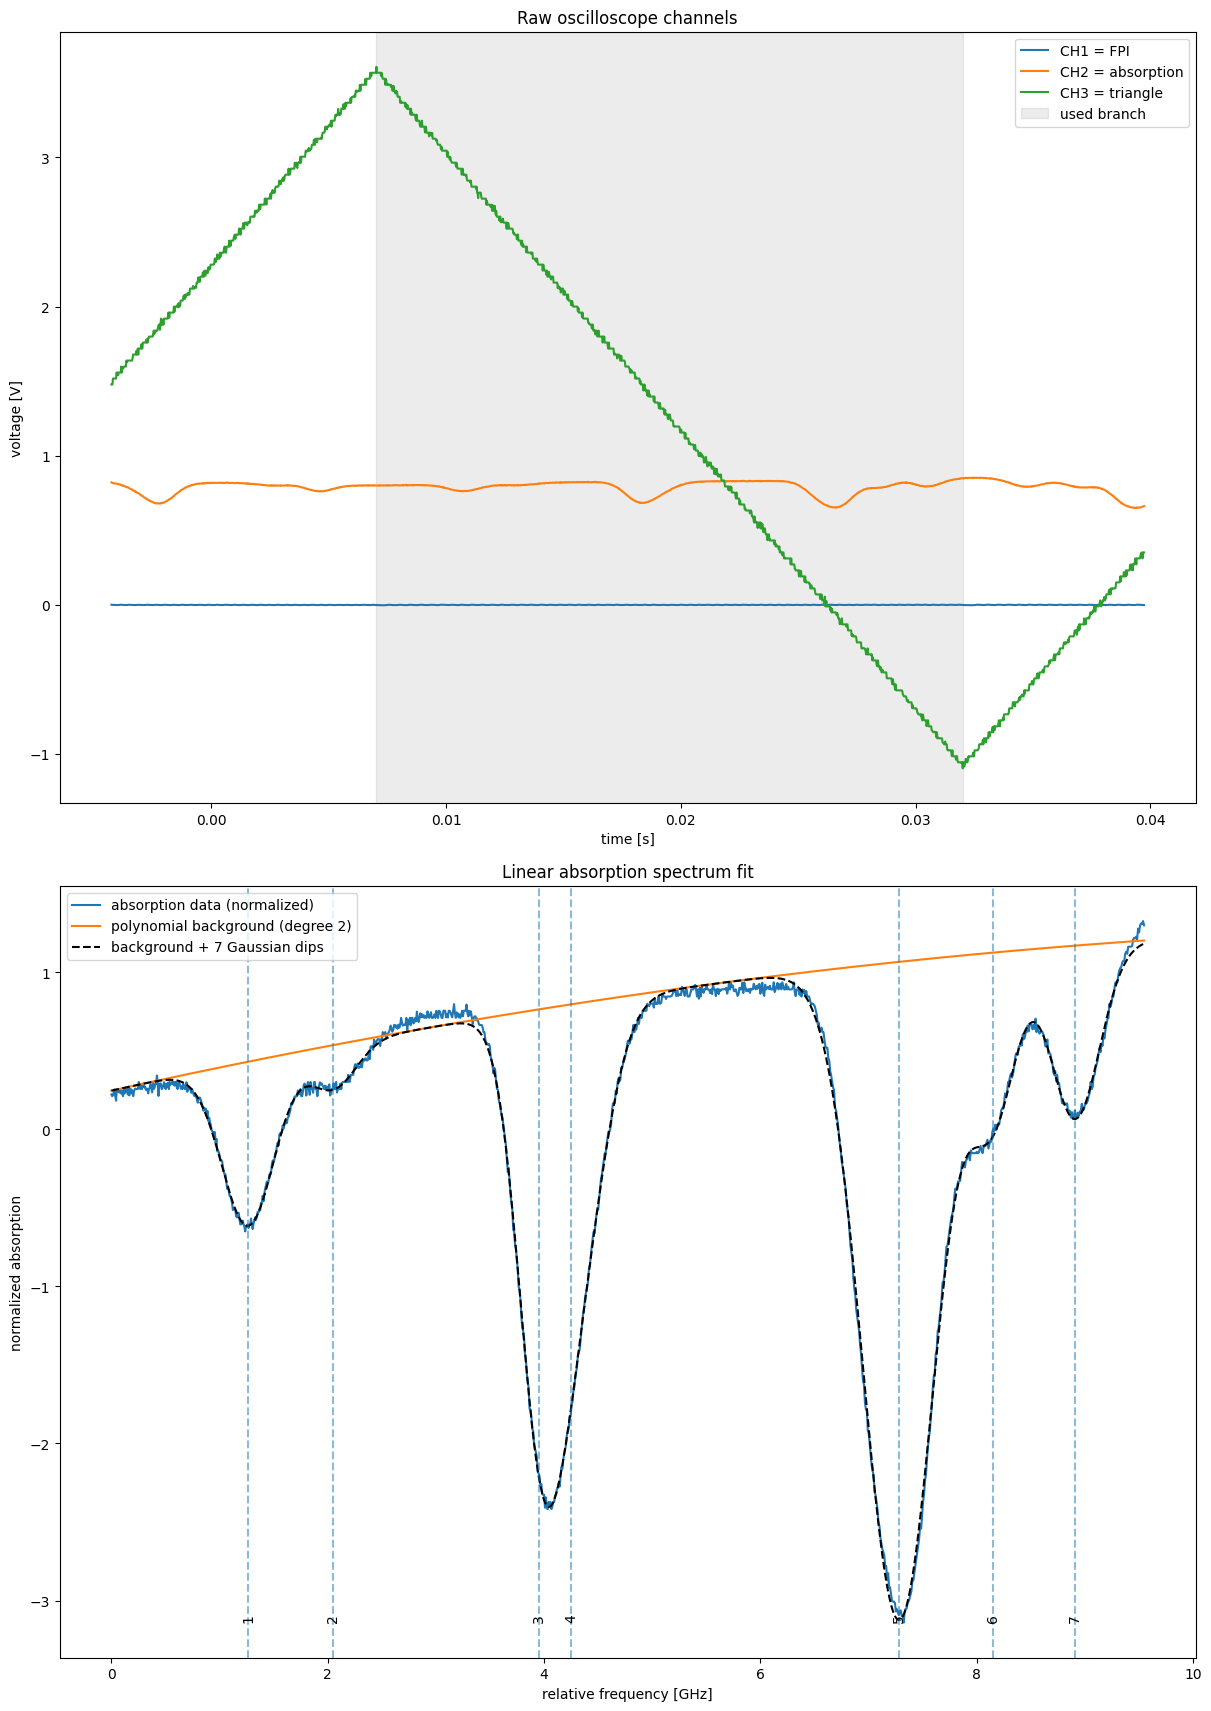

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_PATH = "scope_20.csv"

# channel assignment for your file
FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

# confocal Fabry-Perot mode spacing from the manual
FPI_MODE_SPACING_GHZ = 149.9348e-3  # GHz

# choose one monotonic half-scan
USE_DESCENDING_BRANCH = True

# baseline degree for the main fit
MAIN_POLY_DEGREE = 2

# baseline degrees used for model uncertainty
MODEL_POLY_DEGREES = [1, 2, 3]

# number of gaussian dips
N_DIPS = 7

# FPI peak detection
FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4

# polynomial degree for time->frequency calibration
CALIB_POLY_DEGREE = 3

# manual initial guesses for the 7 Gaussian components
# tuned to your fitted spectrum
MANUAL_MU_GUESS = np.array([
    1.25,  # 87Rb 2->1
    2.05,  # 87Rb 2->2
    3.95,  # low 85Rb group component
    4.25,  # low 85Rb group component
    7.30,  # high 85Rb group
    8.16,  # 87Rb 1->1
    8.92,  # 87Rb 1->2
], dtype=float)

MANUAL_A_GUESS = np.array([
    -1.0,
    -0.25,
    -1.8,
    -1.8,
    -4.0,
    -1.0,
    -1.0,
], dtype=float)

MANUAL_SIGMA_GUESS = np.array([
    0.24,
    0.22,
    0.22,
    0.28,
    0.34,
    0.22,
    0.22,
], dtype=float)

# bootstrap settings
N_BOOT = 250
BOOTSTRAP_SEED = 42

# plot limits
X_LIMITS = None   # e.g. (0, 10)

# ============================================================
# HELPERS
# ============================================================

def odd(n):
    n = int(n)
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path):
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    return df

def choose_monotonic_branch(t, tri, use_descending=True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t, fpi, degree=3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    calib_coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(calib_coeffs, t)
    nu_rel -= nu_rel.min()

    # residuals of calibration at the peak positions
    nu_fit_peaks = np.polyval(calib_coeffs, t_peaks)
    calib_residuals = nu_fit_peaks - nu_peaks
    calib_rms = np.sqrt(np.mean(calib_residuals**2))

    return {
        "nu_rel": nu_rel,
        "fpi_smooth": fpi_s,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "calib_coeffs": calib_coeffs,
        "calib_rms": calib_rms,
    }

def poly_background(x, coeffs):
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def build_model_function(poly_degree, n_dips=7):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x, y, poly_degree):
    pfit = np.polyfit(x, y, poly_degree)
    coeffs_guess = pfit[::-1]

    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]

    return np.array(p0, dtype=float)

def build_bounds(x, poly_degree):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for mu0 in MANUAL_MU_GUESS:
        lower += [-8.0, max(x0, mu0 - 1.0), 0.02]
        upper += [ 0.0, min(x1, mu0 + 1.0), 1.50]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt, pcov, poly_degree, n_dips=7):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt, pcov, poly_degree, n_dips=7):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def weighted_average(vals, errs):
    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)
    w = 1.0 / errs**2
    mean = np.sum(w * vals) / np.sum(w)
    err = np.sqrt(1.0 / np.sum(w))
    return mean, err

def fit_spectrum(x, y, poly_degree):
    model = build_model_function(poly_degree, N_DIPS)
    p0 = build_initial_guess(x, y, poly_degree)
    lb, ub = build_bounds(x, poly_degree)

    popt, pcov = curve_fit(
        model,
        x, y,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, poly_degree, N_DIPS)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, poly_degree, N_DIPS)

    fit_total = model(x, *popt)
    fit_bg = poly_background(x, poly_coeffs)

    return {
        "poly_degree": poly_degree,
        "model": model,
        "popt": popt,
        "pcov": pcov,
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "lb": lb,
        "ub": ub,
    }

def extract_hyperfine_from_fit(gauss_params, gauss_errs, calib_rms=0.0):
    """
    Physically corrected extraction:
      peak 1 = 87Rb 2->1
      peak 2 = 87Rb 2->2
      peaks 3+4 = low-frequency 85Rb group
      peak 5 = high-frequency 85Rb group
      peak 6 = 87Rb 1->1
      peak 7 = 87Rb 1->2
    """
    A = {i+1: gauss_params[i, 0] for i in range(N_DIPS)}
    mu = {i+1: gauss_params[i, 1] for i in range(N_DIPS)}
    dmu = {i+1: gauss_errs[i, 1] for i in range(N_DIPS)}

    # ---- 85Rb low group = combined peaks 3 and 4 ----
    w3 = abs(A[3])
    w4 = abs(A[4])
    mu85_low = (w3 * mu[3] + w4 * mu[4]) / (w3 + w4)

    # formal weighted uncertainty
    dmu85_low_formal = np.sqrt(
        (w3/(w3+w4) * dmu[3])**2 +
        (w4/(w3+w4) * dmu[4])**2
    )

    mu85_high = mu[5]
    dmu85_high = dmu[5]

    Delta85 = mu85_high - mu85_low
    dDelta85_formal = np.sqrt(dmu85_low_formal**2 + dmu85_high**2 + 2*calib_rms**2)

    A85_over_h = Delta85 / 3.0
    dA85_formal = dDelta85_formal / 3.0

    # ---- 87Rb ----
    Delta87_Fp1 = mu[6] - mu[1]
    dDelta87_Fp1_formal = np.sqrt(dmu[6]**2 + dmu[1]**2 + 2*calib_rms**2)

    Delta87_Fp2 = mu[7] - mu[2]
    dDelta87_Fp2_formal = np.sqrt(dmu[7]**2 + dmu[2]**2 + 2*calib_rms**2)

    Delta87_avg, dDelta87_avg_formal = weighted_average(
        [Delta87_Fp1, Delta87_Fp2],
        [dDelta87_Fp1_formal, dDelta87_Fp2_formal]
    )

    A87_over_h = Delta87_avg / 2.0
    dA87_formal = dDelta87_avg_formal / 2.0

    return {
        "mu85_low": mu85_low,
        "dmu85_low_formal": dmu85_low_formal,
        "mu85_high": mu85_high,
        "dmu85_high": dmu85_high,
        "Delta85": Delta85,
        "dDelta85_formal": dDelta85_formal,
        "A85_over_h": A85_over_h,
        "dA85_formal": dA85_formal,

        "Delta87_Fp1": Delta87_Fp1,
        "dDelta87_Fp1_formal": dDelta87_Fp1_formal,
        "Delta87_Fp2": Delta87_Fp2,
        "dDelta87_Fp2_formal": dDelta87_Fp2_formal,
        "Delta87_avg": Delta87_avg,
        "dDelta87_avg_formal": dDelta87_avg_formal,
        "A87_over_h": A87_over_h,
        "dA87_formal": dA87_formal,
    }

def bootstrap_hyperfine(x, y, fit_result, calib_rms, n_boot=200, seed=42):
    rng = np.random.default_rng(seed)
    model = fit_result["model"]
    popt = fit_result["popt"]
    lb = fit_result["lb"]
    ub = fit_result["ub"]
    poly_degree = fit_result["poly_degree"]
    fit_total = fit_result["fit_total"]

    residuals = y - fit_total

    boot_A85 = []
    boot_A87 = []
    boot_D85 = []
    boot_D87 = []

    for _ in range(n_boot):
        y_boot = fit_total + rng.choice(residuals, size=len(residuals), replace=True)

        try:
            popt_b, pcov_b = curve_fit(
                model,
                x, y_boot,
                p0=popt,
                bounds=(lb, ub),
                maxfev=200000
            )
            popt_b, pcov_b = sort_fit_by_mu(popt_b, pcov_b, poly_degree, N_DIPS)
            poly_b, gp_b, ge_b = unpack_fit(popt_b, pcov_b, poly_degree, N_DIPS)

            ex = extract_hyperfine_from_fit(gp_b, ge_b, calib_rms=calib_rms)

            boot_A85.append(ex["A85_over_h"])
            boot_A87.append(ex["A87_over_h"])
            boot_D85.append(ex["Delta85"])
            boot_D87.append(ex["Delta87_avg"])

        except Exception:
            continue

    boot_A85 = np.array(boot_A85)
    boot_A87 = np.array(boot_A87)
    boot_D85 = np.array(boot_D85)
    boot_D87 = np.array(boot_D87)

    return {
        "boot_A85": boot_A85,
        "boot_A87": boot_A87,
        "boot_D85": boot_D85,
        "boot_D87": boot_D87,
        "A85_boot_err": np.std(boot_A85, ddof=1) if len(boot_A85) > 1 else np.nan,
        "A87_boot_err": np.std(boot_A87, ddof=1) if len(boot_A87) > 1 else np.nan,
        "D85_boot_err": np.std(boot_D85, ddof=1) if len(boot_D85) > 1 else np.nan,
        "D87_boot_err": np.std(boot_D87, ddof=1) if len(boot_D87) > 1 else np.nan,
    }

# ============================================================
# LOAD DATA
# ============================================================

df = load_scope_csv(CSV_PATH)

t_all = df["time_s"].to_numpy()
fpi_all = df[FPI_COL].to_numpy()
abs_all = df[ABS_COL].to_numpy()
tri_all = df[TRI_COL].to_numpy()

# branch selection
branch, tri_smooth = choose_monotonic_branch(t_all, tri_all, use_descending=USE_DESCENDING_BRANCH)

t = t_all[branch]
fpi = fpi_all[branch]
abs_sig = abs_all[branch]
tri = tri_all[branch]

# FPI calibration
cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
nu_rel = cal["nu_rel"]
fpi_smooth = cal["fpi_smooth"]
fpi_peak_idx = cal["peak_idx"]
t_fpi_peaks = cal["t_peaks"]
nu_fpi_peaks = cal["nu_peaks"]
calib_rms = cal["calib_rms"]

print(f"Number of FPI peaks used: {len(fpi_peak_idx)}")
print(f"Calibration RMS uncertainty: {calib_rms:.6f} GHz")

# normalize absorption for numerical stability
abs_offset = abs_sig.mean()
abs_scale = abs_sig.std()
y = (abs_sig - abs_offset) / abs_scale

# ============================================================
# MAIN FIT
# ============================================================

main_fit = fit_spectrum(nu_rel, y, MAIN_POLY_DEGREE)
gauss_params = main_fit["gauss_params"]
gauss_errs = main_fit["gauss_errs"]
fit_total = main_fit["fit_total"]
fit_bg = main_fit["fit_bg"]

print("\nFitted Gaussian dips (sorted by center):")
print(" idx      A(norm) ± dA          mu [GHz] ± dmu         sigma [GHz] ± dsigma")
for i, ((A, mu, sig), (dA, dmu, dsig)) in enumerate(zip(gauss_params, gauss_errs), start=1):
    print(f"{i:>3d}   {A: .6f} ± {dA:.6f}    {mu: .6f} ± {dmu:.6f}    {sig: .6f} ± {dsig:.6f}")

# main extraction
main_ex = extract_hyperfine_from_fit(gauss_params, gauss_errs, calib_rms=calib_rms)

# ============================================================
# MODEL-SPREAD UNCERTAINTY
# ============================================================

A85_models = []
A87_models = []
D85_models = []
D87_models = []
model_results = {}

for deg in MODEL_POLY_DEGREES:
    fr = fit_spectrum(nu_rel, y, deg)
    ex = extract_hyperfine_from_fit(fr["gauss_params"], fr["gauss_errs"], calib_rms=calib_rms)

    A85_models.append(ex["A85_over_h"])
    A87_models.append(ex["A87_over_h"])
    D85_models.append(ex["Delta85"])
    D87_models.append(ex["Delta87_avg"])
    model_results[deg] = {"fit": fr, "extract": ex}

A85_model_err = np.std(A85_models, ddof=1) if len(A85_models) > 1 else 0.0
A87_model_err = np.std(A87_models, ddof=1) if len(A87_models) > 1 else 0.0
D85_model_err = np.std(D85_models, ddof=1) if len(D85_models) > 1 else 0.0
D87_model_err = np.std(D87_models, ddof=1) if len(D87_models) > 1 else 0.0

# ============================================================
# BOOTSTRAP UNCERTAINTY
# ============================================================

boot = bootstrap_hyperfine(
    nu_rel, y, main_fit,
    calib_rms=calib_rms,
    n_boot=N_BOOT,
    seed=BOOTSTRAP_SEED
)

# ============================================================
# COMBINE UNCERTAINTIES
# ============================================================

A85_total_err = np.sqrt(
    main_ex["dA85_formal"]**2 +
    A85_model_err**2 +
    boot["A85_boot_err"]**2
)

A87_total_err = np.sqrt(
    main_ex["dA87_formal"]**2 +
    A87_model_err**2 +
    boot["A87_boot_err"]**2
)

D85_total_err = np.sqrt(
    main_ex["dDelta85_formal"]**2 +
    D85_model_err**2 +
    boot["D85_boot_err"]**2
)

D87_total_err = np.sqrt(
    main_ex["dDelta87_avg_formal"]**2 +
    D87_model_err**2 +
    boot["D87_boot_err"]**2
)

# convert to eV
h_eVs = 4.135667696e-15
GHz_to_Hz = 1e9

A85_eV = main_ex["A85_over_h"] * GHz_to_Hz * h_eVs
dA85_eV = A85_total_err * GHz_to_Hz * h_eVs

A87_eV = main_ex["A87_over_h"] * GHz_to_Hz * h_eVs
dA87_eV = A87_total_err * GHz_to_Hz * h_eVs

# ============================================================
# PRINT RESULTS
# ============================================================

print("\nAssigned physical interpretation:")
print("  peak 1 = 87Rb 2->1")
print("  peak 2 = 87Rb 2->2")
print("  peaks 3+4 = low-frequency 85Rb group")
print("  peak 5 = high-frequency 85Rb group")
print("  peak 6 = 87Rb 1->1")
print("  peak 7 = 87Rb 1->2")

print("\nModel-spread values:")
for deg in MODEL_POLY_DEGREES:
    ex = model_results[deg]["extract"]
    print(f"  poly degree {deg}:  A85/h = {ex['A85_over_h']:.6f} GHz,  A87/h = {ex['A87_over_h']:.6f} GHz")

print("\nBootstrap samples kept:")
print(f"  A85: {len(boot['boot_A85'])}")
print(f"  A87: {len(boot['boot_A87'])}")

print("\n================ FINAL RESULTS ================\n")

print("85Rb:")
print(f"  mu_low_group       = {main_ex['mu85_low']:.6f} GHz")
print(f"  mu_high_group      = {main_ex['mu85_high']:.6f} GHz")
print(f"  Delta_nu_85,ground = {main_ex['Delta85']:.6f} ± {D85_total_err:.6f} GHz")
print(f"  A85/h              = {main_ex['A85_over_h']:.6f} ± {A85_total_err:.6f} GHz")
print(f"  A85                = ({A85_eV:.6e} ± {dA85_eV:.2e}) eV")

print("\n87Rb:")
print(f"  Delta_nu_87(F'=1)  = {main_ex['Delta87_Fp1']:.6f} ± {main_ex['dDelta87_Fp1_formal']:.6f} GHz")
print(f"  Delta_nu_87(F'=2)  = {main_ex['Delta87_Fp2']:.6f} ± {main_ex['dDelta87_Fp2_formal']:.6f} GHz")
print(f"  Delta_nu_87,ground = {main_ex['Delta87_avg']:.6f} ± {D87_total_err:.6f} GHz")
print(f"  A87/h              = {main_ex['A87_over_h']:.6f} ± {A87_total_err:.6f} GHz")
print(f"  A87                = ({A87_eV:.6e} ± {dA87_eV:.2e}) eV")

# ============================================================
# PLOTS
# ============================================================

fig, axs = plt.subplots(2, 1, figsize=(12, 17), constrained_layout=True)

# raw channels
axs[0].plot(t_all, df["ch1"], label="CH1 = FPI")
axs[0].plot(t_all, df["ch2"], label="CH2 = absorption")
axs[0].plot(t_all, df["ch3"], label="CH3 = triangle")
axs[0].axvspan(t[0], t[-1], color="gray", alpha=0.15, label="used branch")
axs[0].set_xlabel("time [s]")
axs[0].set_ylabel("voltage [V]")
axs[0].set_title("Raw oscilloscope channels")
axs[0].legend()


# absorption fit
axs[1].plot(nu_rel, y, label="absorption data (normalized)")
axs[1].plot(nu_rel, fit_bg, label=f"polynomial background (degree {MAIN_POLY_DEGREE})")
axs[1].plot(nu_rel, fit_total, label="background + 7 Gaussian dips", linestyle = "--", color = "black")

for i, (A, mu, sig) in enumerate(gauss_params, start=1):
    axs[1].axvline(mu, ls="--", alpha=0.5)
    axs[1].text(mu, np.min(y), str(i), rotation=90, va="bottom", ha="center")

axs[1].set_xlabel("relative frequency [GHz]")
axs[1].set_ylabel("normalized absorption")
axs[1].set_title("Linear absorption spectrum fit")
if X_LIMITS is not None:
    axs[1].set_xlim(*X_LIMITS)
axs[1].legend()

plt.savefig("absorption_fit.png", dpi=300)
plt.show()

Number of FPI peaks used               : 63
Mean FPI peak spacing in time          : 0.3914 ms
Std dev of FPI peak spacing in time    : 0.0279 ms
Relative dt variation (min, max)       : -10.06%, 18.04%
Calibrated frequency span              : 0.0000 to 9.2960 GHz

Fitted Gaussian dips (sorted by center):
 idx      A(norm) ± dA          mu [GHz] ± dmu         sigma [GHz] ± dsigma      FWHM [GHz]      area
  1   -0.775192 ± 0.139486     0.152834 ± 0.021573     0.300000 ± 0.043315     0.706446    -0.582936
  2   -1.443634 ± 0.073327     1.053624 ± 0.008617     0.292294 ± 0.013781     0.688299    -1.057709
  3   -0.483516 ± 0.041018     1.892061 ± 0.026717     0.291587 ± 0.027834     0.686634    -0.353401
  4   -2.014500 ± 1.004125     3.767897 ± 0.039334     0.212093 ± 0.015847     0.499440    -1.070985
  5   -1.772285 ± 0.669969     4.071916 ± 0.119896     0.263173 ± 0.040422     0.619725    -1.169136
  6   -3.990355 ± 0.036034     7.087576 ± 0.002666     0.337019 ± 0.002650     0.79361

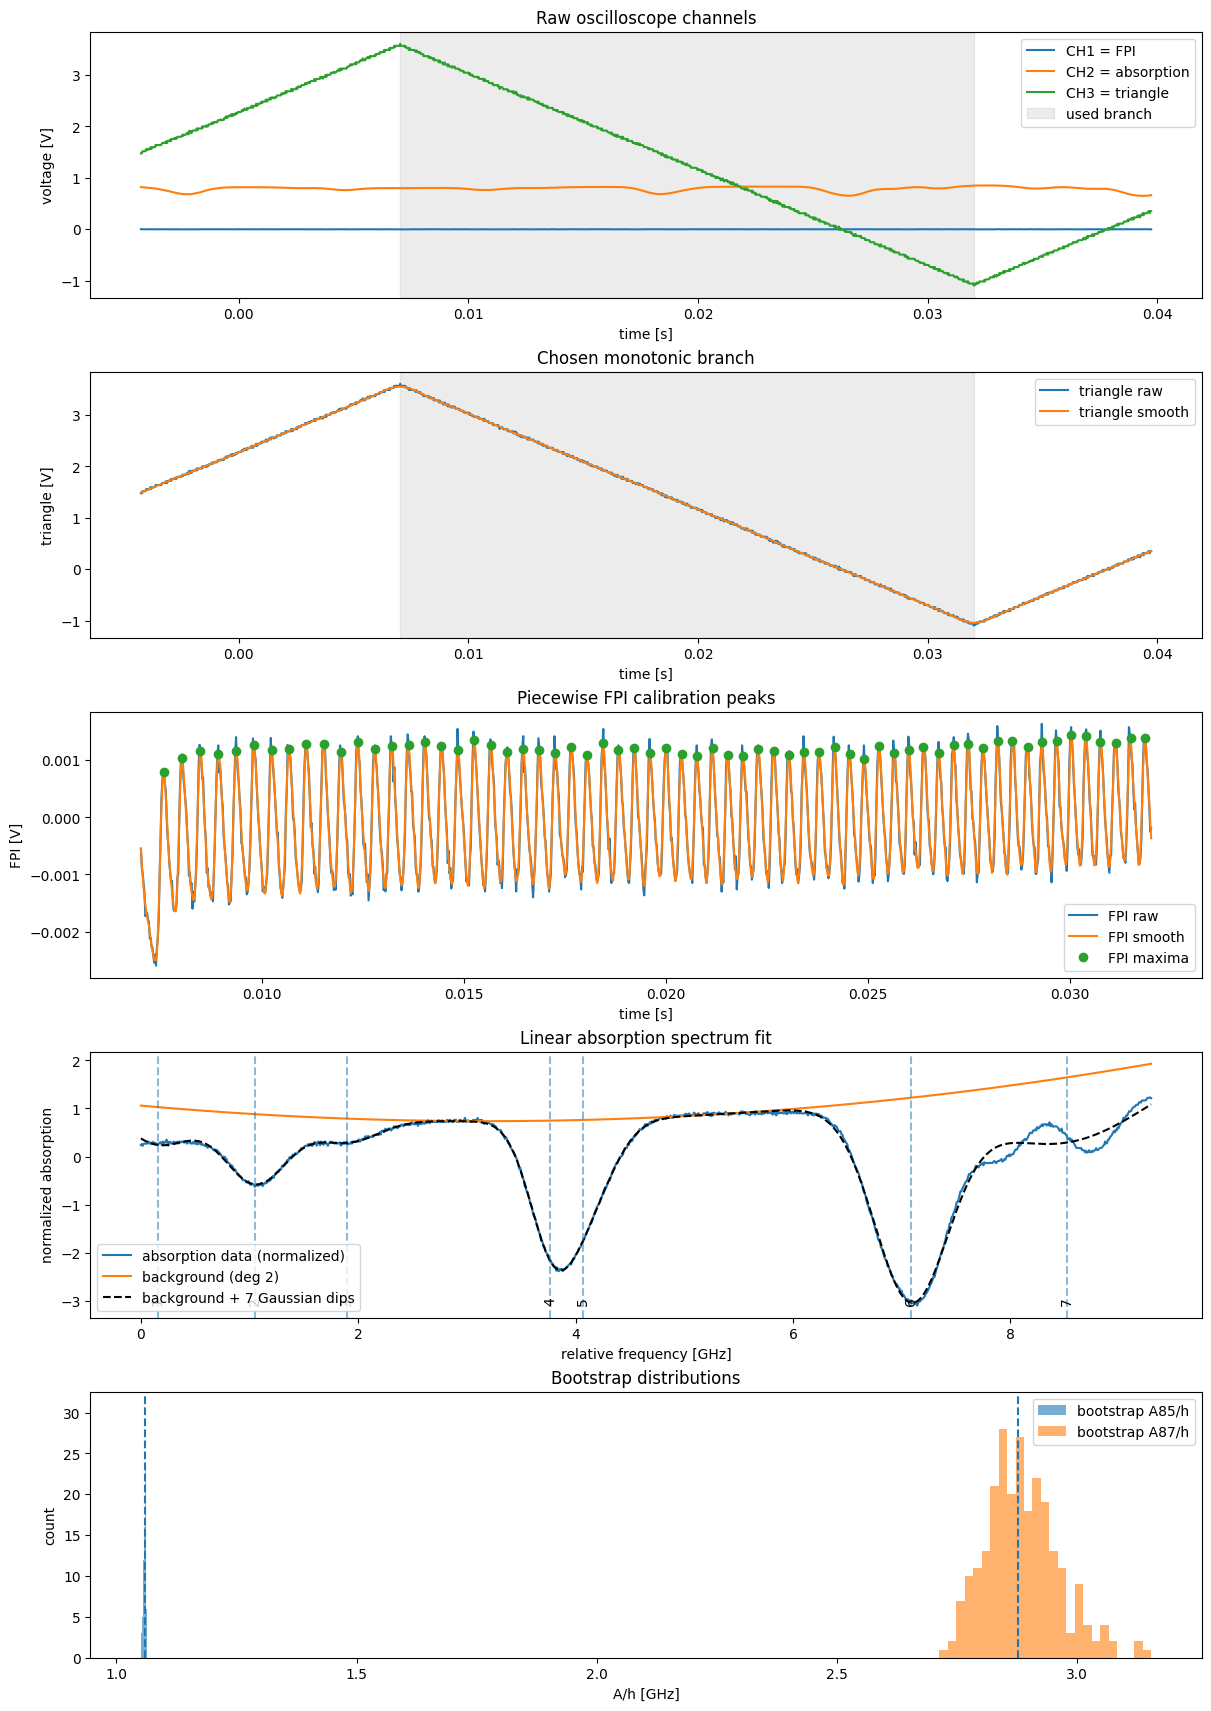

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_PATH = "scope_20.csv"

# channel assignment
FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

# confocal Fabry-Perot mode spacing from manual
FPI_MODE_SPACING_GHZ = 149.9348e-3  # GHz

# choose one monotonic half-scan
USE_DESCENDING_BRANCH = True

# main baseline degree
# use 2 here because it fits your right edge better, while still keeping
# the better piecewise FPI calibration
MAIN_POLY_DEGREE = 2
MODEL_POLY_DEGREES = [1, 2, 3]

# number of Gaussian dips
N_DIPS = 7

# FPI peak detection
FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4

# ------------------------------------------------------------
# Manual dip guesses in GHz AFTER piecewise FPI calibration
# ------------------------------------------------------------
MANUAL_MU_GUESS = np.array([
    0.20,   # weak left edge / nuisance-like dip
    1.10,   # left resolved dip
    1.85,   # second left resolved dip
    3.80,   # 85Rb lower merged component
    4.10,   # 85Rb lower merged component
    7.08,   # strong main dip
    8.25,   # right edge dip
], dtype=float)

MANUAL_A_GUESS = np.array([
    -0.20,
    -1.10,
    -0.35,
    -1.80,
    -1.80,
    -3.80,
    -0.90,
], dtype=float)

MANUAL_SIGMA_GUESS = np.array([
    0.18,
    0.22,
    0.20,
    0.22,
    0.24,
    0.30,
    0.25,
], dtype=float)

# position windows for bounds around manual centers
MANUAL_MU_WINDOW = np.array([
    0.35,
    0.30,
    0.35,
    0.35,
    0.35,
    0.35,
    0.50,
], dtype=float)

# sigma upper bounds:
# keep the physical middle peaks tight, let the right edge nuisance peak be broader
SIGMA_UPPER = np.array([
    0.30,
    0.30,
    0.30,
    0.35,
    0.35,
    0.40,
    0.80,
], dtype=float)

# bootstrap
N_BOOT = 250
BOOTSTRAP_SEED = 42

# plotting
X_LIMITS = None
SHOW_PLOTS = True

# ============================================================
# HELPERS
# ============================================================

def odd(n):
    n = int(n)
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path):
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t, tri, use_descending=True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        descending = slice(i_max, i_min + 1)
        ascending = slice(0, i_max + 1)
    else:
        descending = slice(i_min, i_max + 1)
        ascending = slice(0, i_min + 1)

    branch = descending if use_descending else ascending
    return branch, tri_s

def detect_fpi_peaks(t, fpi):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, props = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    return fpi_s, peak_idx, props

def calibrate_fpi_piecewise(t, fpi):
    """
    Theodor-style local calibration:
    each interval between neighboring FPI peaks corresponds to one exact mode spacing.
    """
    fpi_s, peak_idx, _ = detect_fpi_peaks(t, fpi)
    t_peaks = t[peak_idx]

    nu_rel = np.full_like(t, np.nan, dtype=float)

    for i in range(len(t_peaks) - 1):
        t0 = t_peaks[i]
        t1 = t_peaks[i + 1]
        mask = (t >= t0) & (t <= t1)

        frac = (t[mask] - t0) / (t1 - t0)
        nu_rel[mask] = (i + frac) * FPI_MODE_SPACING_GHZ

    nu_rel -= np.nanmin(nu_rel)

    dt_mode = np.diff(t_peaks)
    dt_mean = np.mean(dt_mode)
    dt_std = np.std(dt_mode, ddof=1) if len(dt_mode) > 1 else 0.0
    rel_dev = (dt_mode - dt_mean) / dt_mean

    return {
        "nu_rel": nu_rel,
        "valid_mask": np.isfinite(nu_rel),
        "fpi_smooth": fpi_s,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "dt_mode": dt_mode,
        "dt_mean": dt_mean,
        "dt_std": dt_std,
        "rel_dev": rel_dev,
    }

def poly_background(x, coeffs):
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def gaussian_area(A, sigma):
    return np.sqrt(2*np.pi) * A * sigma

def gaussian_fwhm(sigma):
    return 2*np.sqrt(2*np.log(2)) * sigma

def build_model_function(poly_degree, n_dips=7):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x, y, poly_degree):
    pfit = np.polyfit(x, y, poly_degree)
    coeffs_guess = pfit[::-1]

    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]

    return np.array(p0, dtype=float)

def build_bounds(x, poly_degree):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for i, (mu0, win) in enumerate(zip(MANUAL_MU_GUESS, MANUAL_MU_WINDOW)):
        lower += [-10.0, max(x0, mu0 - win), 0.03]
        upper += [  0.0, min(x1, mu0 + win), SIGMA_UPPER[i]]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt, pcov, poly_degree, n_dips=7):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt, pcov, poly_degree, n_dips=7):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def weighted_average(vals, errs):
    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)
    w = 1.0 / errs**2
    mean = np.sum(w * vals) / np.sum(w)
    err = np.sqrt(1.0 / np.sum(w))
    return mean, err

def fit_spectrum(x, y, poly_degree):
    model = build_model_function(poly_degree, N_DIPS)
    p0 = build_initial_guess(x, y, poly_degree)
    lb, ub = build_bounds(x, poly_degree)

    popt, pcov = curve_fit(
        model,
        x, y,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, poly_degree, N_DIPS)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, poly_degree, N_DIPS)

    fit_total = model(x, *popt)
    fit_bg = poly_background(x, poly_coeffs)

    return {
        "poly_degree": poly_degree,
        "model": model,
        "popt": popt,
        "pcov": pcov,
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "lb": lb,
        "ub": ub,
    }

def extract_hyperfine_from_fit(gauss_params, gauss_errs):
    """
    Final practical extraction for your current spectrum.

    Reliable:
      - 85Rb from peaks 4,5,6

    Provisional:
      - 87Rb still depends on right-edge peak 7 stability
    """
    A = {i+1: gauss_params[i, 0] for i in range(N_DIPS)}
    mu = {i+1: gauss_params[i, 1] for i in range(N_DIPS)}
    dmu = {i+1: gauss_errs[i, 1] for i in range(N_DIPS)}

    # ---------- 85Rb ----------
    # lower merged group = peaks 4 and 5
    w4 = abs(A[4])
    w5 = abs(A[5])

    mu85_low = (w4 * mu[4] + w5 * mu[5]) / (w4 + w5)
    dmu85_low = np.sqrt(
        (w4/(w4+w5) * dmu[4])**2 +
        (w5/(w4+w5) * dmu[5])**2
    )

    # upper merged group = peak 6
    mu85_high = mu[6]
    dmu85_high = dmu[6]

    Delta85 = mu85_high - mu85_low
    dDelta85 = np.sqrt(dmu85_low**2 + dmu85_high**2)

    A85_over_h = Delta85 / 3.0
    dA85_over_h = dDelta85 / 3.0

    # ---------- 87Rb ----------
    # provisional branch estimates
    # avoid peak 1 because it is unstable
    Delta87_Fp1 = mu[7] - mu[2]
    dDelta87_Fp1 = np.sqrt(dmu[7]**2 + dmu[2]**2)

    Delta87_Fp2 = mu[6] - mu[3]
    dDelta87_Fp2 = np.sqrt(dmu[6]**2 + dmu[3]**2)

    Delta87_avg, dDelta87_avg = weighted_average(
        [Delta87_Fp1, Delta87_Fp2],
        [dDelta87_Fp1, dDelta87_Fp2]
    )

    A87_over_h = Delta87_avg / 2.0
    dA87_over_h = dDelta87_avg / 2.0

    return {
        "mu85_low": mu85_low,
        "dmu85_low": dmu85_low,
        "mu85_high": mu85_high,
        "dmu85_high": dmu85_high,
        "Delta85": Delta85,
        "dDelta85": dDelta85,
        "A85_over_h": A85_over_h,
        "dA85_over_h": dA85_over_h,

        "Delta87_Fp1": Delta87_Fp1,
        "dDelta87_Fp1": dDelta87_Fp1,
        "Delta87_Fp2": Delta87_Fp2,
        "dDelta87_Fp2": dDelta87_Fp2,
        "Delta87_avg": Delta87_avg,
        "dDelta87_avg": dDelta87_avg,
        "A87_over_h": A87_over_h,
        "dA87_over_h": dA87_over_h,
    }

def bootstrap_hyperfine(x, y, fit_result, n_boot=200, seed=42):
    rng = np.random.default_rng(seed)
    model = fit_result["model"]
    popt = fit_result["popt"]
    lb = fit_result["lb"]
    ub = fit_result["ub"]
    poly_degree = fit_result["poly_degree"]
    fit_total = fit_result["fit_total"]

    residuals = y - fit_total

    boot_A85 = []
    boot_A87 = []
    boot_D85 = []
    boot_D87 = []

    for _ in range(n_boot):
        y_boot = fit_total + rng.choice(residuals, size=len(residuals), replace=True)

        try:
            popt_b, pcov_b = curve_fit(
                model,
                x, y_boot,
                p0=popt,
                bounds=(lb, ub),
                maxfev=250000
            )
            popt_b, pcov_b = sort_fit_by_mu(popt_b, pcov_b, poly_degree, N_DIPS)
            _, gp_b, ge_b = unpack_fit(popt_b, pcov_b, poly_degree, N_DIPS)

            ex = extract_hyperfine_from_fit(gp_b, ge_b)
            boot_A85.append(ex["A85_over_h"])
            boot_A87.append(ex["A87_over_h"])
            boot_D85.append(ex["Delta85"])
            boot_D87.append(ex["Delta87_avg"])

        except Exception:
            continue

    boot_A85 = np.array(boot_A85)
    boot_A87 = np.array(boot_A87)
    boot_D85 = np.array(boot_D85)
    boot_D87 = np.array(boot_D87)

    return {
        "boot_A85": boot_A85,
        "boot_A87": boot_A87,
        "boot_D85": boot_D85,
        "boot_D87": boot_D87,
        "A85_boot_err": np.std(boot_A85, ddof=1) if len(boot_A85) > 1 else np.nan,
        "A87_boot_err": np.std(boot_A87, ddof=1) if len(boot_A87) > 1 else np.nan,
        "D85_boot_err": np.std(boot_D85, ddof=1) if len(boot_D85) > 1 else np.nan,
        "D87_boot_err": np.std(boot_D87, ddof=1) if len(boot_D87) > 1 else np.nan,
    }

# ============================================================
# LOAD DATA
# ============================================================

df = load_scope_csv(CSV_PATH)

t_all = df["time_s"].to_numpy()
fpi_all = df[FPI_COL].to_numpy()
abs_all = df[ABS_COL].to_numpy()
tri_all = df[TRI_COL].to_numpy()

branch, tri_smooth = choose_monotonic_branch(
    t_all, tri_all, use_descending=USE_DESCENDING_BRANCH
)

t = t_all[branch]
fpi = fpi_all[branch]
abs_sig = abs_all[branch]
tri = tri_all[branch]

# ============================================================
# FPI CALIBRATION
# ============================================================

cal = calibrate_fpi_piecewise(t, fpi)

valid = cal["valid_mask"]
t_used = t[valid]
fpi_used = fpi[valid]
abs_used = abs_sig[valid]
nu_rel = cal["nu_rel"][valid]

print(f"Number of FPI peaks used               : {len(cal['t_peaks'])}")
print(f"Mean FPI peak spacing in time          : {cal['dt_mean']*1e3:.4f} ms")
print(f"Std dev of FPI peak spacing in time    : {cal['dt_std']*1e3:.4f} ms")
print(f"Relative dt variation (min, max)       : {100*np.min(cal['rel_dev']):.2f}%, {100*np.max(cal['rel_dev']):.2f}%")
print(f"Calibrated frequency span              : {nu_rel.min():.4f} to {nu_rel.max():.4f} GHz")

# normalize absorption
abs_offset = abs_used.mean()
abs_scale = abs_used.std()
y = (abs_used - abs_offset) / abs_scale

# ============================================================
# MAIN FIT
# ============================================================

main_fit = fit_spectrum(nu_rel, y, MAIN_POLY_DEGREE)
gauss_params = main_fit["gauss_params"]
gauss_errs = main_fit["gauss_errs"]
fit_total = main_fit["fit_total"]
fit_bg = main_fit["fit_bg"]

print("\nFitted Gaussian dips (sorted by center):")
print(" idx      A(norm) ± dA          mu [GHz] ± dmu         sigma [GHz] ± dsigma      FWHM [GHz]      area")
for i, ((A, mu, sig), (dA, dmu, dsig)) in enumerate(zip(gauss_params, gauss_errs), start=1):
    print(
        f"{i:>3d}   {A: .6f} ± {dA:.6f}    "
        f"{mu: .6f} ± {dmu:.6f}    "
        f"{sig: .6f} ± {dsig:.6f}    "
        f"{gaussian_fwhm(sig): .6f}    "
        f"{gaussian_area(A, sig): .6f}"
    )

main_ex = extract_hyperfine_from_fit(gauss_params, gauss_errs)

# ============================================================
# MODEL SPREAD
# ============================================================

A85_models = []
A87_models = []
D85_models = []
D87_models = []

for deg in MODEL_POLY_DEGREES:
    fr = fit_spectrum(nu_rel, y, deg)
    ex = extract_hyperfine_from_fit(fr["gauss_params"], fr["gauss_errs"])
    A85_models.append(ex["A85_over_h"])
    A87_models.append(ex["A87_over_h"])
    D85_models.append(ex["Delta85"])
    D87_models.append(ex["Delta87_avg"])

A85_model_err = np.std(A85_models, ddof=1) if len(A85_models) > 1 else 0.0
A87_model_err = np.std(A87_models, ddof=1) if len(A87_models) > 1 else 0.0
D85_model_err = np.std(D85_models, ddof=1) if len(D85_models) > 1 else 0.0
D87_model_err = np.std(D87_models, ddof=1) if len(D87_models) > 1 else 0.0

# ============================================================
# BOOTSTRAP
# ============================================================

boot = bootstrap_hyperfine(
    nu_rel, y, main_fit,
    n_boot=N_BOOT,
    seed=BOOTSTRAP_SEED
)

# ============================================================
# FINAL ERRORS
# ============================================================

A85_total_err = np.sqrt(
    main_ex["dA85_over_h"]**2 +
    A85_model_err**2 +
    boot["A85_boot_err"]**2
)

A87_total_err = np.sqrt(
    main_ex["dA87_over_h"]**2 +
    A87_model_err**2 +
    boot["A87_boot_err"]**2
)

D85_total_err = np.sqrt(
    main_ex["dDelta85"]**2 +
    D85_model_err**2 +
    boot["D85_boot_err"]**2
)

D87_total_err = np.sqrt(
    main_ex["dDelta87_avg"]**2 +
    D87_model_err**2 +
    boot["D87_boot_err"]**2
)

# ============================================================
# OPTIONAL ENERGY CONVERSION
# ============================================================

h_eVs = 4.135667696e-15
GHz_to_Hz = 1e9

A85_eV = main_ex["A85_over_h"] * GHz_to_Hz * h_eVs
dA85_eV = A85_total_err * GHz_to_Hz * h_eVs

A87_eV = main_ex["A87_over_h"] * GHz_to_Hz * h_eVs
dA87_eV = A87_total_err * GHz_to_Hz * h_eVs

# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n================ FINAL RESULTS ================\n")

print("Interpreted fit structure:")
print("  peak 1 = weak left-edge nuisance-like dip")
print("  peak 2 = left resolved dip")
print("  peak 3 = second left resolved dip")
print("  peaks 4+5 = 85Rb lower merged group")
print("  peak 6 = strong main dip (85Rb upper merged group)")
print("  peak 7 = right-edge dip (used cautiously)")

print("\nModel-spread values:")
for deg in MODEL_POLY_DEGREES:
    fr = fit_spectrum(nu_rel, y, deg)
    ex = extract_hyperfine_from_fit(fr["gauss_params"], fr["gauss_errs"])
    print(f"  poly degree {deg}:  A85/h = {ex['A85_over_h']:.6f} GHz,  A87/h = {ex['A87_over_h']:.6f} GHz")

print("\nBootstrap samples kept:")
print(f"  A85: {len(boot['boot_A85'])}")
print(f"  A87: {len(boot['boot_A87'])}")

print("\n85Rb:")
print(f"  mu_low_group       = {main_ex['mu85_low']:.6f} GHz")
print(f"  mu_high_group      = {main_ex['mu85_high']:.6f} GHz")
print(f"  Delta_nu_85,ground = {main_ex['Delta85']:.6f} ± {D85_total_err:.6f} GHz")
print(f"  A85/h              = {main_ex['A85_over_h']:.6f} ± {A85_total_err:.6f} GHz")
print(f"  A85                = ({A85_eV:.6e} ± {dA85_eV:.2e}) eV")

print("\n87Rb (provisional):")
print(f"  Delta_nu_87(F'=1)  = {main_ex['Delta87_Fp1']:.6f} ± {main_ex['dDelta87_Fp1']:.6f} GHz")
print(f"  Delta_nu_87(F'=2)  = {main_ex['Delta87_Fp2']:.6f} ± {main_ex['dDelta87_Fp2']:.6f} GHz")
print(f"  Delta_nu_87,ground = {main_ex['Delta87_avg']:.6f} ± {D87_total_err:.6f} GHz")
print(f"  A87/h              = {main_ex['A87_over_h']:.6f} ± {A87_total_err:.6f} GHz")
print(f"  A87                = ({A87_eV:.6e} ± {dA87_eV:.2e}) eV")

# ============================================================
# PLOTS
# ============================================================

if SHOW_PLOTS:
    fig, axs = plt.subplots(5, 1, figsize=(12, 17), constrained_layout=True)

    # raw channels
    axs[0].plot(t_all, df["ch1"], label="CH1 = FPI")
    axs[0].plot(t_all, df["ch2"], label="CH2 = absorption")
    axs[0].plot(t_all, df["ch3"], label="CH3 = triangle")
    axs[0].axvspan(t[0], t[-1], color="gray", alpha=0.15, label="used branch")
    axs[0].set_xlabel("time [s]")
    axs[0].set_ylabel("voltage [V]")
    axs[0].set_title("Raw oscilloscope channels")
    axs[0].legend()

    # triangle
    axs[1].plot(t_all, tri_all, label="triangle raw")
    axs[1].plot(t_all, tri_smooth, label="triangle smooth")
    axs[1].axvspan(t[0], t[-1], color="gray", alpha=0.15)
    axs[1].set_xlabel("time [s]")
    axs[1].set_ylabel("triangle [V]")
    axs[1].set_title("Chosen monotonic branch")
    axs[1].legend()

    # FPI
    axs[2].plot(t, fpi, label="FPI raw")
    axs[2].plot(t, cal["fpi_smooth"], label="FPI smooth")
    axs[2].plot(cal["t_peaks"], cal["fpi_smooth"][cal["peak_idx"]], "o", label="FPI maxima")
    axs[2].set_xlabel("time [s]")
    axs[2].set_ylabel("FPI [V]")
    axs[2].set_title("Piecewise FPI calibration peaks")
    axs[2].legend()

    # absorption fit
    axs[3].plot(nu_rel, y, label="absorption data (normalized)")
    axs[3].plot(nu_rel, fit_bg, label=f"background (deg {MAIN_POLY_DEGREE})")
    axs[3].plot(nu_rel, fit_total, label="background + 7 Gaussian dips", linestyle="--", color="black")

    for i, (A, mu, sig) in enumerate(gauss_params, start=1):
        axs[3].axvline(mu, ls="--", alpha=0.5)
        axs[3].text(mu, np.min(y), str(i), rotation=90, va="bottom", ha="center")

    axs[3].set_xlabel("relative frequency [GHz]")
    axs[3].set_ylabel("normalized absorption")
    axs[3].set_title("Linear absorption spectrum fit")
    if X_LIMITS is not None:
        axs[3].set_xlim(*X_LIMITS)
    axs[3].legend()

    # bootstrap
    if len(boot["boot_A85"]) > 5 and len(boot["boot_A87"]) > 5:
        axs[4].hist(boot["boot_A85"], bins=25, alpha=0.6, label="bootstrap A85/h")
        axs[4].hist(boot["boot_A87"], bins=25, alpha=0.6, label="bootstrap A87/h")
        axs[4].axvline(main_ex["A85_over_h"], ls="--")
        axs[4].axvline(main_ex["A87_over_h"], ls="--")
        axs[4].set_xlabel("A/h [GHz]")
        axs[4].set_ylabel("count")
        axs[4].set_title("Bootstrap distributions")
        axs[4].legend()
    else:
        axs[4].text(0.5, 0.5, "Too few successful bootstrap fits", ha="center", va="center")
        axs[4].set_axis_off()

    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_PATH = "scope_20.csv"

FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

FPI_MODE_SPACING_GHZ = 149.9348e-3  # GHz
USE_DESCENDING_BRANCH = True

MAIN_POLY_DEGREE = 2
MODEL_POLY_DEGREES = [1, 2, 3]
N_DIPS = 7

FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4

CALIB_POLY_DEGREE = 3

MANUAL_MU_GUESS = np.array([
    1.25,  # 87Rb 2->1
    2.05,  # 87Rb 2->2
    3.95,  # low 85Rb group component
    4.25,  # low 85Rb group component
    7.30,  # high 85Rb group
    8.16,  # 87Rb 1->1
    8.92,  # 87Rb 1->2
], dtype=float)

MANUAL_A_GUESS = np.array([
    -1.0,
    -0.25,
    -1.8,
    -1.8,
    -4.0,
    -1.0,
    -1.0,
], dtype=float)

MANUAL_SIGMA_GUESS = np.array([
    0.24,
    0.22,
    0.22,
    0.28,
    0.34,
    0.22,
    0.22,
], dtype=float)

N_BOOT = 250
BOOTSTRAP_SEED = 42

X_LIMITS = None

# ============================================================
# HELPERS
# ============================================================

def odd(n):
    n = int(n)
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path):
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t, tri, use_descending=True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t, fpi, degree=3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    calib_coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(calib_coeffs, t)
    nu_rel -= nu_rel.min()

    nu_fit_peaks = np.polyval(calib_coeffs, t_peaks)
    calib_residuals = nu_fit_peaks - nu_peaks
    calib_rms = np.sqrt(np.mean(calib_residuals**2))

    return {
        "nu_rel": nu_rel,
        "fpi_smooth": fpi_s,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "calib_coeffs": calib_coeffs,
        "calib_rms": calib_rms,
    }

def poly_background(x, coeffs):
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def build_model_function(poly_degree, n_dips=7):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x, y, poly_degree):
    pfit = np.polyfit(x, y, poly_degree)
    coeffs_guess = pfit[::-1]

    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]

    return np.array(p0, dtype=float)

def build_bounds(x, poly_degree):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for mu0 in MANUAL_MU_GUESS:
        lower += [-8.0, max(x0, mu0 - 1.0), 0.02]
        upper += [ 0.0, min(x1, mu0 + 1.0), 1.50]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt, pcov, poly_degree, n_dips=7):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt, pcov, poly_degree, n_dips=7):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def weighted_average(vals, errs):
    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)
    w = 1.0 / errs**2
    mean = np.sum(w * vals) / np.sum(w)
    err = np.sqrt(1.0 / np.sum(w))
    return mean, err

def fit_spectrum(x, y, poly_degree):
    model = build_model_function(poly_degree, N_DIPS)
    p0 = build_initial_guess(x, y, poly_degree)
    lb, ub = build_bounds(x, poly_degree)

    popt, pcov = curve_fit(
        model,
        x, y,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, poly_degree, N_DIPS)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, poly_degree, N_DIPS)

    fit_total = model(x, *popt)
    fit_bg = poly_background(x, poly_coeffs)

    return {
        "poly_degree": poly_degree,
        "model": model,
        "popt": popt,
        "pcov": pcov,
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "lb": lb,
        "ub": ub,
    }

def extract_hyperfine_from_fit(gauss_params, gauss_errs, calib_rms=0.0):
    # peak 1 = 87Rb 2->1
    # peak 2 = 87Rb 2->2
    # peaks 3+4 = low-frequency 85Rb group
    # peak 5 = high-frequency 85Rb group
    # peak 6 = 87Rb 1->1
    # peak 7 = 87Rb 1->2

    A = {i+1: gauss_params[i, 0] for i in range(N_DIPS)}
    mu = {i+1: gauss_params[i, 1] for i in range(N_DIPS)}
    dmu = {i+1: gauss_errs[i, 1] for i in range(N_DIPS)}

    # 85Rb
    w3 = abs(A[3])
    w4 = abs(A[4])
    mu85_low = (w3 * mu[3] + w4 * mu[4]) / (w3 + w4)
    dmu85_low_formal = np.sqrt(
        (w3/(w3+w4) * dmu[3])**2 +
        (w4/(w3+w4) * dmu[4])**2
    )

    mu85_high = mu[5]
    dmu85_high = dmu[5]

    Delta85 = mu85_high - mu85_low
    dDelta85_formal = np.sqrt(dmu85_low_formal**2 + dmu85_high**2 + 2*calib_rms**2)

    A85_over_h = Delta85 / 3.0
    dA85_formal = dDelta85_formal / 3.0

    # 87Rb
    Delta87_Fp1 = mu[6] - mu[1]
    dDelta87_Fp1_formal = np.sqrt(dmu[6]**2 + dmu[1]**2 + 2*calib_rms**2)

    Delta87_Fp2 = mu[7] - mu[2]
    dDelta87_Fp2_formal = np.sqrt(dmu[7]**2 + dmu[2]**2 + 2*calib_rms**2)

    Delta87_avg, dDelta87_avg_formal = weighted_average(
        [Delta87_Fp1, Delta87_Fp2],
        [dDelta87_Fp1_formal, dDelta87_Fp2_formal]
    )

    A87_over_h = Delta87_avg / 2.0
    dA87_formal = dDelta87_avg_formal / 2.0

    return {
        "A85_over_h": A85_over_h,
        "dA85_formal": dA85_formal,
        "Delta85": Delta85,
        "dDelta85_formal": dDelta85_formal,
        "A87_over_h": A87_over_h,
        "dA87_formal": dA87_formal,
        "Delta87_avg": Delta87_avg,
        "dDelta87_avg_formal": dDelta87_avg_formal,
    }

def bootstrap_hyperfine(x, y, fit_result, calib_rms, n_boot=200, seed=42):
    rng = np.random.default_rng(seed)
    model = fit_result["model"]
    popt = fit_result["popt"]
    lb = fit_result["lb"]
    ub = fit_result["ub"]
    poly_degree = fit_result["poly_degree"]
    fit_total = fit_result["fit_total"]

    residuals = y - fit_total

    boot_A85 = []
    boot_A87 = []
    boot_D85 = []
    boot_D87 = []

    for _ in range(n_boot):
        y_boot = fit_total + rng.choice(residuals, size=len(residuals), replace=True)

        try:
            popt_b, pcov_b = curve_fit(
                model,
                x, y_boot,
                p0=popt,
                bounds=(lb, ub),
                maxfev=200000
            )
            popt_b, pcov_b = sort_fit_by_mu(popt_b, pcov_b, poly_degree, N_DIPS)
            _, gp_b, ge_b = unpack_fit(popt_b, pcov_b, poly_degree, N_DIPS)

            ex = extract_hyperfine_from_fit(gp_b, ge_b, calib_rms=calib_rms)

            boot_A85.append(ex["A85_over_h"])
            boot_A87.append(ex["A87_over_h"])
            boot_D85.append(ex["Delta85"])
            boot_D87.append(ex["Delta87_avg"])

        except Exception:
            continue

    boot_A85 = np.array(boot_A85)
    boot_A87 = np.array(boot_A87)
    boot_D85 = np.array(boot_D85)
    boot_D87 = np.array(boot_D87)

    return {
        "A85_boot_err": np.std(boot_A85, ddof=1) if len(boot_A85) > 1 else np.nan,
        "A87_boot_err": np.std(boot_A87, ddof=1) if len(boot_A87) > 1 else np.nan,
        "D85_boot_err": np.std(boot_D85, ddof=1) if len(boot_D85) > 1 else np.nan,
        "D87_boot_err": np.std(boot_D87, ddof=1) if len(boot_D87) > 1 else np.nan,
    }

# ============================================================
# LOAD DATA
# ============================================================

df = load_scope_csv(CSV_PATH)

t_all = df["time_s"].to_numpy()
fpi_all = df[FPI_COL].to_numpy()
abs_all = df[ABS_COL].to_numpy()
tri_all = df[TRI_COL].to_numpy()

branch, tri_smooth = choose_monotonic_branch(
    t_all, tri_all, use_descending=USE_DESCENDING_BRANCH
)

t = t_all[branch]
fpi = fpi_all[branch]
abs_sig = abs_all[branch]

# ============================================================
# CALIBRATION
# ============================================================

cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
nu_rel = cal["nu_rel"]
calib_rms = cal["calib_rms"]

print(f"Number of FPI peaks used: {len(cal['peak_idx'])}")
print(f"Calibration RMS uncertainty: {calib_rms:.6f} GHz")

# normalize absorption
y = (abs_sig - abs_sig.mean()) / abs_sig.std()

# ============================================================
# MAIN FIT
# ============================================================

main_fit = fit_spectrum(nu_rel, y, MAIN_POLY_DEGREE)
gauss_params = main_fit["gauss_params"]
gauss_errs = main_fit["gauss_errs"]
fit_total = main_fit["fit_total"]
fit_bg = main_fit["fit_bg"]

main_ex = extract_hyperfine_from_fit(gauss_params, gauss_errs, calib_rms=calib_rms)

# ============================================================
# MODEL SPREAD
# ============================================================

A85_models = []
A87_models = []
D85_models = []
D87_models = []

for deg in MODEL_POLY_DEGREES:
    fr = fit_spectrum(nu_rel, y, deg)
    ex = extract_hyperfine_from_fit(fr["gauss_params"], fr["gauss_errs"], calib_rms=calib_rms)

    A85_models.append(ex["A85_over_h"])
    A87_models.append(ex["A87_over_h"])
    D85_models.append(ex["Delta85"])
    D87_models.append(ex["Delta87_avg"])

A85_model_err = np.std(A85_models, ddof=1) if len(A85_models) > 1 else 0.0
A87_model_err = np.std(A87_models, ddof=1) if len(A87_models) > 1 else 0.0
D85_model_err = np.std(D85_models, ddof=1) if len(D85_models) > 1 else 0.0
D87_model_err = np.std(D87_models, ddof=1) if len(D87_models) > 1 else 0.0

# ============================================================
# BOOTSTRAP
# ============================================================

boot = bootstrap_hyperfine(
    nu_rel, y, main_fit,
    calib_rms=calib_rms,
    n_boot=N_BOOT,
    seed=BOOTSTRAP_SEED
)

# ============================================================
# FINAL ERRORS
# ============================================================

A85_total_err = np.sqrt(
    main_ex["dA85_formal"]**2 +
    A85_model_err**2 +
    boot["A85_boot_err"]**2
)

A87_total_err = np.sqrt(
    main_ex["dA87_formal"]**2 +
    A87_model_err**2 +
    boot["A87_boot_err"]**2
)

print("\n================ FINAL RESULTS ================\n")
print(f"85Rb ground-state hyperfine constant:")
print(f"A85/h = {main_ex['A85_over_h']:.6f} ± {A85_total_err:.6f} GHz")

print(f"\n87Rb ground-state hyperfine constant:")
print(f"A87/h = {main_ex['A87_over_h']:.6f} ± {A87_total_err:.6f} GHz")

# ============================================================
# PLOTS: only 2 panels
# ============================================================

fig, axs = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)

# raw oscilloscope channels
axs[0].plot(t_all, df["ch1"], label="CH1 = FPI")
axs[0].plot(t_all, df["ch2"], label="CH2 = absorption")
axs[0].plot(t_all, df["ch3"], label="CH3 = triangle")
axs[0].axvspan(t[0], t[-1], color="gray", alpha=0.15, label="used branch")
axs[0].set_xlabel("time [s]")
axs[0].set_ylabel("voltage [V]")
axs[0].set_title("Raw oscilloscope channels")
axs[0].legend()

# linear absorption spectrum fit
axs[1].plot(nu_rel, y, label="absorption data (normalized)")
axs[1].plot(nu_rel, fit_bg, label=f"polynomial background (degree {MAIN_POLY_DEGREE})")
axs[1].plot(nu_rel, fit_total, "--", color="black", label="background + 7 Gaussian dips")

for i, (_, mu, _) in enumerate(gauss_params, start=1):
    axs[1].axvline(mu, ls="--", alpha=0.45)
    axs[1].text(mu, np.min(y), str(i), rotation=90, va="bottom", ha="center")

axs[1].set_xlabel("relative frequency [GHz]")
axs[1].set_ylabel("normalized absorption")
axs[1].set_title("Linear absorption spectrum fit")
if X_LIMITS is not None:
    axs[1].set_xlim(*X_LIMITS)
axs[1].legend()

plt.show()

Number of FPI peaks used: 63
Calibration RMS uncertainty: 0.002823 GHz

================ FINAL RESULTS ================

85Rb ground-state hyperfine constant:
A85/h = 1.062417 ± 0.010066 GHz

87Rb ground-state hyperfine constant:
A87/h = 3.439938 ± 0.005371 GHz


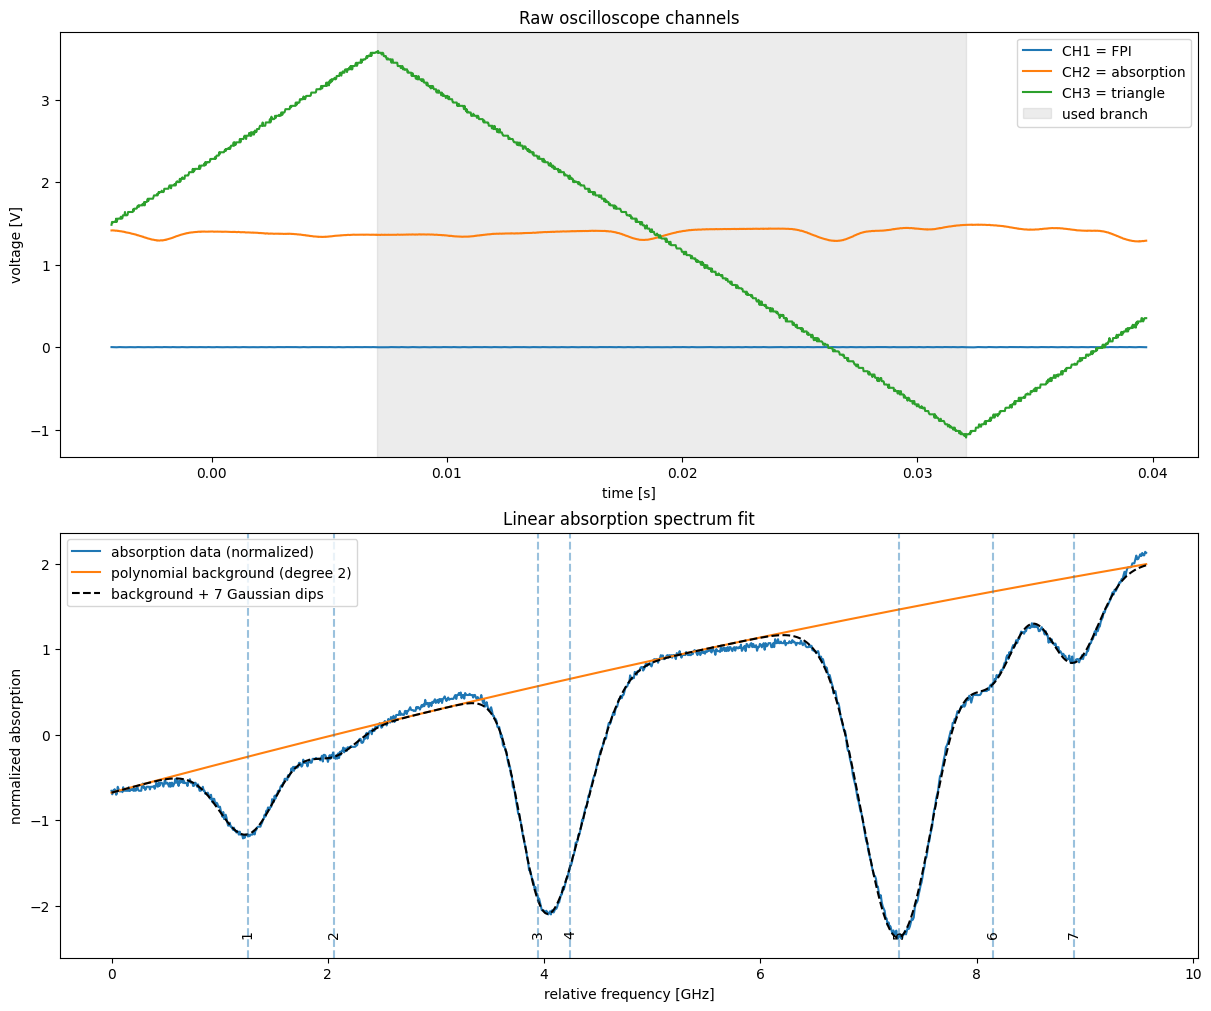

In [9]:


# ============================================================
# USER SETTINGS
# ============================================================

CSV_PATH = "scope_24.csv"

FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

FPI_MODE_SPACING_GHZ = 149.9348e-3  # GHz
USE_DESCENDING_BRANCH = True

MAIN_POLY_DEGREE = 2
MODEL_POLY_DEGREES = [1, 2, 3]
N_DIPS = 7

FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4

CALIB_POLY_DEGREE = 3

MANUAL_MU_GUESS = np.array([
    1.25,  # 87Rb 2->1
    2.05,  # 87Rb 2->2
    3.95,  # low 85Rb group component
    4.25,  # low 85Rb group component
    7.30,  # high 85Rb group
    8.16,  # 87Rb 1->1
    8.92,  # 87Rb 1->2
], dtype=float)

MANUAL_A_GUESS = np.array([
    -1.0,
    -0.25,
    -1.8,
    -1.8,
    -4.0,
    -1.0,
    -1.0,
], dtype=float)

MANUAL_SIGMA_GUESS = np.array([
    0.24,
    0.22,
    0.22,
    0.28,
    0.34,
    0.22,
    0.22,
], dtype=float)

N_BOOT = 250
BOOTSTRAP_SEED = 42

X_LIMITS = None

# ============================================================
# HELPERS
# ============================================================

def odd(n):
    n = int(n)
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path):
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t, tri, use_descending=True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t, fpi, degree=3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    calib_coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(calib_coeffs, t)
    nu_rel -= nu_rel.min()

    nu_fit_peaks = np.polyval(calib_coeffs, t_peaks)
    calib_residuals = nu_fit_peaks - nu_peaks
    calib_rms = np.sqrt(np.mean(calib_residuals**2))

    return {
        "nu_rel": nu_rel,
        "fpi_smooth": fpi_s,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "calib_coeffs": calib_coeffs,
        "calib_rms": calib_rms,
    }

def poly_background(x, coeffs):
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def build_model_function(poly_degree, n_dips=7):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x, y, poly_degree):
    pfit = np.polyfit(x, y, poly_degree)
    coeffs_guess = pfit[::-1]

    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]

    return np.array(p0, dtype=float)

def build_bounds(x, poly_degree):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for mu0 in MANUAL_MU_GUESS:
        lower += [-8.0, max(x0, mu0 - 1.0), 0.02]
        upper += [ 0.0, min(x1, mu0 + 1.0), 1.50]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt, pcov, poly_degree, n_dips=7):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt, pcov, poly_degree, n_dips=7):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def weighted_average(vals, errs):
    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)
    w = 1.0 / errs**2
    mean = np.sum(w * vals) / np.sum(w)
    err = np.sqrt(1.0 / np.sum(w))
    return mean, err

def fit_spectrum(x, y, poly_degree):
    model = build_model_function(poly_degree, N_DIPS)
    p0 = build_initial_guess(x, y, poly_degree)
    lb, ub = build_bounds(x, poly_degree)

    popt, pcov = curve_fit(
        model,
        x, y,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, poly_degree, N_DIPS)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, poly_degree, N_DIPS)

    fit_total = model(x, *popt)
    fit_bg = poly_background(x, poly_coeffs)

    return {
        "poly_degree": poly_degree,
        "model": model,
        "popt": popt,
        "pcov": pcov,
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "lb": lb,
        "ub": ub,
    }

def extract_hyperfine_from_fit(gauss_params, gauss_errs, calib_rms=0.0):
    # peak 1 = 87Rb 2->1
    # peak 2 = 87Rb 2->2
    # peaks 3+4 = low-frequency 85Rb group
    # peak 5 = high-frequency 85Rb group
    # peak 6 = 87Rb 1->1
    # peak 7 = 87Rb 1->2

    A = {i+1: gauss_params[i, 0] for i in range(N_DIPS)}
    mu = {i+1: gauss_params[i, 1] for i in range(N_DIPS)}
    dmu = {i+1: gauss_errs[i, 1] for i in range(N_DIPS)}

    # 85Rb
    w3 = abs(A[3])
    w4 = abs(A[4])
    mu85_low = (w3 * mu[3] + w4 * mu[4]) / (w3 + w4)
    dmu85_low_formal = np.sqrt(
        (w3/(w3+w4) * dmu[3])**2 +
        (w4/(w3+w4) * dmu[4])**2
    )

    mu85_high = mu[5]
    dmu85_high = dmu[5]

    Delta85 = mu85_high - mu85_low
    dDelta85_formal = np.sqrt(dmu85_low_formal**2 + dmu85_high**2 + 2*calib_rms**2)

    A85_over_h = Delta85 / 3.0
    dA85_formal = dDelta85_formal / 3.0

    # 87Rb
    Delta87_Fp1 = mu[6] - mu[1]
    dDelta87_Fp1_formal = np.sqrt(dmu[6]**2 + dmu[1]**2 + 2*calib_rms**2)

    Delta87_Fp2 = mu[7] - mu[2]
    dDelta87_Fp2_formal = np.sqrt(dmu[7]**2 + dmu[2]**2 + 2*calib_rms**2)

    Delta87_avg, dDelta87_avg_formal = weighted_average(
        [Delta87_Fp1, Delta87_Fp2],
        [dDelta87_Fp1_formal, dDelta87_Fp2_formal]
    )

    A87_over_h = Delta87_avg / 2.0
    dA87_formal = dDelta87_avg_formal / 2.0

    return {
        "A85_over_h": A85_over_h,
        "dA85_formal": dA85_formal,
        "Delta85": Delta85,
        "dDelta85_formal": dDelta85_formal,
        "A87_over_h": A87_over_h,
        "dA87_formal": dA87_formal,
        "Delta87_avg": Delta87_avg,
        "dDelta87_avg_formal": dDelta87_avg_formal,
    }

def bootstrap_hyperfine(x, y, fit_result, calib_rms, n_boot=200, seed=42):
    rng = np.random.default_rng(seed)
    model = fit_result["model"]
    popt = fit_result["popt"]
    lb = fit_result["lb"]
    ub = fit_result["ub"]
    poly_degree = fit_result["poly_degree"]
    fit_total = fit_result["fit_total"]

    residuals = y - fit_total

    boot_A85 = []
    boot_A87 = []
    boot_D85 = []
    boot_D87 = []

    for _ in range(n_boot):
        y_boot = fit_total + rng.choice(residuals, size=len(residuals), replace=True)

        try:
            popt_b, pcov_b = curve_fit(
                model,
                x, y_boot,
                p0=popt,
                bounds=(lb, ub),
                maxfev=200000
            )
            popt_b, pcov_b = sort_fit_by_mu(popt_b, pcov_b, poly_degree, N_DIPS)
            _, gp_b, ge_b = unpack_fit(popt_b, pcov_b, poly_degree, N_DIPS)

            ex = extract_hyperfine_from_fit(gp_b, ge_b, calib_rms=calib_rms)

            boot_A85.append(ex["A85_over_h"])
            boot_A87.append(ex["A87_over_h"])
            boot_D85.append(ex["Delta85"])
            boot_D87.append(ex["Delta87_avg"])

        except Exception:
            continue

    boot_A85 = np.array(boot_A85)
    boot_A87 = np.array(boot_A87)
    boot_D85 = np.array(boot_D85)
    boot_D87 = np.array(boot_D87)

    return {
        "A85_boot_err": np.std(boot_A85, ddof=1) if len(boot_A85) > 1 else np.nan,
        "A87_boot_err": np.std(boot_A87, ddof=1) if len(boot_A87) > 1 else np.nan,
        "D85_boot_err": np.std(boot_D85, ddof=1) if len(boot_D85) > 1 else np.nan,
        "D87_boot_err": np.std(boot_D87, ddof=1) if len(boot_D87) > 1 else np.nan,
    }

# ============================================================
# LOAD DATA
# ============================================================

df = load_scope_csv(CSV_PATH)

t_all = df["time_s"].to_numpy()
fpi_all = df[FPI_COL].to_numpy()
abs_all = df[ABS_COL].to_numpy()
tri_all = df[TRI_COL].to_numpy()

branch, tri_smooth = choose_monotonic_branch(
    t_all, tri_all, use_descending=USE_DESCENDING_BRANCH
)

t = t_all[branch]
fpi = fpi_all[branch]
abs_sig = abs_all[branch]

# ============================================================
# CALIBRATION
# ============================================================

cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
nu_rel = cal["nu_rel"]
calib_rms = cal["calib_rms"]

print(f"Number of FPI peaks used: {len(cal['peak_idx'])}")
print(f"Calibration RMS uncertainty: {calib_rms:.6f} GHz")

# normalize absorption
y = (abs_sig - abs_sig.mean()) / abs_sig.std()

# ============================================================
# MAIN FIT
# ============================================================

main_fit = fit_spectrum(nu_rel, y, MAIN_POLY_DEGREE)
gauss_params = main_fit["gauss_params"]
gauss_errs = main_fit["gauss_errs"]
fit_total = main_fit["fit_total"]
fit_bg = main_fit["fit_bg"]

main_ex = extract_hyperfine_from_fit(gauss_params, gauss_errs, calib_rms=calib_rms)

# ============================================================
# MODEL SPREAD
# ============================================================

A85_models = []
A87_models = []
D85_models = []
D87_models = []

for deg in MODEL_POLY_DEGREES:
    fr = fit_spectrum(nu_rel, y, deg)
    ex = extract_hyperfine_from_fit(fr["gauss_params"], fr["gauss_errs"], calib_rms=calib_rms)

    A85_models.append(ex["A85_over_h"])
    A87_models.append(ex["A87_over_h"])
    D85_models.append(ex["Delta85"])
    D87_models.append(ex["Delta87_avg"])

A85_model_err = np.std(A85_models, ddof=1) if len(A85_models) > 1 else 0.0
A87_model_err = np.std(A87_models, ddof=1) if len(A87_models) > 1 else 0.0
D85_model_err = np.std(D85_models, ddof=1) if len(D85_models) > 1 else 0.0
D87_model_err = np.std(D87_models, ddof=1) if len(D87_models) > 1 else 0.0

# ============================================================
# BOOTSTRAP
# ============================================================

boot = bootstrap_hyperfine(
    nu_rel, y, main_fit,
    calib_rms=calib_rms,
    n_boot=N_BOOT,
    seed=BOOTSTRAP_SEED
)

# ============================================================
# FINAL ERRORS
# ============================================================

A85_total_err = np.sqrt(
    main_ex["dA85_formal"]**2 +
    A85_model_err**2 +
    boot["A85_boot_err"]**2
)

A87_total_err = np.sqrt(
    main_ex["dA87_formal"]**2 +
    A87_model_err**2 +
    boot["A87_boot_err"]**2
)

print("\n================ FINAL RESULTS ================\n")
print(f"85Rb ground-state hyperfine constant:")
print(f"A85/h = {main_ex['A85_over_h']:.6f} ± {A85_total_err:.6f} GHz")

print(f"\n87Rb ground-state hyperfine constant:")
print(f"A87/h = {main_ex['A87_over_h']:.6f} ± {A87_total_err:.6f} GHz")

# ============================================================
# PLOTS: only 2 panels
# ============================================================

fig, axs = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)

# raw oscilloscope channels
axs[0].plot(t_all, df["ch1"], label="CH1 = FPI")
axs[0].plot(t_all, df["ch2"], label="CH2 = absorption")
axs[0].plot(t_all, df["ch3"], label="CH3 = triangle")
axs[0].axvspan(t[0], t[-1], color="gray", alpha=0.15, label="used branch")
axs[0].set_xlabel("time [s]")
axs[0].set_ylabel("voltage [V]")
axs[0].set_title("Raw oscilloscope channels")
axs[0].legend()

# linear absorption spectrum fit
axs[1].plot(nu_rel, y, label="absorption data (normalized)")
axs[1].plot(nu_rel, fit_bg, label=f"polynomial background (degree {MAIN_POLY_DEGREE})")
axs[1].plot(nu_rel, fit_total, "--", color="black", label="background + 7 Gaussian dips")

for i, (_, mu, _) in enumerate(gauss_params, start=1):
    axs[1].axvline(mu, ls="--", alpha=0.45)
    axs[1].text(mu, np.min(y), str(i), rotation=90, va="bottom", ha="center")

axs[1].set_xlabel("relative frequency [GHz]")
axs[1].set_ylabel("normalized absorption")
axs[1].set_title("Linear absorption spectrum fit")
if X_LIMITS is not None:
    axs[1].set_xlim(*X_LIMITS)
axs[1].legend()
plt.savefig("absorption_fit_5cm.png", dpi=300)
plt.show()

In [6]:
# ============================================================
# CHI-SQUARED / REDUCED CHI-SQUARED FOR THE ABSORPTION FIT
# ============================================================

# residuals
residuals = y - fit_total

# ------------------------------------------------------------
# Option 1: if you do NOT have point-by-point y-errors
# estimate sigma from residual scatter
# ------------------------------------------------------------
sigma_est = np.std(residuals, ddof=1)

chi2 = np.sum((residuals / sigma_est)**2)

# number of fitted parameters:
# polynomial coefficients + 3 parameters per Gaussian
n_params = (MAIN_POLY_DEGREE + 1) + 3 * N_DIPS

ndof = len(y) - n_params
chi2_red = chi2 / ndof

print("\n================ CHI-SQUARED =================\n")
print(f"Estimated sigma from residuals = {sigma_est:.6e}")
print(f"Number of data points          = {len(y)}")
print(f"Number of fit parameters       = {n_params}")
print(f"Degrees of freedom             = {ndof}")
print(f"Chi-squared                    = {chi2:.6f}")
print(f"Reduced chi-squared            = {chi2_red:.6f}")


================ CHI-SQUARED =================

Estimated sigma from residuals = 4.124206e-02
Number of data points          = 1137
Number of fit parameters       = 24
Degrees of freedom             = 1113
Chi-squared                    = 1136.000000
Reduced chi-squared            = 1.020665


In [7]:
# ============================================================
# PRINT FITTED PARAMETERS: BACKGROUND + GAUSSIANS
# ============================================================

# ---------- background ----------
print("\n================ BACKGROUND PARAMETERS ================\n")
for i, c in enumerate(main_fit["poly_coeffs"]):
    print(f"c{i} = {c:.10f}")

# if you also want uncertainties of the background coefficients:
n_poly = MAIN_POLY_DEGREE + 1
param_errs = np.sqrt(np.diag(main_fit["pcov"]))

print("\nBackground coefficients with uncertainties:")
for i in range(n_poly):
    print(f"c{i} = {main_fit['popt'][i]:.10f} ± {param_errs[i]:.10f}")

# ---------- Gaussian parameters ----------
print("\n================ GAUSSIAN PARAMETERS ================\n")
print(" idx        A ± dA              mu ± dmu [GHz]         sigma ± dsigma [GHz]")

gauss_params = main_fit["gauss_params"]
gauss_errs   = main_fit["gauss_errs"]

for i, ((A, mu, sigma), (dA, dmu, dsigma)) in enumerate(zip(gauss_params, gauss_errs), start=1):
    print(
        f"{i:>3d}   "
        f"{A: .10f} ± {dA:.10f}   "
        f"{mu: .10f} ± {dmu:.10f}   "
        f"{sigma: .10f} ± {dsigma:.10f}"
    )

# ---------- optional: as arrays for copy/paste ----------
print("\nA_fit =", gauss_params[:, 0])
print("mu_fit =", gauss_params[:, 1])
print("sigma_fit =", gauss_params[:, 2])

print("\ndA_fit =", gauss_errs[:, 0])
print("dmu_fit =", gauss_errs[:, 1])
print("dsigma_fit =", gauss_errs[:, 2])


================ BACKGROUND PARAMETERS ================

c0 = 0.2472016977
c1 = 0.1528017999
c2 = -0.0055151218

Background coefficients with uncertainties:
c0 = 0.2472016977 ± 0.0048209422
c1 = 0.1528017999 ± 0.0027584549
c2 = -0.0055151218 ± 0.0003529755

================ GAUSSIAN PARAMETERS ================

 idx        A ± dA              mu ± dmu [GHz]         sigma ± dsigma [GHz]
  1   -1.0448881239 ± 0.0073883080    1.2667218137 ± 0.0022052866    0.2428340989 ± 0.0025016968
  2   -0.2790136618 ± 0.0078259597    2.0518489277 ± 0.0078935136    0.2133733718 ± 0.0084690723
  3   -1.9370516930 ± 0.5050256426    3.9570585127 ± 0.0134790683    0.2113858814 ± 0.0095859282
  4   -1.8313610249 ± 0.3256670032    4.2497007974 ± 0.0603638850    0.2801147309 ± 0.0194558193
  5   -4.1915554331 ± 0.0076454617    7.2843403020 ± 0.0007974172    0.3365140069 ± 0.0009471414
  6   -1.0164522608 ± 0.0099072944    8.1490763191 ± 0.0026285481    0.2119769927 ± 0.0031081858
  7   -1.1024732485 ± 0.0107


================ DEPTH COMPARISON =================

2 cm cell:
  raw branch depth              = 0.105670 V
  baseline-normalized depth     = 0.113125
  min raw voltage               = 0.766730 V
  max raw voltage               = 0.872400 V
  min normalized transmission   = 0.908276
  max normalized transmission   = 1.021401

5 cm cell:
  raw branch depth              = 0.194742 V
  baseline-normalized depth     = 0.127034
  min raw voltage               = 1.287283 V
  max raw voltage               = 1.482025 V
  min normalized transmission   = 0.896662
  max normalized transmission   = 1.023695

Depth ratio (5 cm cell) / (2 cm cell) = 1.843


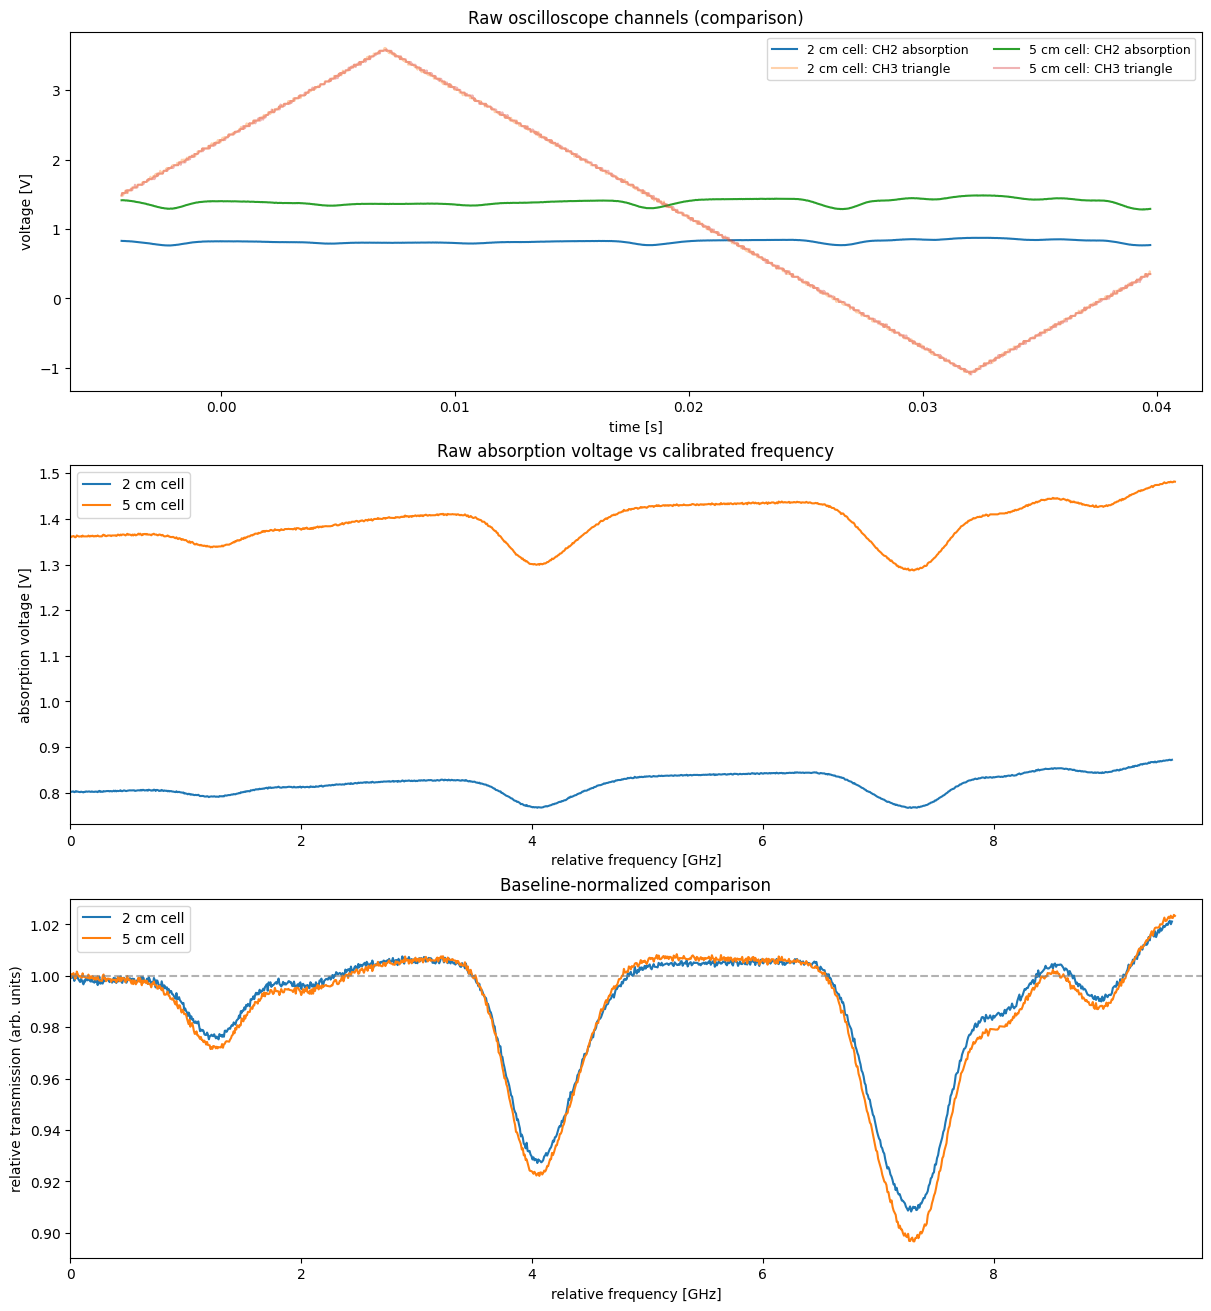

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_PATHS = {
    "2 cm cell": "scope_23.csv",
    "5 cm cell": "scope_24.csv",
}

FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

FPI_MODE_SPACING_GHZ = 149.9348e-3  # GHz
USE_DESCENDING_BRANCH = True

FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4
CALIB_POLY_DEGREE = 3

# plotting
X_LIMITS = (0, 9.8)
Y_LIMITS_RAW = None          # e.g. (0.72, 0.92)
Y_LIMITS_BASELINE = None     # e.g. (0.75, 1.02)

# ============================================================
# HELPERS
# ============================================================

def odd(n):
    n = int(n)
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path):
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t, tri, use_descending=True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t, fpi, degree=3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    calib_coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(calib_coeffs, t)
    nu_rel -= nu_rel.min()

    return {
        "nu_rel": nu_rel,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "calib_coeffs": calib_coeffs,
    }

def estimate_off_resonance_baseline(nu, y, exclusion_centers=None, exclusion_halfwidth=0.35, poly_degree=2):
    """
    Fit a smooth baseline only to regions away from known resonances.
    """
    if exclusion_centers is None:
        exclusion_centers = [1.27, 2.05, 3.96, 4.25, 7.28, 8.15, 8.91]

    mask = np.ones_like(nu, dtype=bool)
    for c in exclusion_centers:
        mask &= np.abs(nu - c) > exclusion_halfwidth

    # fallback if too much got excluded
    if np.sum(mask) < 20:
        coeffs = np.polyfit(nu, y, 1)
    else:
        coeffs = np.polyfit(nu[mask], y[mask], poly_degree)

    baseline = np.polyval(coeffs, nu)
    return baseline, coeffs, mask

# ============================================================
# LOAD + CALIBRATE BOTH DATASETS
# ============================================================

results = {}

for label, path in CSV_PATHS.items():
    df = load_scope_csv(path)

    t_all = df["time_s"].to_numpy()
    fpi_all = df[FPI_COL].to_numpy()
    abs_all = df[ABS_COL].to_numpy()
    tri_all = df[TRI_COL].to_numpy()

    branch, tri_smooth = choose_monotonic_branch(
        t_all, tri_all, use_descending=USE_DESCENDING_BRANCH
    )

    t = t_all[branch]
    fpi = fpi_all[branch]
    abs_sig = abs_all[branch]
    tri = tri_all[branch]

    cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
    nu_rel = cal["nu_rel"]

    # raw absorption branch
    y_raw = abs_sig.copy()

    # baseline-normalized transmission-like curve
    baseline, coeffs, mask_used = estimate_off_resonance_baseline(nu_rel, y_raw)
    y_baseline_norm = y_raw / baseline

    results[label] = {
        "df": df,
        "t_all": t_all,
        "fpi_all": fpi_all,
        "abs_all": abs_all,
        "tri_all": tri_all,
        "branch": branch,
        "tri_smooth": tri_smooth,
        "t": t,
        "fpi": fpi,
        "abs_sig": abs_sig,
        "nu_rel": nu_rel,
        "y_raw": y_raw,
        "baseline": baseline,
        "y_baseline_norm": y_baseline_norm,
        "baseline_mask": mask_used,
    }

# ============================================================
# NUMERICAL COMPARISON
# ============================================================

print("\n================ DEPTH COMPARISON =================\n")
for label, r in results.items():
    depth_raw = np.max(r["y_raw"]) - np.min(r["y_raw"])
    depth_norm = np.max(r["y_baseline_norm"]) - np.min(r["y_baseline_norm"])
    print(f"{label}:")
    print(f"  raw branch depth              = {depth_raw:.6f} V")
    print(f"  baseline-normalized depth     = {depth_norm:.6f}")
    print(f"  min raw voltage               = {np.min(r['y_raw']):.6f} V")
    print(f"  max raw voltage               = {np.max(r['y_raw']):.6f} V")
    print(f"  min normalized transmission   = {np.min(r['y_baseline_norm']):.6f}")
    print(f"  max normalized transmission   = {np.max(r['y_baseline_norm']):.6f}")
    print()

labels = list(results.keys())
if len(labels) == 2:
    d1 = np.max(results[labels[0]]["y_raw"]) - np.min(results[labels[0]]["y_raw"])
    d2 = np.max(results[labels[1]]["y_raw"]) - np.min(results[labels[1]]["y_raw"])
    print(f"Depth ratio ({labels[1]}) / ({labels[0]}) = {d2/d1:.3f}")

# ============================================================
# PLOTS
# ============================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 13), constrained_layout=True)

# ------------------------------------------------------------
# 1) raw oscilloscope channels for both files
# ------------------------------------------------------------
for label, r in results.items():
    axs[0].plot(r["t_all"], r["abs_all"], label=f"{label}: CH2 absorption")
    axs[0].plot(r["t_all"], r["tri_all"], alpha=0.35, label=f"{label}: CH3 triangle")

axs[0].set_xlabel("time [s]")
axs[0].set_ylabel("voltage [V]")
axs[0].set_title("Raw oscilloscope channels (comparison)")
axs[0].legend(ncol=2, fontsize=9)

# ------------------------------------------------------------
# 2) raw absorption voltage on same calibrated frequency axis
# ------------------------------------------------------------
for label, r in results.items():
    axs[1].plot(r["nu_rel"], r["y_raw"], label=f"{label}")

axs[1].set_xlabel("relative frequency [GHz]")
axs[1].set_ylabel("absorption voltage [V]")
axs[1].set_title("Raw absorption voltage vs calibrated frequency")
axs[1].legend()
if X_LIMITS is not None:
    axs[1].set_xlim(*X_LIMITS)
if Y_LIMITS_RAW is not None:
    axs[1].set_ylim(*Y_LIMITS_RAW)

# ------------------------------------------------------------
# 3) baseline-normalized comparison
# ------------------------------------------------------------
for label, r in results.items():
    axs[2].plot(r["nu_rel"], r["y_baseline_norm"], label=f"{label}")

axs[2].axhline(1.0, color="gray", ls="--", alpha=0.6)
axs[2].set_xlabel("relative frequency [GHz]")
axs[2].set_ylabel("relative transmission (arb. units)")
axs[2].set_title("Baseline-normalized comparison")
axs[2].legend()
if X_LIMITS is not None:
    axs[2].set_xlim(*X_LIMITS)
if Y_LIMITS_BASELINE is not None:
    axs[2].set_ylim(*Y_LIMITS_BASELINE)

plt.savefig("compare_2cm_5cm_cells.png", dpi=300)
plt.show()

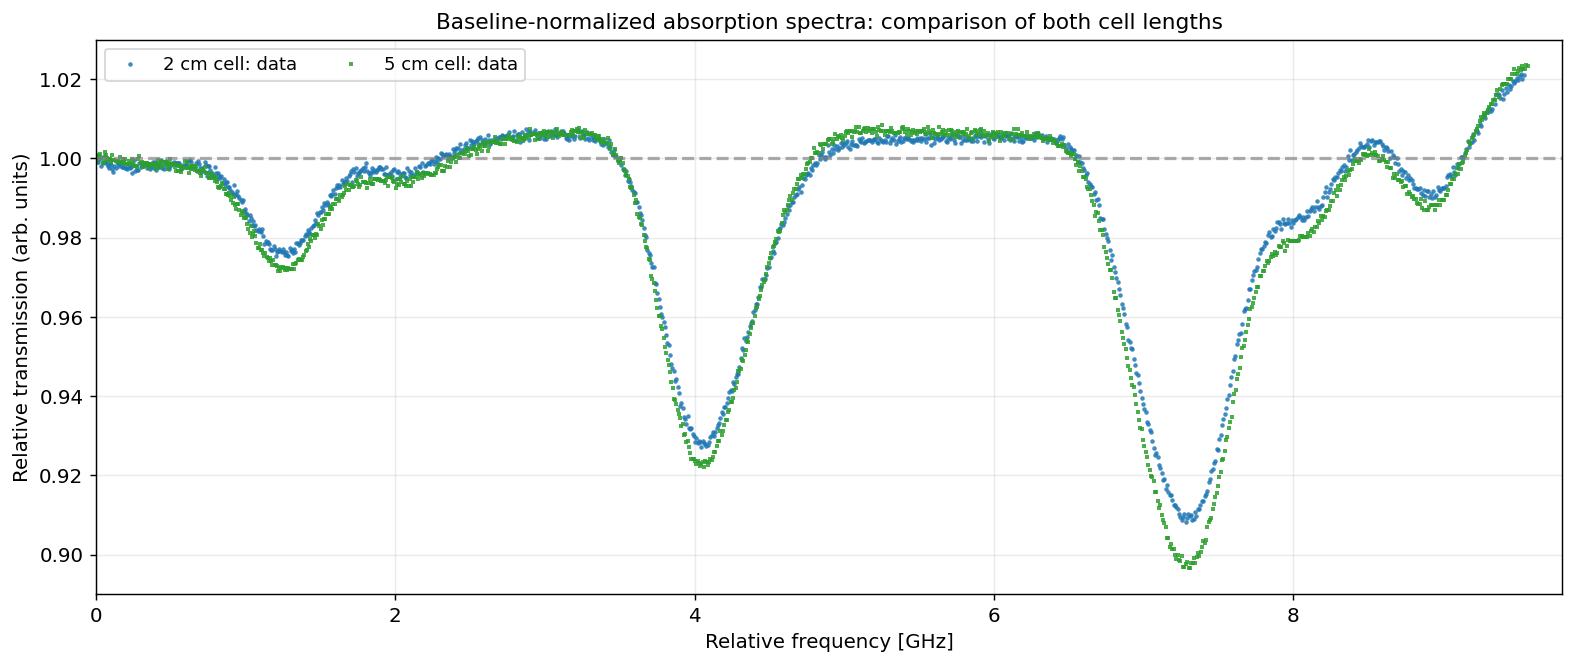

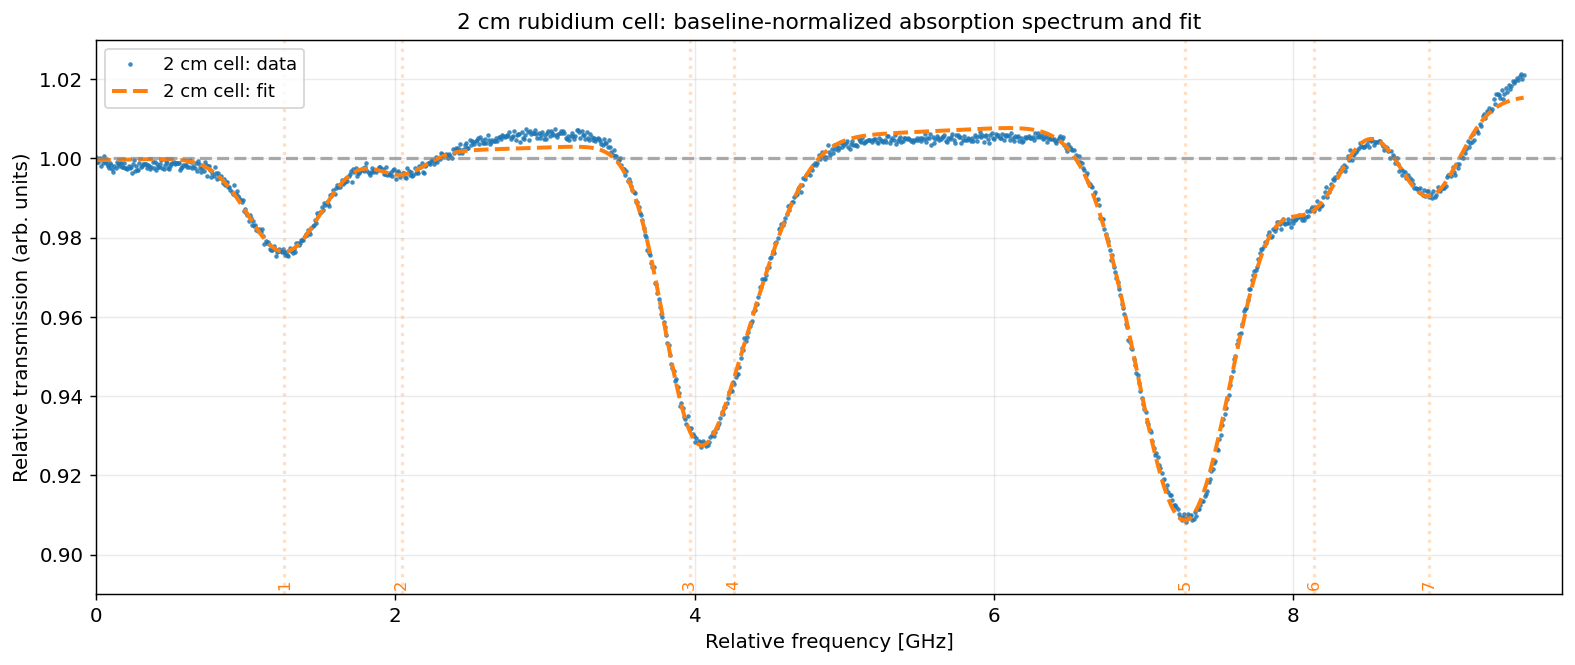

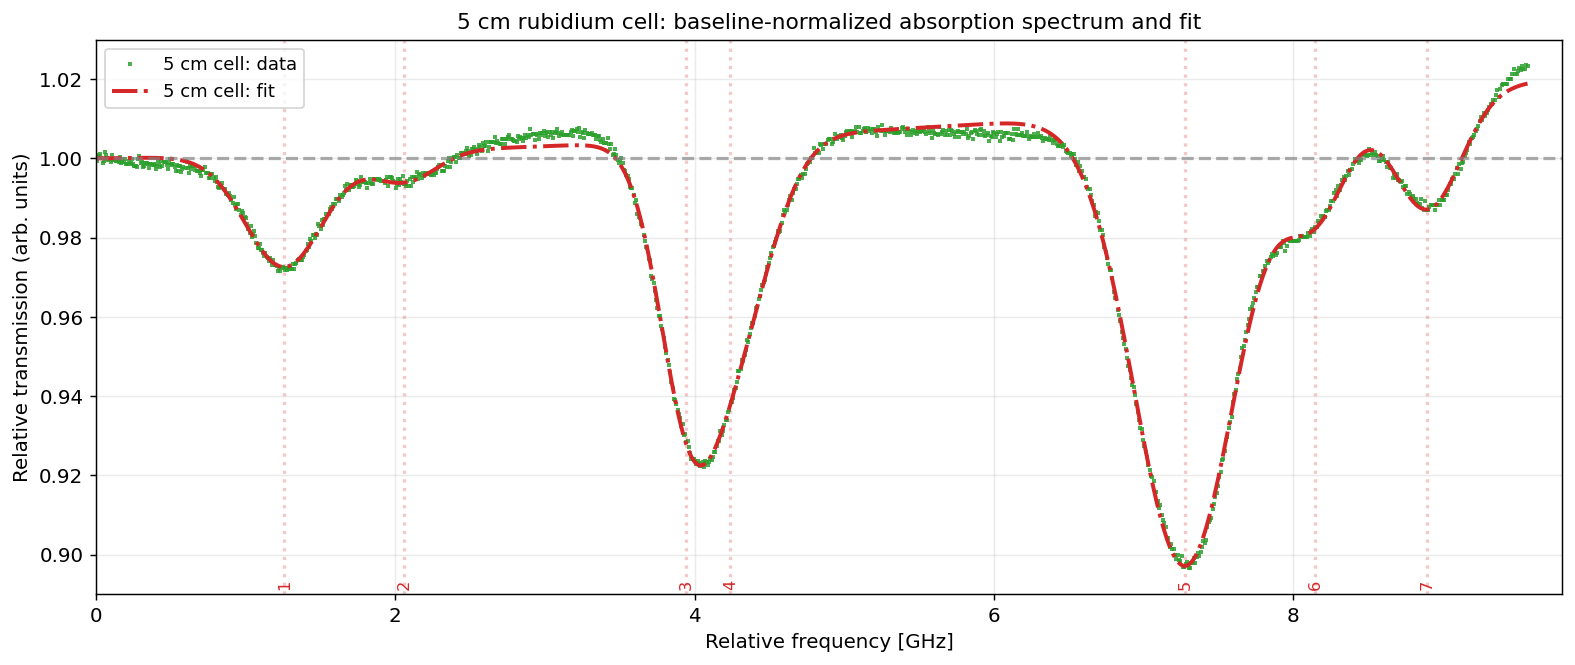


================ FIT PARAMETERS: 2 cm cell ================

Peak 1: A = -0.024276 ± 0.000288, mu = 1.258470 ± 0.003273 GHz, sigma = 0.243501 ± 0.003758 GHz
Peak 2: A = -0.005549 ± 0.000343, mu = 2.042237 ± 0.011978 GHz, sigma = 0.162537 ± 0.012616 GHz
Peak 3: A = -0.048456 ± 0.018137, mu = 3.967725 ± 0.018453 GHz, sigma = 0.209536 ± 0.014550 GHz
Peak 4: A = -0.042311 ± 0.011516, mu = 4.262409 ± 0.095183 GHz, sigma = 0.282148 ± 0.031175 GHz
Peak 5: A = -0.101636 ± 0.000293, mu = 7.279696 ± 0.001201 GHz, sigma = 0.330881 ± 0.001432 GHz
Peak 6: A = -0.021731 ± 0.000384, mu = 8.143038 ± 0.004465 GHz, sigma = 0.204748 ± 0.005057 GHz
Peak 7: A = -0.023489 ± 0.000407, mu = 8.908453 ± 0.003666 GHz, sigma = 0.206991 ± 0.005097 GHz

================ FIT PARAMETERS: 5 cm cell ================

Peak 1: A = -0.028372 ± 0.000258, mu = 1.257828 ± 0.003075 GHz, sigma = 0.259566 ± 0.003535 GHz
Peak 2: A = -0.007721 ± 0.000279, mu = 2.057723 ± 0.010490 GHz, sigma = 0.213130 ± 0.011009 GHz
Peak 3: A = 

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_PATHS = {
    "2 cm cell": "scope_23.csv",
    "5 cm cell": "scope_24.csv",
}

FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

FPI_MODE_SPACING_GHZ = 149.9348e-3  # GHz
USE_DESCENDING_BRANCH = True

FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4
CALIB_POLY_DEGREE = 3

FIT_POLY_DEGREE = 2
N_DIPS = 7

MANUAL_MU_GUESS = np.array([1.27, 2.05, 3.96, 4.25, 7.28, 8.15, 8.91], dtype=float)
MANUAL_A_GUESS  = np.array([-0.025, -0.008, -0.060, -0.035, -0.095, -0.020, -0.018], dtype=float)
MANUAL_SIGMA_GUESS = np.array([0.22, 0.20, 0.22, 0.26, 0.32, 0.22, 0.22], dtype=float)

X_LIMITS = (0, 9.8)
Y_LIMITS_NORM = (0.89, 1.03)

SAVE_COMBINED = "cells_comparison_datapoints_only.png"
SAVE_2CM = "fit_2cm_cell.png"
SAVE_5CM = "fit_5cm_cell.png"

# Different colors for data and fit
STYLE = {
    "2 cm cell": {
        "data_color": "tab:blue",
        "fit_color": "tab:orange",
        "fit_linestyle": "--",
        "marker": "o",
    },
    "5 cm cell": {
        "data_color": "tab:green",
        "fit_color": "tab:red",
        "fit_linestyle": "-.",
        "marker": "s",
    },
}

# ============================================================
# PLOT STYLE
# ============================================================

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
})

# ============================================================
# HELPERS
# ============================================================

def odd(n):
    n = int(n)
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path):
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t, tri, use_descending=True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t, fpi, degree=3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    calib_coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(calib_coeffs, t)
    nu_rel -= nu_rel.min()

    return {
        "nu_rel": nu_rel,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "calib_coeffs": calib_coeffs,
    }

def estimate_off_resonance_baseline(nu, y, exclusion_centers=None, exclusion_halfwidth=0.35, poly_degree=2):
    if exclusion_centers is None:
        exclusion_centers = MANUAL_MU_GUESS

    mask = np.ones_like(nu, dtype=bool)
    for c in exclusion_centers:
        mask &= np.abs(nu - c) > exclusion_halfwidth

    if np.sum(mask) < 20:
        coeffs = np.polyfit(nu, y, 1)
    else:
        coeffs = np.polyfit(nu[mask], y[mask], poly_degree)

    baseline = np.polyval(coeffs, nu)
    return baseline, coeffs, mask

def poly_background(x, coeffs):
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def build_model_function(poly_degree, n_dips):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x, y, poly_degree):
    coeffs_guess = np.polyfit(x, y, poly_degree)[::-1]
    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]
    return np.array(p0, dtype=float)

def build_bounds(x, poly_degree):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for i, mu0 in enumerate(MANUAL_MU_GUESS):
        amp_low = -1.0
        amp_high = 0.0
        sigma_high = 0.50 if i in [2, 3, 4] else 0.35

        lower += [amp_low, max(x0, mu0 - 0.45), 0.03]
        upper += [amp_high, min(x1, mu0 + 0.45), sigma_high]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt, pcov, poly_degree, n_dips):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt, pcov, poly_degree, n_dips):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def fit_normalized_spectrum(nu_rel, y_norm, poly_degree=2, n_dips=7):
    model = build_model_function(poly_degree, n_dips)
    p0 = build_initial_guess(nu_rel, y_norm, poly_degree)
    lb, ub = build_bounds(nu_rel, poly_degree)

    popt, pcov = curve_fit(
        model,
        nu_rel, y_norm,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, poly_degree, n_dips)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, poly_degree, n_dips)
    fit_total = model(nu_rel, *popt)
    fit_bg = poly_background(nu_rel, poly_coeffs)
    residuals = y_norm - fit_total

    return {
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "residuals": residuals,
        "popt": popt,
        "pcov": pcov,
    }

# ============================================================
# LOAD + CALIBRATE + FIT
# ============================================================

results = {}

for label, path in CSV_PATHS.items():
    df = load_scope_csv(path)

    t_all = df["time_s"].to_numpy()
    fpi_all = df[FPI_COL].to_numpy()
    abs_all = df[ABS_COL].to_numpy()
    tri_all = df[TRI_COL].to_numpy()

    branch, tri_smooth = choose_monotonic_branch(
        t_all, tri_all, use_descending=USE_DESCENDING_BRANCH
    )

    t = t_all[branch]
    fpi = fpi_all[branch]
    abs_sig = abs_all[branch]

    cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
    nu_rel = cal["nu_rel"]

    baseline, coeffs, mask_used = estimate_off_resonance_baseline(nu_rel, abs_sig)
    y_baseline_norm = abs_sig / baseline

    fit = fit_normalized_spectrum(nu_rel, y_baseline_norm, poly_degree=FIT_POLY_DEGREE, n_dips=N_DIPS)

    results[label] = {
        "df": df,
        "t_all": t_all,
        "abs_all": abs_all,
        "tri_all": tri_all,
        "branch": branch,
        "tri_smooth": tri_smooth,
        "t": t,
        "fpi": fpi,
        "abs_sig": abs_sig,
        "nu_rel": nu_rel,
        "baseline": baseline,
        "baseline_coeffs": coeffs,
        "baseline_mask": mask_used,
        "y_baseline_norm": y_baseline_norm,
        "fit": fit,
    }

# ============================================================
# FIGURE 1: BOTH DATA SETS TOGETHER (DATA POINTS ONLY)
# ============================================================

fig1, ax1 = plt.subplots(figsize=(12, 5), constrained_layout=True)

for label, r in results.items():
    style = STYLE[label]
    ax1.plot(
        r["nu_rel"], r["y_baseline_norm"],
        linestyle="None",
        marker=style["marker"],
        markersize=2.5,
        markerfacecolor=style["data_color"],
        markeredgewidth=0,
        alpha=0.85,
        label=f"{label}: data"
    )

ax1.axhline(1.0, color="gray", linestyle="--", alpha=0.65)
ax1.set_title("Baseline-normalized absorption spectra: comparison of both cell lengths")
ax1.set_xlabel("Relative frequency [GHz]")
ax1.set_ylabel("Relative transmission (arb. units)")
ax1.legend(ncol=2, loc="best", frameon=True)
if X_LIMITS is not None:
    ax1.set_xlim(*X_LIMITS)
if Y_LIMITS_NORM is not None:
    ax1.set_ylim(*Y_LIMITS_NORM)

plt.savefig(SAVE_COMBINED, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 2: 2 CM CELL (DATA + FIT)
# ============================================================

label = "2 cm cell"
r = results[label]
style = STYLE[label]

fig2, ax2 = plt.subplots(figsize=(12, 5), constrained_layout=True)

ax2.plot(
    r["nu_rel"], r["y_baseline_norm"],
    linestyle="None",
    marker=style["marker"],
    markersize=2.5,
    markerfacecolor=style["data_color"],
    markeredgewidth=0,
    alpha=0.85,
    label=f"{label}: data"
)

ax2.plot(
    r["nu_rel"], r["fit"]["fit_total"],
    color=style["fit_color"],
    linestyle=style["fit_linestyle"],
    linewidth=2.2,
    label=f"{label}: fit"
)

for i, (_, mu, _) in enumerate(r["fit"]["gauss_params"], start=1):
    ax2.axvline(mu, color=style["fit_color"], linestyle=":", alpha=0.25)
    ax2.text(mu, 0.891, str(i), rotation=90, ha="center", va="bottom", fontsize=9, color=style["fit_color"])

ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.65)
ax2.set_title("2 cm rubidium cell: baseline-normalized absorption spectrum and fit")
ax2.set_xlabel("Relative frequency [GHz]")
ax2.set_ylabel("Relative transmission (arb. units)")
ax2.legend(loc="best", frameon=True)
if X_LIMITS is not None:
    ax2.set_xlim(*X_LIMITS)
if Y_LIMITS_NORM is not None:
    ax2.set_ylim(*Y_LIMITS_NORM)

plt.savefig(SAVE_2CM, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 3: 5 CM CELL (DATA + FIT)
# ============================================================

label = "5 cm cell"
r = results[label]
style = STYLE[label]

fig3, ax3 = plt.subplots(figsize=(12, 5), constrained_layout=True)

ax3.plot(
    r["nu_rel"], r["y_baseline_norm"],
    linestyle="None",
    marker=style["marker"],
    markersize=2.5,
    markerfacecolor=style["data_color"],
    markeredgewidth=0,
    alpha=0.85,
    label=f"{label}: data"
)

ax3.plot(
    r["nu_rel"], r["fit"]["fit_total"],
    color=style["fit_color"],
    linestyle=style["fit_linestyle"],
    linewidth=2.2,
    label=f"{label}: fit"
)

for i, (_, mu, _) in enumerate(r["fit"]["gauss_params"], start=1):
    ax3.axvline(mu, color=style["fit_color"], linestyle=":", alpha=0.25)
    ax3.text(mu, 0.891, str(i), rotation=90, ha="center", va="bottom", fontsize=9, color=style["fit_color"])

ax3.axhline(1.0, color="gray", linestyle="--", alpha=0.65)
ax3.set_title("5 cm rubidium cell: baseline-normalized absorption spectrum and fit")
ax3.set_xlabel("Relative frequency [GHz]")
ax3.set_ylabel("Relative transmission (arb. units)")
ax3.legend(loc="best", frameon=True)
if X_LIMITS is not None:
    ax3.set_xlim(*X_LIMITS)
if Y_LIMITS_NORM is not None:
    ax3.set_ylim(*Y_LIMITS_NORM)

plt.savefig(SAVE_5CM, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# OPTIONAL PARAMETER SUMMARY
# ============================================================

for label, r in results.items():
    print(f"\n================ FIT PARAMETERS: {label} ================\n")
    gp = r["fit"]["gauss_params"]
    ge = r["fit"]["gauss_errs"]
    for i, ((A, mu, sigma), (dA, dmu, dsigma)) in enumerate(zip(gp, ge), start=1):
        print(
            f"Peak {i}: "
            f"A = {A:.6f} ± {dA:.6f}, "
            f"mu = {mu:.6f} ± {dmu:.6f} GHz, "
            f"sigma = {sigma:.6f} ± {dsigma:.6f} GHz"
        )


================ BEER-LAMBERT INPUT VALUES ================

Using target peak 1 = isolated left dip = transition 8 of 87Rb

  2 cm : L = 2.0 cm, mu = 1.25847 GHz, T(mu) = 0.976446, A = -ln(T) = 0.023836 ± 0.001650
  5 cm : L = 5.0 cm, mu = 1.25783 GHz, T(mu) = 0.972607, A = -ln(T) = 0.027776 ± 0.001522
  7 cm : L = 7.0 cm, mu = 1.26638 GHz, T(mu) = 0.944479, A = -ln(T) = 0.057122 ± 0.002390

================ BEER-LAMBERT FIT ================

Slope m      = 0.005098 ± 0.000540 cm^-1
Intercept b  = 0.010008 ± 0.002499
Chi-squared  = 53.469078
Reduced chi2 = 53.469078


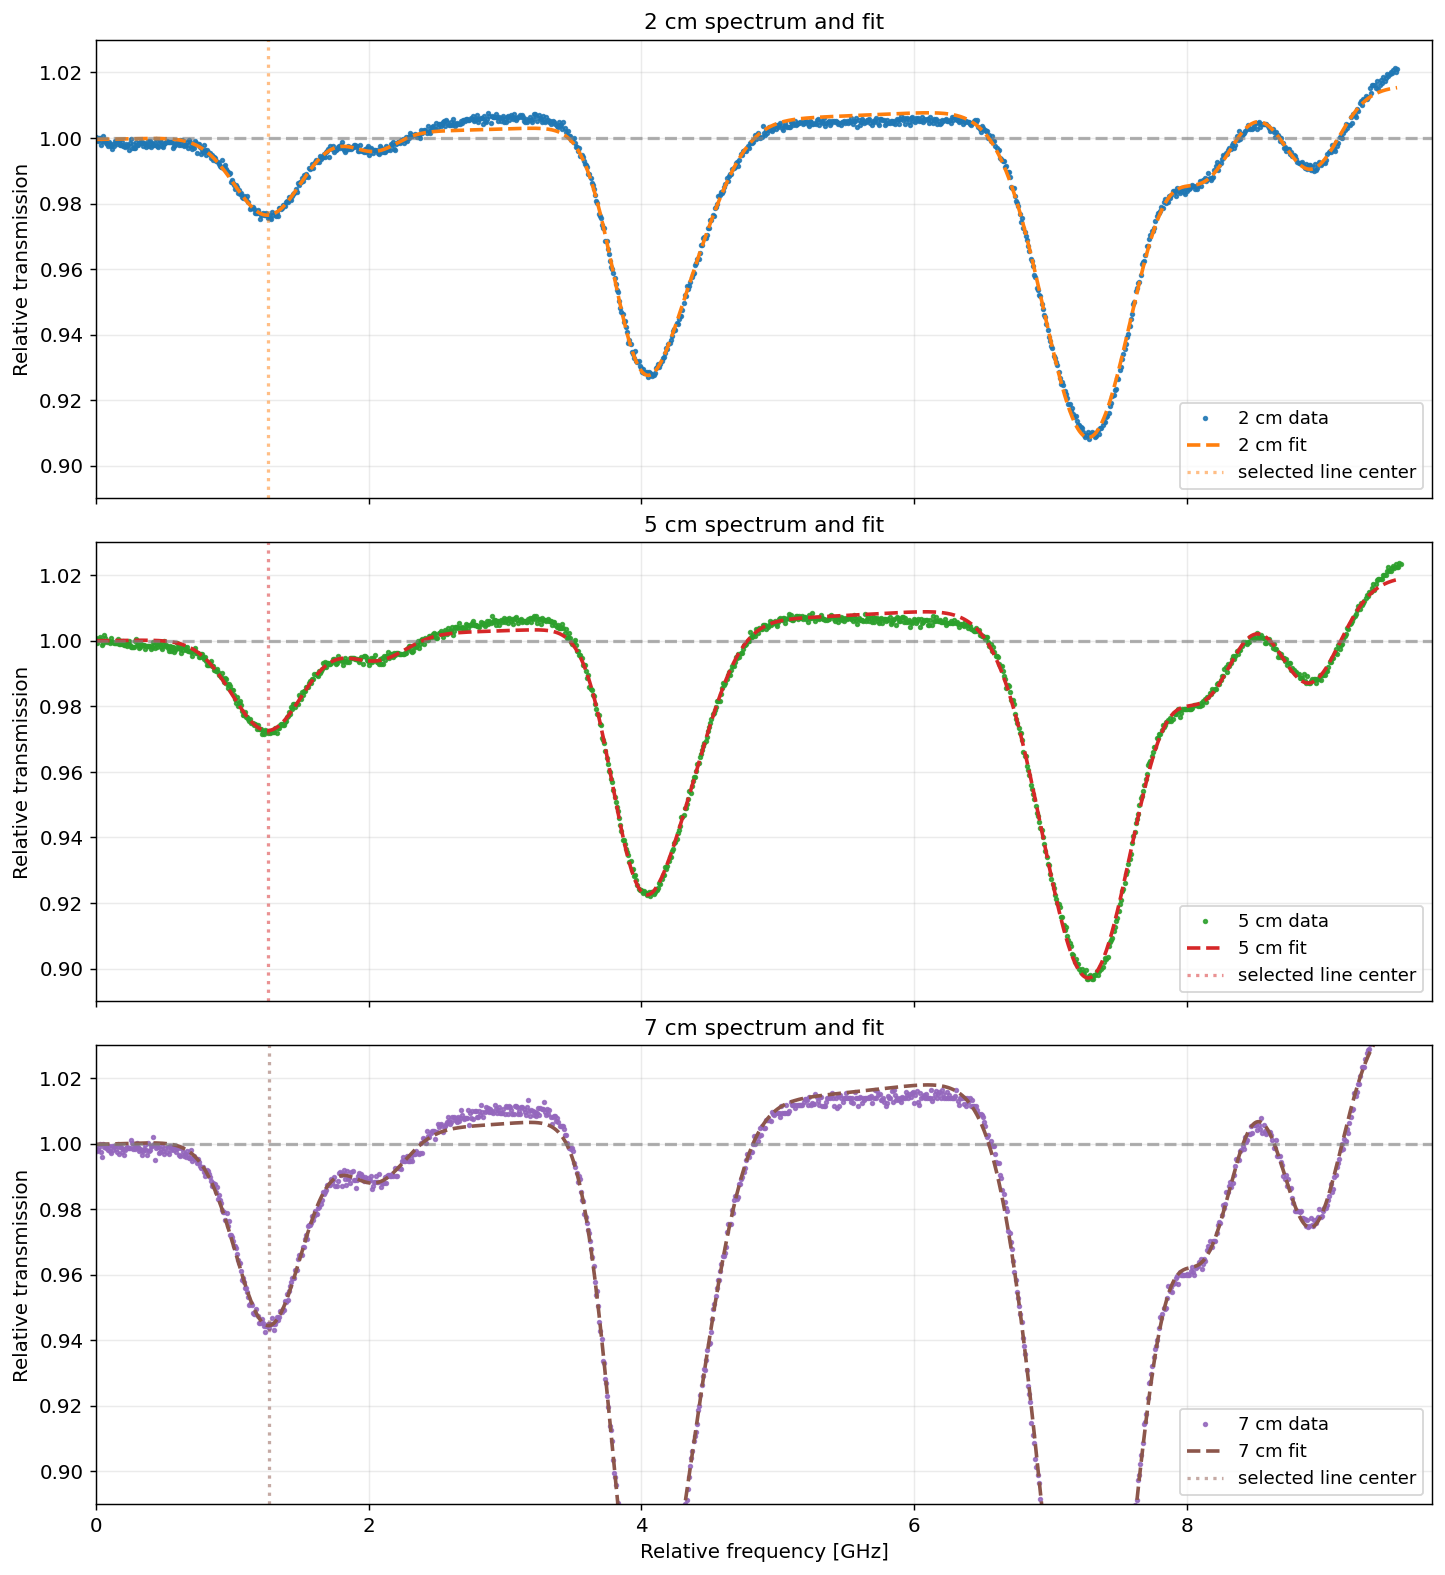

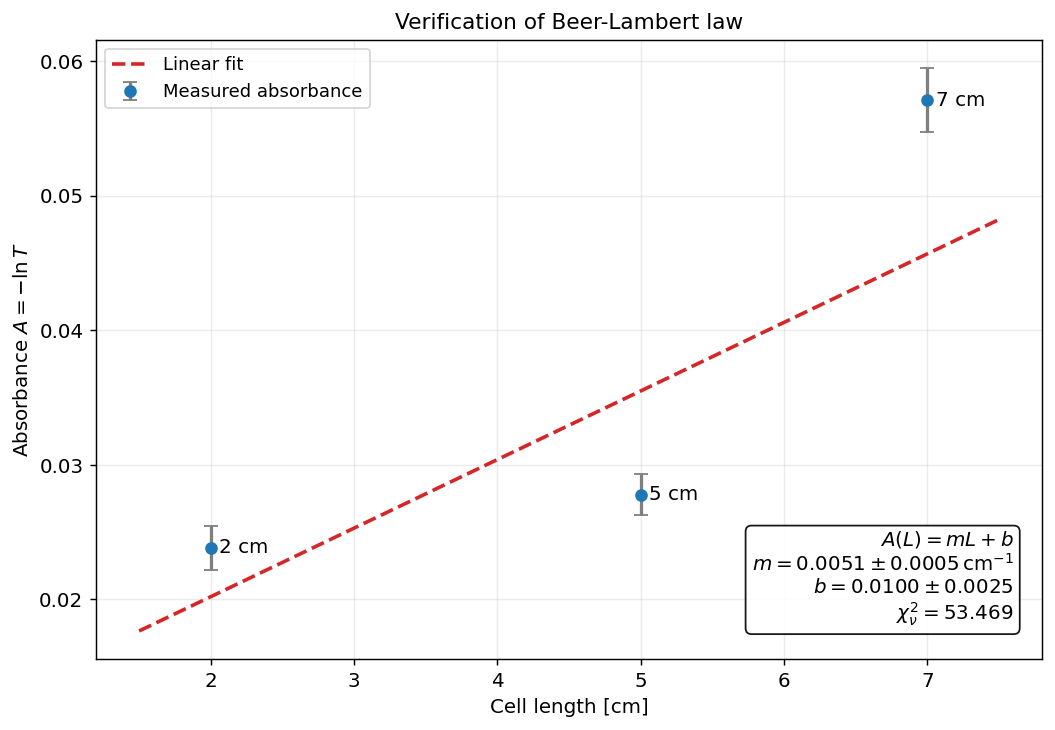

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_FILES = {
    "2 cm": {"path": "scope_23.csv", "L_cm": 2.0},
    "5 cm": {"path": "scope_24.csv", "L_cm": 5.0},
    "7 cm": {"path": "scope_20.csv", "L_cm": 7.0},
}

FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

FPI_MODE_SPACING_GHZ = 149.9348e-3
USE_DESCENDING_BRANCH = True

FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4
CALIB_POLY_DEGREE = 3

FIT_POLY_DEGREE = 2
N_DIPS = 7

# Peak assignment used for Beer-Lambert verification:
# Use fit peak 1 = isolated left dip = transition 8 of 87Rb
TARGET_PEAK_INDEX = 0  # Python index, so 0 means "peak 1"

MANUAL_MU_GUESS = np.array([1.27, 2.05, 3.96, 4.25, 7.28, 8.15, 8.91], dtype=float)
MANUAL_A_GUESS = np.array([-0.025, -0.008, -0.060, -0.035, -0.095, -0.020, -0.018], dtype=float)
MANUAL_SIGMA_GUESS = np.array([0.22, 0.20, 0.22, 0.26, 0.32, 0.22, 0.22], dtype=float)

X_LIMITS = (0, 9.8)
Y_LIMITS_SPEC = (0.89, 1.03)

SAVE_SPECTRA = "beer_lambert_spectra.png"
SAVE_BEER = "beer_lambert_fit.png"

# ============================================================
# HELPERS
# ============================================================

def odd(n: int) -> int:
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t: np.ndarray, tri: np.ndarray, use_descending: bool = True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t: np.ndarray, fpi: np.ndarray, degree: int = 3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(coeffs, t)
    nu_rel -= nu_rel.min()

    return {
        "nu_rel": nu_rel,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "coeffs": coeffs,
    }

def estimate_off_resonance_baseline(
    nu: np.ndarray,
    y: np.ndarray,
    exclusion_centers=None,
    exclusion_halfwidth: float = 0.35,
    poly_degree: int = 2
):
    if exclusion_centers is None:
        exclusion_centers = MANUAL_MU_GUESS

    mask = np.ones_like(nu, dtype=bool)
    for c in exclusion_centers:
        mask &= np.abs(nu - c) > exclusion_halfwidth

    if np.sum(mask) < 20:
        coeffs = np.polyfit(nu, y, 1)
    else:
        coeffs = np.polyfit(nu[mask], y[mask], poly_degree)

    baseline = np.polyval(coeffs, nu)
    return baseline, coeffs, mask

def poly_background(x: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x: np.ndarray, A: float, mu: float, sigma: float) -> np.ndarray:
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def build_model_function(poly_degree: int, n_dips: int):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x: np.ndarray, y: np.ndarray, poly_degree: int) -> np.ndarray:
    coeffs_guess = np.polyfit(x, y, poly_degree)[::-1]
    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]
    return np.array(p0, dtype=float)

def build_bounds(x: np.ndarray, poly_degree: int):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for i, mu0 in enumerate(MANUAL_MU_GUESS):
        sigma_high = 0.50 if i in [2, 3, 4] else 0.35
        lower += [-1.0, max(x0, mu0 - 0.45), 0.03]
        upper += [0.0, min(x1, mu0 + 0.45), sigma_high]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt: np.ndarray, pcov: np.ndarray, poly_degree: int, n_dips: int):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt: np.ndarray, pcov: np.ndarray, poly_degree: int, n_dips: int):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)
    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def fit_normalized_spectrum(nu_rel: np.ndarray, y_norm: np.ndarray):
    model = build_model_function(FIT_POLY_DEGREE, N_DIPS)
    p0 = build_initial_guess(nu_rel, y_norm, FIT_POLY_DEGREE)
    lb, ub = build_bounds(nu_rel, FIT_POLY_DEGREE)

    popt, pcov = curve_fit(
        model,
        nu_rel, y_norm,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, FIT_POLY_DEGREE, N_DIPS)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, FIT_POLY_DEGREE, N_DIPS)

    fit_total = model(nu_rel, *popt)
    fit_bg = poly_background(nu_rel, poly_coeffs)

    return {
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "popt": popt,
        "pcov": pcov,
    }

def linear_model(x, m, b):
    return m * x + b

# ============================================================
# LOAD, CALIBRATE, NORMALIZE, FIT
# ============================================================

results = {}

for label, meta in CSV_FILES.items():
    df = load_scope_csv(meta["path"])

    t_all = df["time_s"].to_numpy()
    fpi_all = df[FPI_COL].to_numpy()
    abs_all = df[ABS_COL].to_numpy()
    tri_all = df[TRI_COL].to_numpy()

    branch, _ = choose_monotonic_branch(t_all, tri_all, use_descending=USE_DESCENDING_BRANCH)

    t = t_all[branch]
    fpi = fpi_all[branch]
    abs_sig = abs_all[branch]

    cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
    nu_rel = cal["nu_rel"]

    baseline, baseline_coeffs, baseline_mask = estimate_off_resonance_baseline(nu_rel, abs_sig)
    T_rel = abs_sig / baseline

    fit = fit_normalized_spectrum(nu_rel, T_rel)

    # Beer-Lambert value from fitted line-center transmission of target peak
    mu_target = fit["gauss_params"][TARGET_PEAK_INDEX, 1]
    T_target = np.interp(mu_target, nu_rel, fit["fit_total"])

    # Protect against numerical problems
    if T_target <= 0 or T_target >= 1.5:
        raise RuntimeError(f"Unphysical fitted transmission for {label}: T={T_target:.6f}")

    absorbance = -np.log(T_target)

    # simple uncertainty estimate from target-peak center error
    dmu_target = fit["gauss_errs"][TARGET_PEAK_INDEX, 1]
    T_plus = np.interp(mu_target + dmu_target, nu_rel, fit["fit_total"])
    T_minus = np.interp(mu_target - dmu_target, nu_rel, fit["fit_total"])
    dA_mu = 0.5 * abs((-np.log(T_plus)) - (-np.log(T_minus)))

    # residual-based floor
    residuals = T_rel - fit["fit_total"]
    dT_floor = np.std(residuals, ddof=1)
    dA_floor = dT_floor / max(T_target, 1e-9)

    dA = np.sqrt(dA_mu**2 + dA_floor**2)

    results[label] = {
        "L_cm": meta["L_cm"],
        "nu_rel": nu_rel,
        "T_rel": T_rel,
        "baseline": baseline,
        "baseline_mask": baseline_mask,
        "fit": fit,
        "mu_target": mu_target,
        "T_target": T_target,
        "A_target": absorbance,
        "dA_target": dA,
    }

# ============================================================
# BEER-LAMBERT FIT
# ============================================================

labels_sorted = sorted(results.keys(), key=lambda k: results[k]["L_cm"])
L = np.array([results[k]["L_cm"] for k in labels_sorted], dtype=float)
A = np.array([results[k]["A_target"] for k in labels_sorted], dtype=float)
dA = np.array([results[k]["dA_target"] for k in labels_sorted], dtype=float)

popt, pcov = curve_fit(
    linear_model, L, A,
    sigma=dA,
    absolute_sigma=True
)
m_fit, b_fit = popt
dm_fit, db_fit = np.sqrt(np.diag(pcov))

A_fit = linear_model(L, m_fit, b_fit)
chi2 = np.sum(((A - A_fit) / dA) ** 2)
ndof = len(L) - 2
chi2_red = chi2 / ndof if ndof > 0 else np.nan

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n================ BEER-LAMBERT INPUT VALUES ================\n")
print("Using target peak 1 = isolated left dip = transition 8 of 87Rb\n")
for k in labels_sorted:
    r = results[k]
    print(f"{k:>6s} : L = {r['L_cm']:.1f} cm, "
          f"mu = {r['mu_target']:.5f} GHz, "
          f"T(mu) = {r['T_target']:.6f}, "
          f"A = -ln(T) = {r['A_target']:.6f} ± {r['dA_target']:.6f}")

print("\n================ BEER-LAMBERT FIT ================\n")
print(f"Slope m      = {m_fit:.6f} ± {dm_fit:.6f} cm^-1")
print(f"Intercept b  = {b_fit:.6f} ± {db_fit:.6f}")
print(f"Chi-squared  = {chi2:.6f}")
print(f"Reduced chi2 = {chi2_red:.6f}")

# ============================================================
# FIGURE 1: THREE SPECTRA WITH FITS
# ============================================================

fig1, axs = plt.subplots(3, 1, figsize=(11, 12), constrained_layout=True, sharex=True)

colors = {
    "2 cm": ("tab:blue", "tab:orange"),
    "5 cm": ("tab:green", "tab:red"),
    "7 cm": ("tab:purple", "tab:brown"),
}

for ax, k in zip(axs, labels_sorted):
    r = results[k]
    data_color, fit_color = colors[k]

    ax.plot(r["nu_rel"], r["T_rel"], linestyle="None", marker="o", markersize=2.0,
            color=data_color, alpha=0.85, label=f"{k} data")
    ax.plot(r["nu_rel"], r["fit"]["fit_total"], linestyle="--", color=fit_color,
            linewidth=2.0, label=f"{k} fit")

    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.6)
    ax.axvline(r["mu_target"], color=fit_color, linestyle=":", alpha=0.5,
               label=f"selected line center")
    ax.set_ylabel("Relative transmission")
    ax.set_title(f"{k} spectrum and fit")
    ax.legend(loc="best", frameon=True)
    if X_LIMITS is not None:
        ax.set_xlim(*X_LIMITS)
    if Y_LIMITS_SPEC is not None:
        ax.set_ylim(*Y_LIMITS_SPEC)

axs[-1].set_xlabel("Relative frequency [GHz]")
plt.savefig(SAVE_SPECTRA, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 2: BEER-LAMBERT PLOT
# ============================================================

fig2, ax2 = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

ax2.errorbar(
    L, A, yerr=dA,
    fmt="o", capsize=4, color="tab:blue", ecolor="tab:gray",
    label="Measured absorbance"
)

L_dense = np.linspace(1.5, 7.5, 300)
ax2.plot(L_dense, linear_model(L_dense, m_fit, b_fit),
         linestyle="--", color="tab:red", linewidth=2.0,
         label="Linear fit")

for x, y, lbl in zip(L, A, labels_sorted):
    ax2.text(x + 0.06, y, lbl, va="center")

ax2.set_xlabel("Cell length [cm]")
ax2.set_ylabel(r"Absorbance $A=-\ln T$")
ax2.set_title("Verification of Beer-Lambert law")
ax2.legend(loc="best", frameon=True)
ax2.grid(True, alpha=0.25)

fit_text = (
    f"$A(L)=mL+b$\n"
    f"$m={m_fit:.4f}\\pm{dm_fit:.4f}\\,\\mathrm{{cm^{{-1}}}}$\n"
    f"$b={b_fit:.4f}\\pm{db_fit:.4f}$\n"
    f"$\\chi^2_\\nu={chi2_red:.3f}$"
)
ax2.text(
    0.97, 0.05, fit_text,
    transform=ax2.transAxes,
    ha="right", va="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.savefig(SAVE_BEER, dpi=300, bbox_inches="tight")
plt.show()

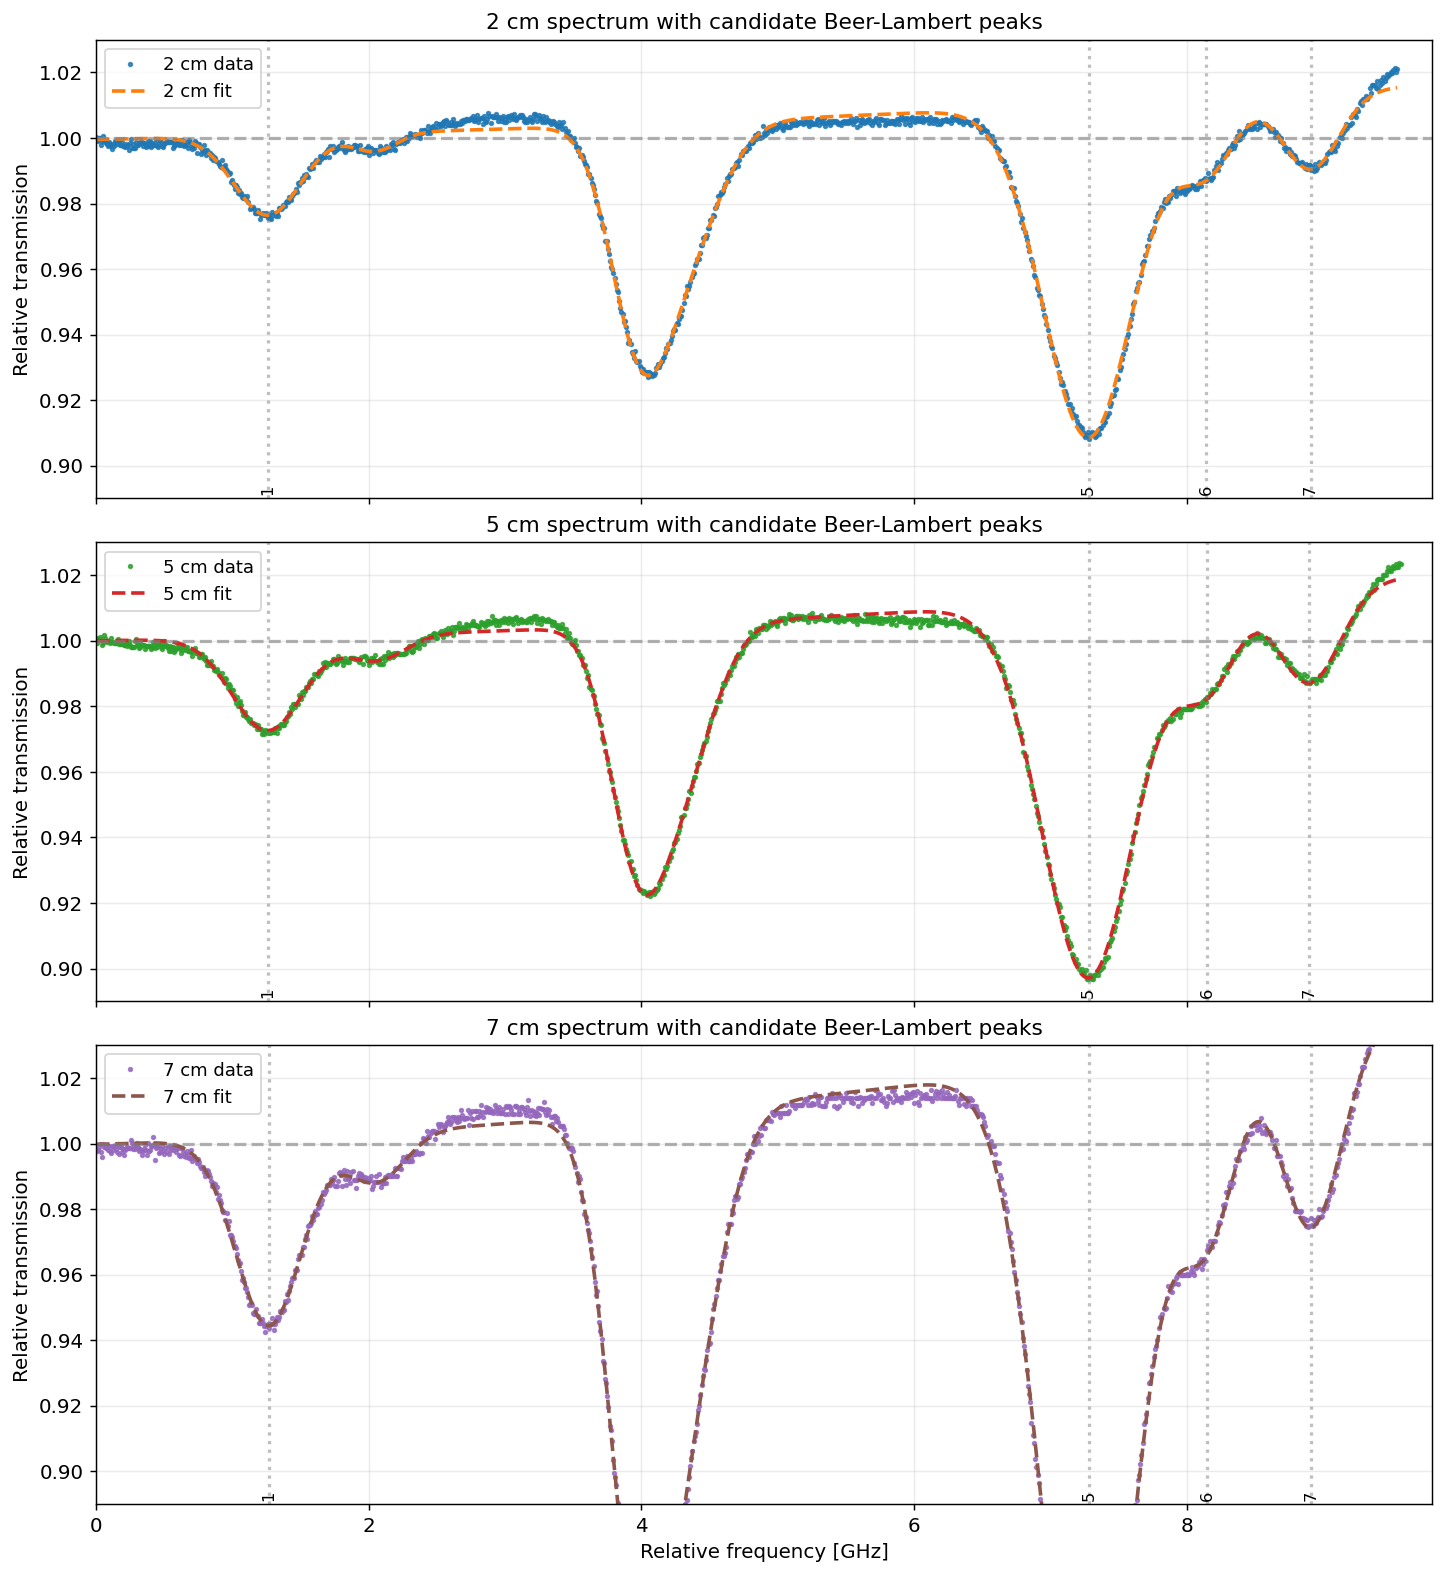

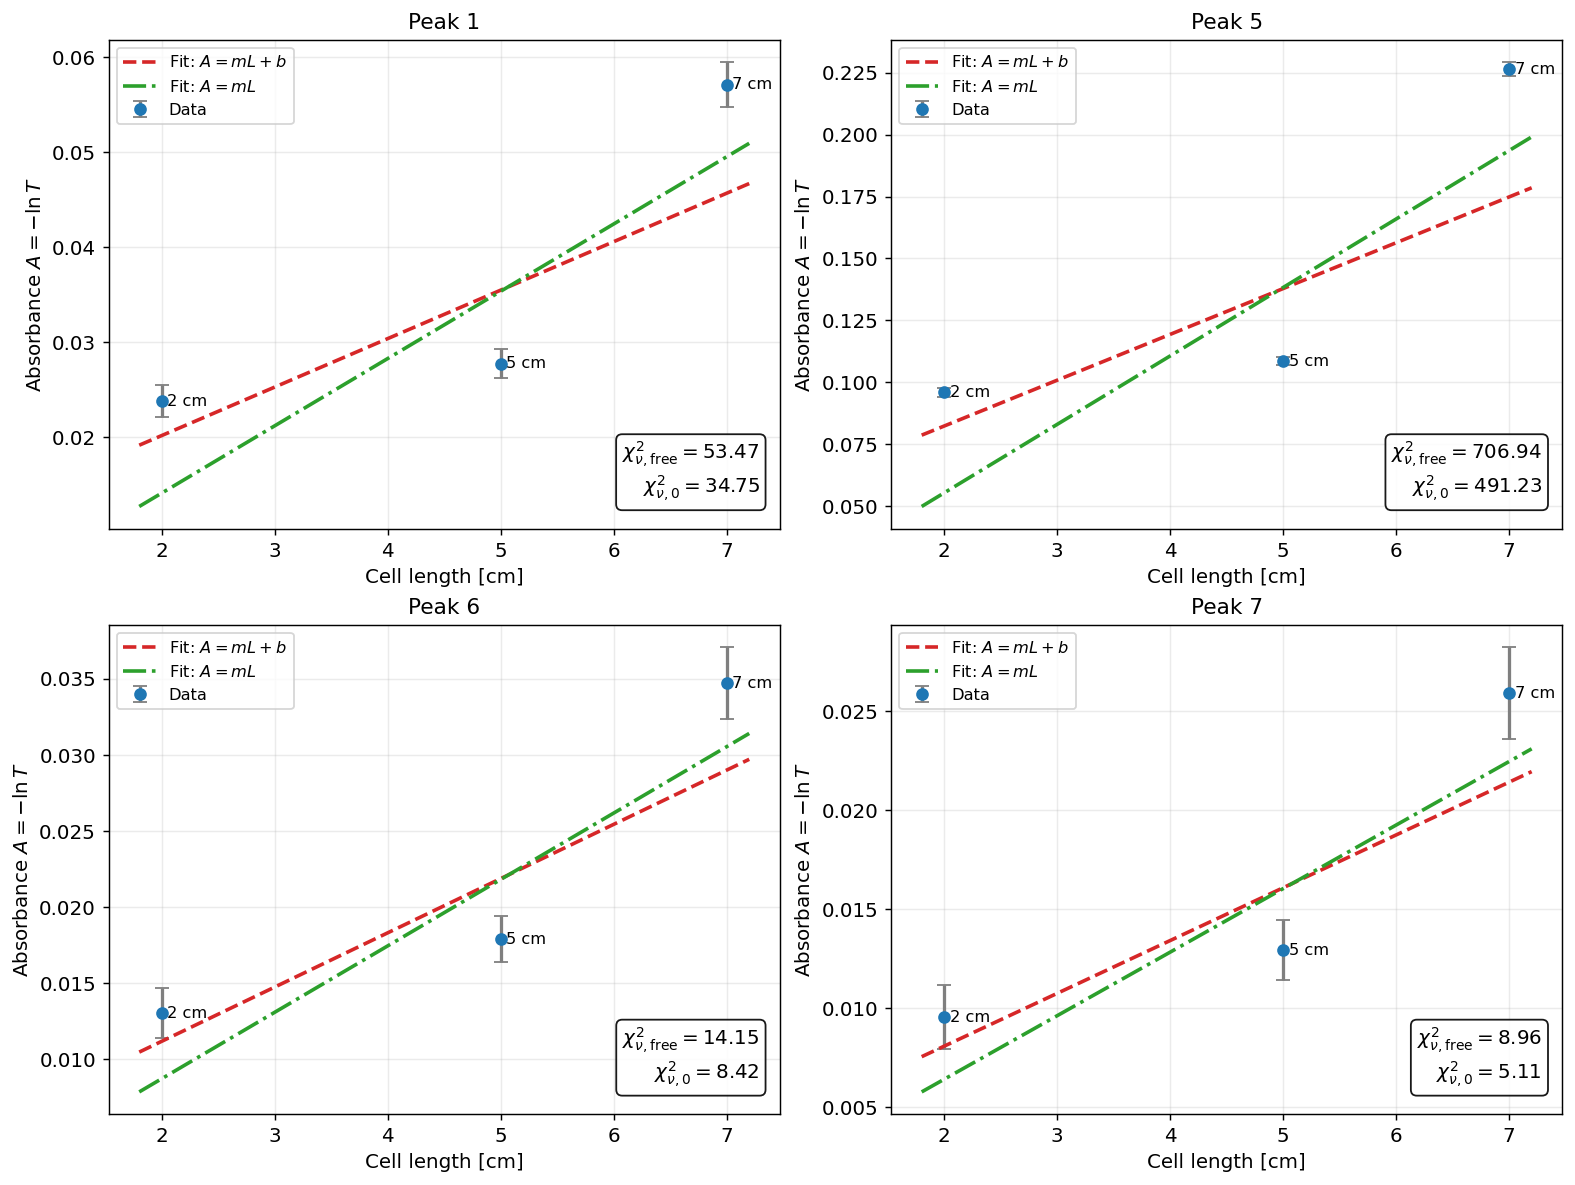


================ BEER-LAMBERT CANDIDATE SUMMARY ================

 peak   m_free  dm_free   b_free  db_free  chi2red_free   m_zero  dm_zero  chi2red_zero    A_2cm    A_5cm    A_7cm
    1 0.005098 0.000540 0.010008 0.002499     53.469078 0.007076 0.000219     34.752899 0.023836 0.027776 0.057122
    5 0.018507 0.000603 0.045278 0.002728    706.943983 0.027651 0.000246    491.232796 0.095820 0.108542 0.226557
    6 0.003563 0.000534 0.004055 0.002475     14.147791 0.004362 0.000216      8.415729 0.013043 0.017902 0.034721
    7 0.002665 0.000529 0.002756 0.002457      8.957984 0.003208 0.000214      5.107891 0.009563 0.012947 0.025905

================ RECOMMENDED CHOICE ================

Best candidate peak (by smallest reduced chi^2 for A = mL): Peak 7
Through-zero slope        : 0.003208 ± 0.000214 cm^-1
Reduced chi^2 (through 0) : 5.107891
Free-intercept fit        : m = 0.002665 ± 0.000529 cm^-1
                           b = 0.002756 ± 0.002457
Reduced chi^2 (free)      : 8.957984

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_FILES = {
    "2 cm": {"path": "scope_23.csv", "L_cm": 2.0},
    "5 cm": {"path": "scope_24.csv", "L_cm": 5.0},
    "7 cm": {"path": "scope_20.csv", "L_cm": 7.0},
}

FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

FPI_MODE_SPACING_GHZ = 149.9348e-3
USE_DESCENDING_BRANCH = True

FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4
CALIB_POLY_DEGREE = 3

FIT_POLY_DEGREE = 2
N_DIPS = 7

# Candidate peaks for Beer-Lambert check
# 1 = isolated left dip, 5 = strongest dip, 6/7 = right-side dips
CANDIDATE_PEAKS = [1, 5, 6, 7]   # 1-based indexing for readability

MANUAL_MU_GUESS = np.array([1.27, 2.05, 3.96, 4.25, 7.28, 8.15, 8.91], dtype=float)
MANUAL_A_GUESS = np.array([-0.025, -0.008, -0.060, -0.035, -0.095, -0.020, -0.018], dtype=float)
MANUAL_SIGMA_GUESS = np.array([0.22, 0.20, 0.22, 0.26, 0.32, 0.22, 0.22], dtype=float)

X_LIMITS = (0, 9.8)
Y_LIMITS_SPEC = (0.89, 1.03)

SAVE_SPECTRA = "beer_lambert_candidate_spectra.png"
SAVE_GRID = "beer_lambert_candidate_grid.png"

# ============================================================
# HELPERS
# ============================================================

def odd(n: int) -> int:
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t: np.ndarray, tri: np.ndarray, use_descending: bool = True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t: np.ndarray, fpi: np.ndarray, degree: int = 3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(coeffs, t)
    nu_rel -= nu_rel.min()

    return {
        "nu_rel": nu_rel,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "coeffs": coeffs,
    }

def estimate_off_resonance_baseline(
    nu: np.ndarray,
    y: np.ndarray,
    exclusion_centers=None,
    exclusion_halfwidth: float = 0.35,
    poly_degree: int = 2
):
    if exclusion_centers is None:
        exclusion_centers = MANUAL_MU_GUESS

    mask = np.ones_like(nu, dtype=bool)
    for c in exclusion_centers:
        mask &= np.abs(nu - c) > exclusion_halfwidth

    if np.sum(mask) < 20:
        coeffs = np.polyfit(nu, y, 1)
    else:
        coeffs = np.polyfit(nu[mask], y[mask], poly_degree)

    baseline = np.polyval(coeffs, nu)
    return baseline, coeffs, mask

def poly_background(x: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x: np.ndarray, A: float, mu: float, sigma: float) -> np.ndarray:
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def build_model_function(poly_degree: int, n_dips: int):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x: np.ndarray, y: np.ndarray, poly_degree: int) -> np.ndarray:
    coeffs_guess = np.polyfit(x, y, poly_degree)[::-1]
    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]
    return np.array(p0, dtype=float)

def build_bounds(x: np.ndarray, poly_degree: int):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for i, mu0 in enumerate(MANUAL_MU_GUESS):
        sigma_high = 0.50 if i in [2, 3, 4] else 0.35
        lower += [-1.0, max(x0, mu0 - 0.45), 0.03]
        upper += [0.0, min(x1, mu0 + 0.45), sigma_high]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt: np.ndarray, pcov: np.ndarray, poly_degree: int, n_dips: int):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt: np.ndarray, pcov: np.ndarray, poly_degree: int, n_dips: int):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)
    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def fit_normalized_spectrum(nu_rel: np.ndarray, y_norm: np.ndarray):
    model = build_model_function(FIT_POLY_DEGREE, N_DIPS)
    p0 = build_initial_guess(nu_rel, y_norm, FIT_POLY_DEGREE)
    lb, ub = build_bounds(nu_rel, FIT_POLY_DEGREE)

    popt, pcov = curve_fit(
        model,
        nu_rel, y_norm,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, FIT_POLY_DEGREE, N_DIPS)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, FIT_POLY_DEGREE, N_DIPS)

    fit_total = model(nu_rel, *popt)
    fit_bg = poly_background(nu_rel, poly_coeffs)

    return {
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "popt": popt,
        "pcov": pcov,
    }

def line_free(x, m, b):
    return m * x + b

def line_through_zero(x, m):
    return m * x

# ============================================================
# LOAD, CALIBRATE, NORMALIZE, FIT
# ============================================================

results = {}

for label, meta in CSV_FILES.items():
    df = load_scope_csv(meta["path"])

    t_all = df["time_s"].to_numpy()
    fpi_all = df[FPI_COL].to_numpy()
    abs_all = df[ABS_COL].to_numpy()
    tri_all = df[TRI_COL].to_numpy()

    branch, _ = choose_monotonic_branch(t_all, tri_all, use_descending=USE_DESCENDING_BRANCH)

    t = t_all[branch]
    fpi = fpi_all[branch]
    abs_sig = abs_all[branch]

    cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
    nu_rel = cal["nu_rel"]

    baseline, baseline_coeffs, baseline_mask = estimate_off_resonance_baseline(nu_rel, abs_sig)
    T_rel = abs_sig / baseline

    fit = fit_normalized_spectrum(nu_rel, T_rel)

    results[label] = {
        "L_cm": meta["L_cm"],
        "nu_rel": nu_rel,
        "T_rel": T_rel,
        "baseline": baseline,
        "baseline_mask": baseline_mask,
        "fit": fit,
    }

# ============================================================
# FIGURE 1: SHOW CANDIDATE PEAKS ON ALL SPECTRA
# ============================================================

fig1, axs1 = plt.subplots(3, 1, figsize=(11, 12), constrained_layout=True, sharex=True)

colors = {
    "2 cm": ("tab:blue", "tab:orange"),
    "5 cm": ("tab:green", "tab:red"),
    "7 cm": ("tab:purple", "tab:brown"),
}

labels_sorted = sorted(results.keys(), key=lambda k: results[k]["L_cm"])

for ax, k in zip(axs1, labels_sorted):
    r = results[k]
    data_color, fit_color = colors[k]

    ax.plot(r["nu_rel"], r["T_rel"], linestyle="None", marker="o", markersize=2.0,
            color=data_color, alpha=0.80, label=f"{k} data")
    ax.plot(r["nu_rel"], r["fit"]["fit_total"], linestyle="--", color=fit_color,
            linewidth=2.0, label=f"{k} fit")

    gp = r["fit"]["gauss_params"]
    for idx1 in CANDIDATE_PEAKS:
        mu = gp[idx1 - 1, 1]
        ax.axvline(mu, color="gray", linestyle=":", alpha=0.5)
        ax.text(mu, 0.891, f"{idx1}", rotation=90, ha="center", va="bottom", fontsize=9)

    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.6)
    ax.set_ylabel("Relative transmission")
    ax.set_title(f"{k} spectrum with candidate Beer-Lambert peaks")
    ax.legend(loc="best", frameon=True)
    if X_LIMITS is not None:
        ax.set_xlim(*X_LIMITS)
    if Y_LIMITS_SPEC is not None:
        ax.set_ylim(*Y_LIMITS_SPEC)

axs1[-1].set_xlabel("Relative frequency [GHz]")
plt.savefig(SAVE_SPECTRA, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ANALYZE MULTIPLE CANDIDATE PEAKS
# ============================================================

summary_rows = []

n_candidates = len(CANDIDATE_PEAKS)
fig2, axs2 = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axs2 = axs2.ravel()

for ax, peak_number in zip(axs2, CANDIDATE_PEAKS):
    peak_idx = peak_number - 1

    L = []
    A = []
    dA = []

    for k in labels_sorted:
        r = results[k]
        gp = r["fit"]["gauss_params"]
        ge = r["fit"]["gauss_errs"]

        mu = gp[peak_idx, 1]
        dmu = ge[peak_idx, 1]

        # Full fitted transmission at line center
        T_center = np.interp(mu, r["nu_rel"], r["fit"]["fit_total"])

        # Local uncertainty from center shift
        T_plus = np.interp(mu + dmu, r["nu_rel"], r["fit"]["fit_total"])
        T_minus = np.interp(mu - dmu, r["nu_rel"], r["fit"]["fit_total"])
        dA_mu = 0.5 * abs((-np.log(T_plus)) - (-np.log(T_minus)))

        # Residual-based uncertainty floor
        residuals = r["T_rel"] - r["fit"]["fit_total"]
        dT_floor = np.std(residuals, ddof=1)
        dA_floor = dT_floor / max(T_center, 1e-9)

        A_val = -np.log(T_center)
        dA_val = np.sqrt(dA_mu**2 + dA_floor**2)

        L.append(r["L_cm"])
        A.append(A_val)
        dA.append(dA_val)

    L = np.array(L, dtype=float)
    A = np.array(A, dtype=float)
    dA = np.array(dA, dtype=float)

    # ---------- fit with free intercept ----------
    popt_free, pcov_free = curve_fit(
        line_free, L, A,
        sigma=dA, absolute_sigma=True
    )
    m_free, b_free = popt_free
    dm_free, db_free = np.sqrt(np.diag(pcov_free))

    A_fit_free = line_free(L, m_free, b_free)
    chi2_free = np.sum(((A - A_fit_free) / dA) ** 2)
    ndof_free = len(L) - 2
    chi2red_free = chi2_free / ndof_free if ndof_free > 0 else np.nan

    # ---------- fit constrained through zero ----------
    popt_zero, pcov_zero = curve_fit(
        line_through_zero, L, A,
        sigma=dA, absolute_sigma=True
    )
    m_zero = popt_zero[0]
    dm_zero = np.sqrt(np.diag(pcov_zero))[0]

    A_fit_zero = line_through_zero(L, m_zero)
    chi2_zero = np.sum(((A - A_fit_zero) / dA) ** 2)
    ndof_zero = len(L) - 1
    chi2red_zero = chi2_zero / ndof_zero if ndof_zero > 0 else np.nan

    summary_rows.append({
        "peak": peak_number,
        "m_free": m_free,
        "dm_free": dm_free,
        "b_free": b_free,
        "db_free": db_free,
        "chi2red_free": chi2red_free,
        "m_zero": m_zero,
        "dm_zero": dm_zero,
        "chi2red_zero": chi2red_zero,
        "A_2cm": A[0],
        "A_5cm": A[1],
        "A_7cm": A[2],
    })

    # ---------- plot ----------
    ax.errorbar(
        L, A, yerr=dA,
        fmt="o", capsize=4, color="tab:blue", ecolor="tab:gray",
        label="Data"
    )

    L_dense = np.linspace(1.8, 7.2, 300)
    ax.plot(L_dense, line_free(L_dense, m_free, b_free),
            linestyle="--", color="tab:red", linewidth=2.0, label="Fit: $A=mL+b$")
    ax.plot(L_dense, line_through_zero(L_dense, m_zero),
            linestyle="-.", color="tab:green", linewidth=2.0, label="Fit: $A=mL$")

    for x, y, name in zip(L, A, labels_sorted):
        ax.text(x + 0.05, y, name, va="center", fontsize=9)

    ax.set_title(f"Peak {peak_number}")
    ax.set_xlabel("Cell length [cm]")
    ax.set_ylabel(r"Absorbance $A=-\ln T$")
    ax.grid(True, alpha=0.25)

    text = (
        rf"$\chi^2_{{\nu,\mathrm{{free}}}}={chi2red_free:.2f}$" "\n"
        rf"$\chi^2_{{\nu,0}}={chi2red_zero:.2f}$"
    )
    ax.text(
        0.97, 0.05, text,
        transform=ax.transAxes,
        ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    ax.legend(loc="best", fontsize=9, frameon=True)

plt.savefig(SAVE_GRID, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PRINT SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame(summary_rows).sort_values("peak").reset_index(drop=True)

print("\n================ BEER-LAMBERT CANDIDATE SUMMARY ================\n")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# Recommend best candidate by smallest reduced chi2 of through-zero fit
best_row = summary_df.loc[summary_df["chi2red_zero"].idxmin()]

print("\n================ RECOMMENDED CHOICE ================\n")
print(f"Best candidate peak (by smallest reduced chi^2 for A = mL): Peak {int(best_row['peak'])}")
print(f"Through-zero slope        : {best_row['m_zero']:.6f} ± {best_row['dm_zero']:.6f} cm^-1")
print(f"Reduced chi^2 (through 0) : {best_row['chi2red_zero']:.6f}")
print(f"Free-intercept fit        : m = {best_row['m_free']:.6f} ± {best_row['dm_free']:.6f} cm^-1")
print(f"                           b = {best_row['b_free']:.6f} ± {best_row['db_free']:.6f}")
print(f"Reduced chi^2 (free)      : {best_row['chi2red_free']:.6f}")


================ ABSORBED INTENSITY INPUT VALUES ================

Using peak 7

  2 cm : L = 2.0 cm, mu = 8.90845 GHz, T(mu) = 0.990483, I_abs = 1 - T = 0.009517 ± 0.001611
  5 cm : L = 5.0 cm, mu = 8.89823 GHz, T(mu) = 0.987137, I_abs = 1 - T = 0.012863 ± 0.001480
  7 cm : L = 7.0 cm, mu = 8.91248 GHz, T(mu) = 0.974428, I_abs = 1 - T = 0.025572 ± 0.002257

================ LINEAR FIT: I_abs(L) = mL + b ================

Slope m          = 0.002639 ± 0.000521 cm^-1
Intercept b      = 0.002768 ± 0.002427
Chi-squared      = 8.902266
Reduced chi^2    = 8.902266


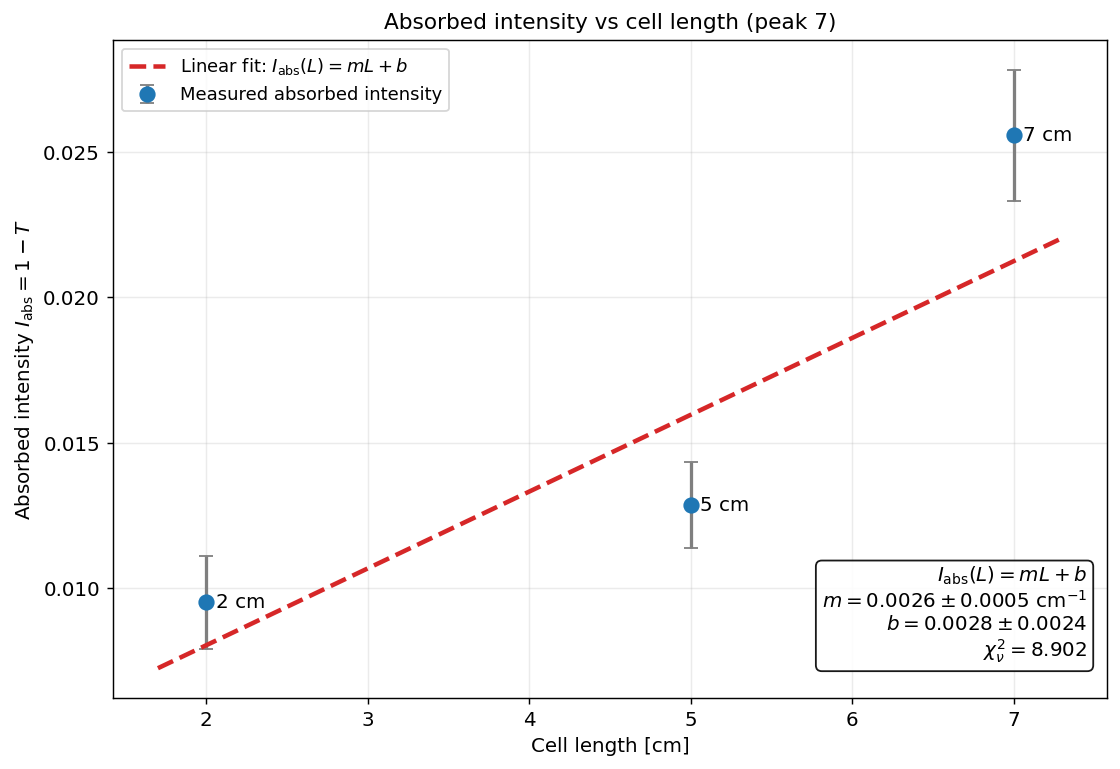

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_FILES = {
    "2 cm": {"path": "scope_23.csv", "L_cm": 2.0},
    "5 cm": {"path": "scope_24.csv", "L_cm": 5.0},
    "7 cm": {"path": "scope_20.csv", "L_cm": 7.0},
}

FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

FPI_MODE_SPACING_GHZ = 149.9348e-3
USE_DESCENDING_BRANCH = True

FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4
CALIB_POLY_DEGREE = 3

FIT_POLY_DEGREE = 2
N_DIPS = 7

# Use peak 7
TARGET_PEAK_NUMBER = 7
TARGET_PEAK_INDEX = TARGET_PEAK_NUMBER - 1

MANUAL_MU_GUESS = np.array([1.27, 2.05, 3.96, 4.25, 7.28, 8.15, 8.91], dtype=float)
MANUAL_A_GUESS = np.array([-0.025, -0.008, -0.060, -0.035, -0.095, -0.020, -0.018], dtype=float)
MANUAL_SIGMA_GUESS = np.array([0.22, 0.20, 0.22, 0.26, 0.32, 0.22, 0.22], dtype=float)

SAVE_FIG = "absorbed_intensity_peak7_linear_fit.png"

# ============================================================
# HELPERS
# ============================================================

def odd(n: int) -> int:
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t: np.ndarray, tri: np.ndarray, use_descending: bool = True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t: np.ndarray, fpi: np.ndarray, degree: int = 3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Lower FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(coeffs, t)
    nu_rel -= nu_rel.min()

    return {
        "nu_rel": nu_rel,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "coeffs": coeffs,
    }

def estimate_off_resonance_baseline(
    nu: np.ndarray,
    y: np.ndarray,
    exclusion_centers=None,
    exclusion_halfwidth: float = 0.35,
    poly_degree: int = 2
):
    if exclusion_centers is None:
        exclusion_centers = MANUAL_MU_GUESS

    mask = np.ones_like(nu, dtype=bool)
    for c in exclusion_centers:
        mask &= np.abs(nu - c) > exclusion_halfwidth

    if np.sum(mask) < 20:
        coeffs = np.polyfit(nu, y, 1)
    else:
        coeffs = np.polyfit(nu[mask], y[mask], poly_degree)

    baseline = np.polyval(coeffs, nu)
    return baseline, coeffs, mask

def poly_background(x: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x: np.ndarray, A: float, mu: float, sigma: float) -> np.ndarray:
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def build_model_function(poly_degree: int, n_dips: int):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x: np.ndarray, y: np.ndarray, poly_degree: int) -> np.ndarray:
    coeffs_guess = np.polyfit(x, y, poly_degree)[::-1]
    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]
    return np.array(p0, dtype=float)

def build_bounds(x: np.ndarray, poly_degree: int):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for i, mu0 in enumerate(MANUAL_MU_GUESS):
        sigma_high = 0.50 if i in [2, 3, 4] else 0.35
        lower += [-1.0, max(x0, mu0 - 0.45), 0.03]
        upper += [0.0, min(x1, mu0 + 0.45), sigma_high]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt: np.ndarray, pcov: np.ndarray, poly_degree: int, n_dips: int):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt: np.ndarray, pcov: np.ndarray, poly_degree: int, n_dips: int):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)
    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def fit_normalized_spectrum(nu_rel: np.ndarray, y_norm: np.ndarray):
    model = build_model_function(FIT_POLY_DEGREE, N_DIPS)
    p0 = build_initial_guess(nu_rel, y_norm, FIT_POLY_DEGREE)
    lb, ub = build_bounds(nu_rel, FIT_POLY_DEGREE)

    popt, pcov = curve_fit(
        model,
        nu_rel, y_norm,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, FIT_POLY_DEGREE, N_DIPS)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, FIT_POLY_DEGREE, N_DIPS)

    fit_total = model(nu_rel, *popt)
    fit_bg = poly_background(nu_rel, poly_coeffs)

    return {
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "popt": popt,
        "pcov": pcov,
    }

def linear_with_offset(x, m, b):
    return m * x + b

# ============================================================
# LOAD, CALIBRATE, NORMALIZE, FIT
# ============================================================

results = {}

for label, meta in CSV_FILES.items():
    df = load_scope_csv(meta["path"])

    t_all = df["time_s"].to_numpy()
    fpi_all = df[FPI_COL].to_numpy()
    abs_all = df[ABS_COL].to_numpy()
    tri_all = df[TRI_COL].to_numpy()

    branch, _ = choose_monotonic_branch(t_all, tri_all, use_descending=USE_DESCENDING_BRANCH)

    t = t_all[branch]
    fpi = fpi_all[branch]
    abs_sig = abs_all[branch]

    cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
    nu_rel = cal["nu_rel"]

    baseline, _, _ = estimate_off_resonance_baseline(nu_rel, abs_sig)
    T_rel = abs_sig / baseline

    fit = fit_normalized_spectrum(nu_rel, T_rel)

    gp = fit["gauss_params"]
    ge = fit["gauss_errs"]

    mu = gp[TARGET_PEAK_INDEX, 1]
    dmu = ge[TARGET_PEAK_INDEX, 1]

    # fitted transmission at selected line center
    T_center = np.interp(mu, nu_rel, fit["fit_total"])

    # absorbed intensity
    I_abs = 1.0 - T_center

    # uncertainty from center shift + residual floor
    T_plus = np.interp(mu + dmu, nu_rel, fit["fit_total"])
    T_minus = np.interp(mu - dmu, nu_rel, fit["fit_total"])
    dI_mu = 0.5 * abs((1.0 - T_plus) - (1.0 - T_minus))

    residuals = T_rel - fit["fit_total"]
    dT_floor = np.std(residuals, ddof=1)
    dI_floor = dT_floor

    dI = np.sqrt(dI_mu**2 + dI_floor**2)

    results[label] = {
        "L_cm": meta["L_cm"],
        "nu_rel": nu_rel,
        "T_rel": T_rel,
        "fit": fit,
        "mu_target": mu,
        "T_center": T_center,
        "I_abs": I_abs,
        "dI_abs": dI,
    }

# ============================================================
# FIT I_abs(L) = mL + b
# ============================================================

labels_sorted = sorted(results.keys(), key=lambda k: results[k]["L_cm"])
L = np.array([results[k]["L_cm"] for k in labels_sorted], dtype=float)
Iabs = np.array([results[k]["I_abs"] for k in labels_sorted], dtype=float)
dIabs = np.array([results[k]["dI_abs"] for k in labels_sorted], dtype=float)

popt, pcov = curve_fit(
    linear_with_offset, L, Iabs,
    sigma=dIabs,
    absolute_sigma=True
)
m_fit, b_fit = popt
dm_fit, db_fit = np.sqrt(np.diag(pcov))

Iabs_fit = linear_with_offset(L, m_fit, b_fit)
chi2 = np.sum(((Iabs - Iabs_fit) / dIabs) ** 2)
ndof = len(L) - 2
chi2_red = chi2 / ndof if ndof > 0 else np.nan

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n================ ABSORBED INTENSITY INPUT VALUES ================\n")
print(f"Using peak {TARGET_PEAK_NUMBER}\n")
for k in labels_sorted:
    r = results[k]
    print(
        f"{k:>6s} : "
        f"L = {r['L_cm']:.1f} cm, "
        f"mu = {r['mu_target']:.5f} GHz, "
        f"T(mu) = {r['T_center']:.6f}, "
        f"I_abs = 1 - T = {r['I_abs']:.6f} ± {r['dI_abs']:.6f}"
    )

print("\n================ LINEAR FIT: I_abs(L) = mL + b ================\n")
print(f"Slope m          = {m_fit:.6f} ± {dm_fit:.6f} cm^-1")
print(f"Intercept b      = {b_fit:.6f} ± {db_fit:.6f}")
print(f"Chi-squared      = {chi2:.6f}")
print(f"Reduced chi^2    = {chi2_red:.6f}")

# ============================================================
# PLOT
# ============================================================

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

fig, ax = plt.subplots(figsize=(8.5, 5.8), constrained_layout=True)

ax.errorbar(
    L, Iabs, yerr=dIabs,
    fmt="o", markersize=8,
    capsize=4,
    color="tab:blue",
    ecolor="tab:gray",
    label="Measured absorbed intensity"
)

L_dense = np.linspace(1.7, 7.3, 300)
ax.plot(
    L_dense,
    linear_with_offset(L_dense, m_fit, b_fit),
    linestyle="--",
    color="tab:red",
    linewidth=2.5,
    label=r"Linear fit: $I_{\mathrm{abs}}(L)=mL+b$"
)

for x, y, name in zip(L, Iabs, labels_sorted):
    ax.text(x + 0.06, y, name, va="center")

ax.set_title(f"Absorbed intensity vs cell length (peak {TARGET_PEAK_NUMBER})")
ax.set_xlabel("Cell length [cm]")
ax.set_ylabel(r"Absorbed intensity $I_{\mathrm{abs}} = 1 - T$")
ax.legend(loc="best", frameon=True)

fit_text = (
    r"$I_{\mathrm{abs}}(L)=mL+b$" "\n"
    rf"$m={m_fit:.4f}\pm{dm_fit:.4f}\ \mathrm{{cm^{{-1}}}}$" "\n"
    rf"$b={b_fit:.4f}\pm{db_fit:.4f}$" "\n"
    rf"$\chi^2_\nu={chi2_red:.3f}$"
)
ax.text(
    0.98, 0.05, fit_text,
    transform=ax.transAxes,
    ha="right", va="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.savefig(SAVE_FIG, dpi=300, bbox_inches="tight")
plt.show()

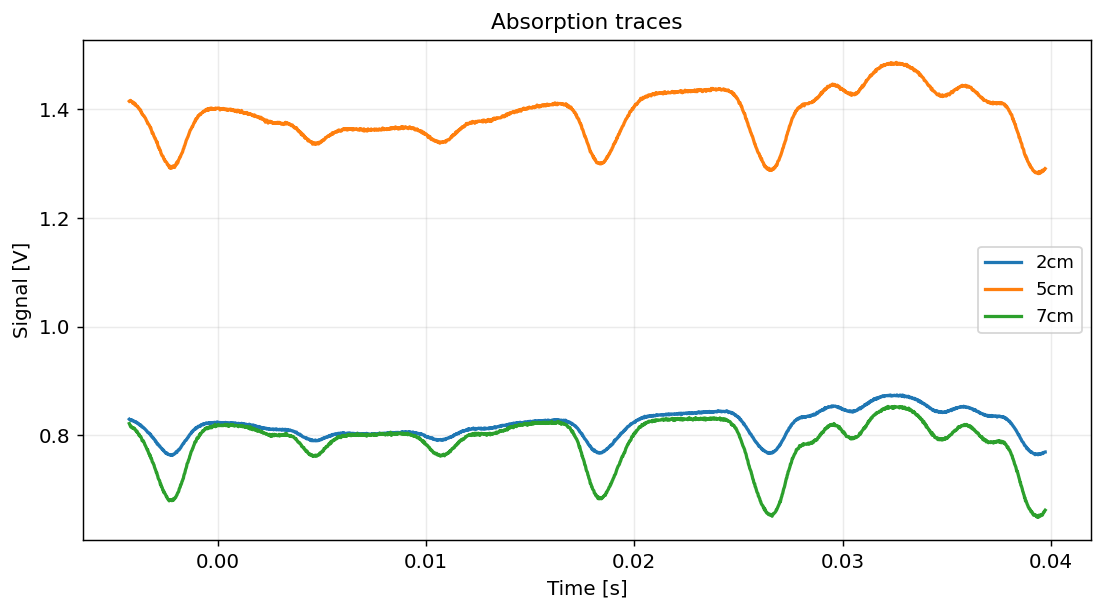

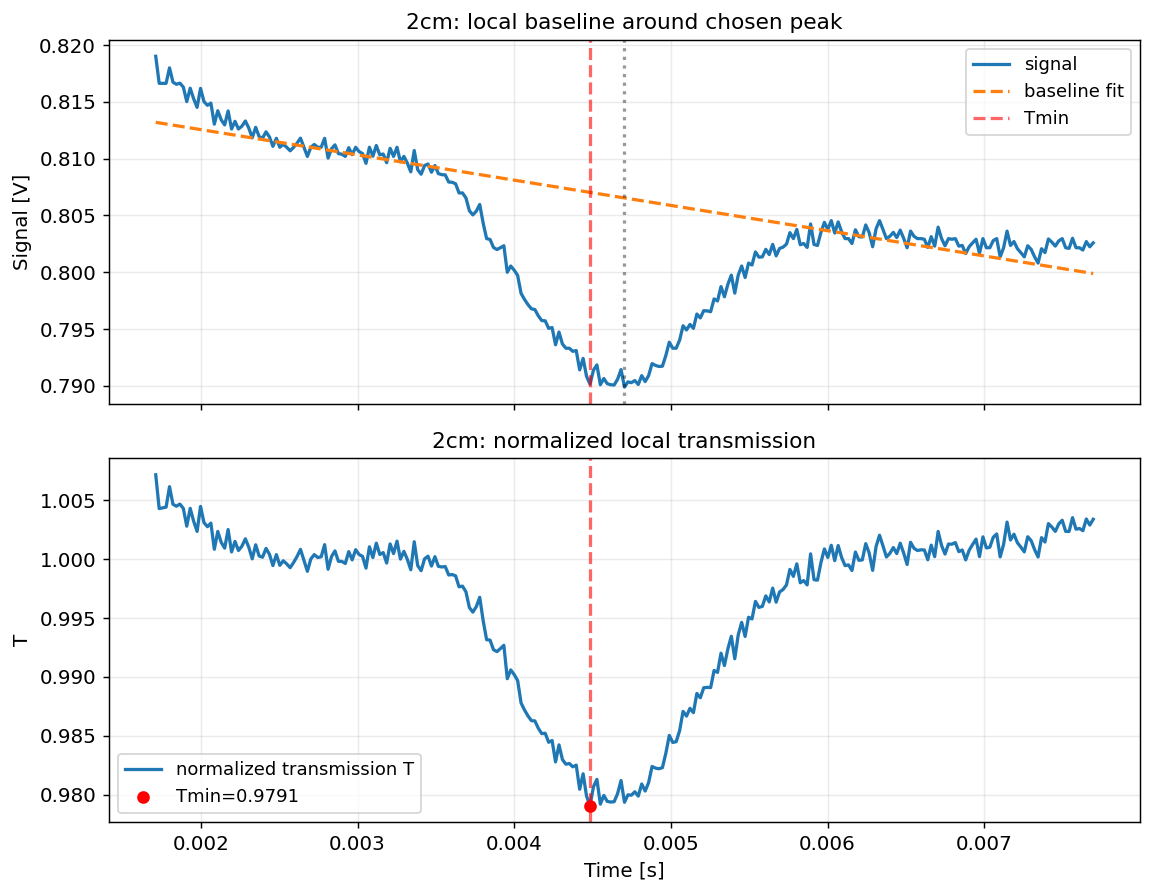

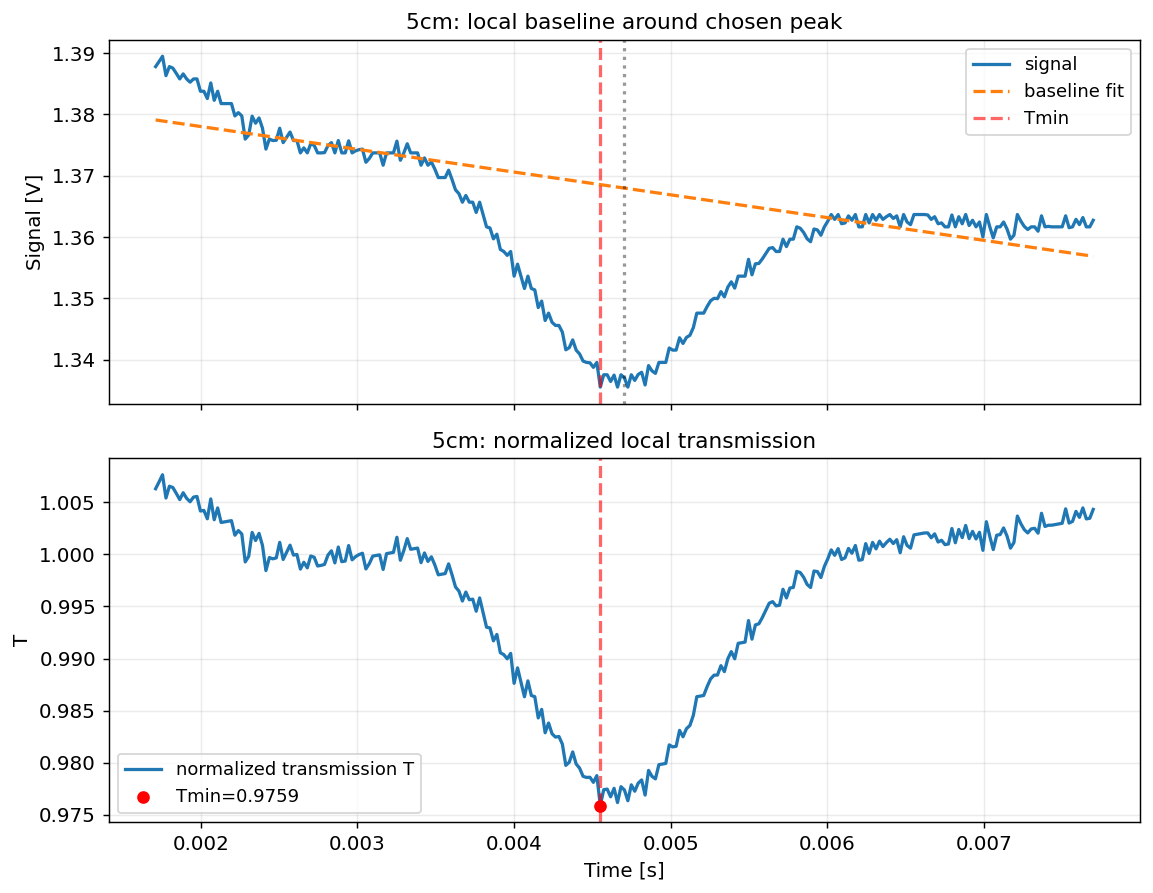

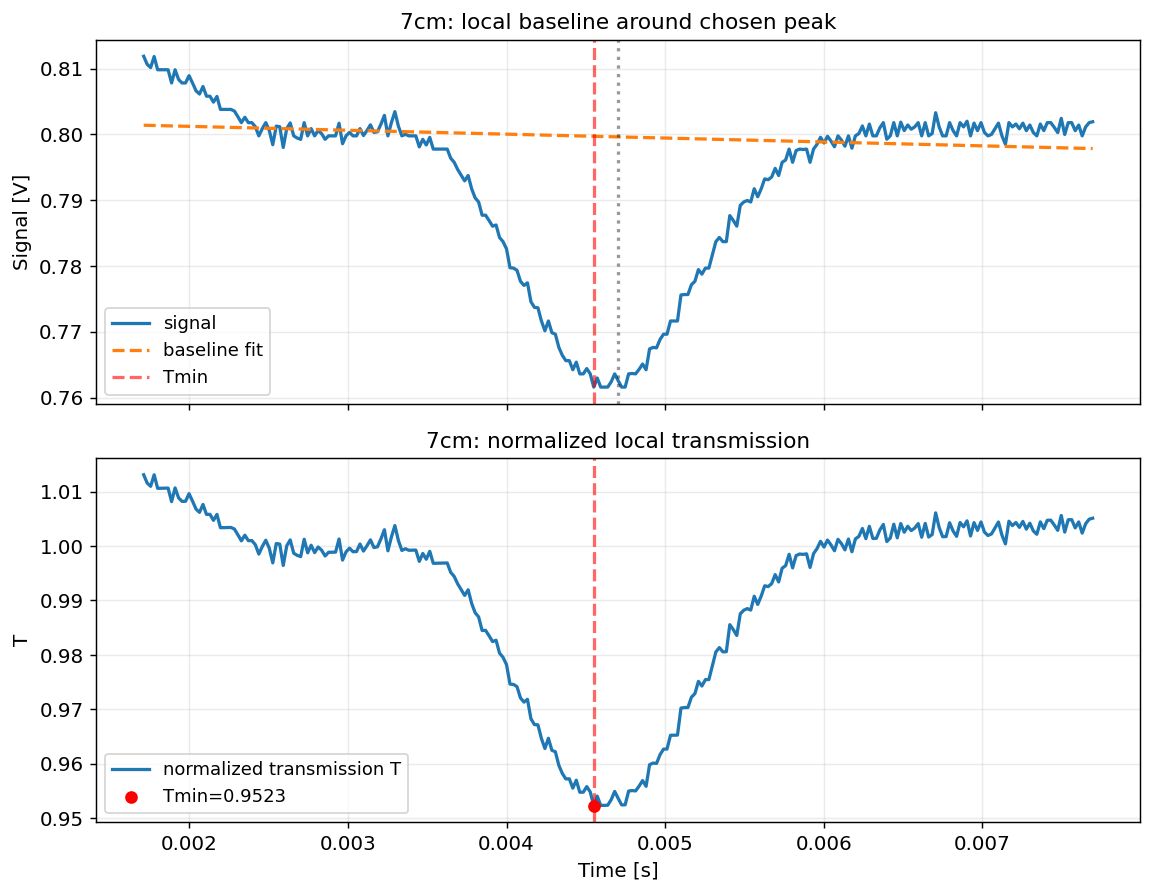


Extracted values for chosen peak:
2cm | L = 2.0 cm | T_min = 0.979073 | OD = 0.021149
5cm | L = 5.0 cm | T_min = 0.975872 | OD = 0.024424
7cm | L = 7.0 cm | T_min = 0.952327 | OD = 0.048847

Lambert-Beer fit:
OD = alpha * L + c
alpha = 0.005188 1/cm
c     = 0.007261
R^2   = 0.744279


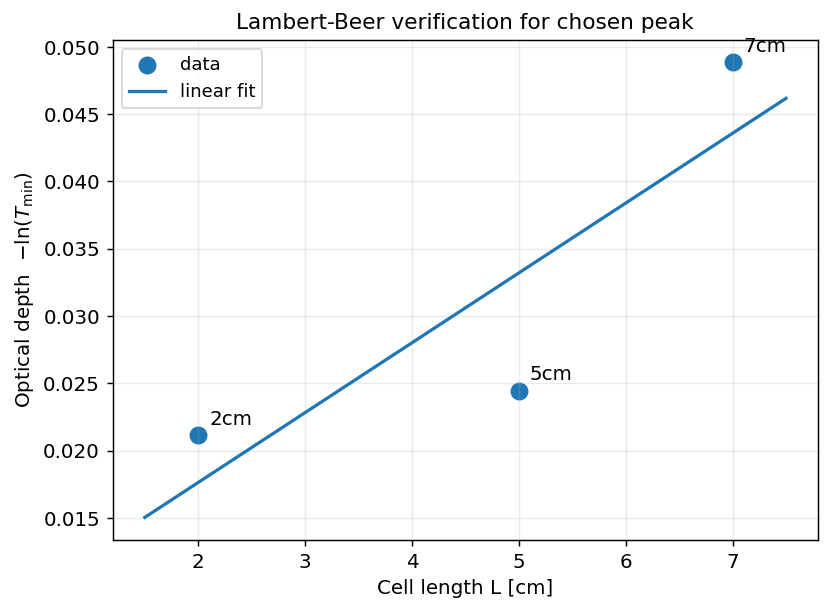


Thin-limit check:
(1 - T_min) = m * L + b
m   = 0.005011 1/cm
b   = 0.007524
R^2 = 0.745501


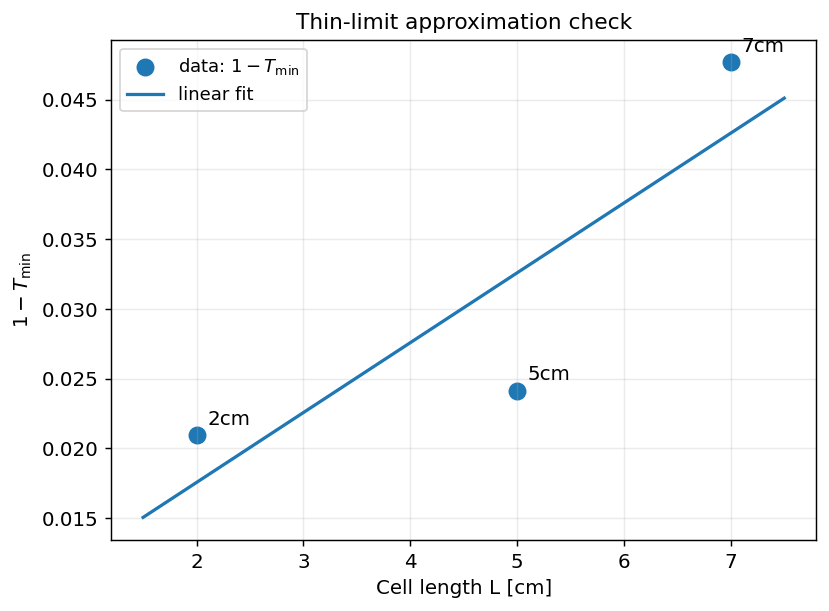

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# 1) Load the oscilloscope CSVs
# ============================================================

FILES = {
    "7cm": "scope_20.csv",   # 7 cm
    "2cm": "scope_23.csv",   # 2 cm
    "5cm": "scope_24.csv",   # 5 cm
}

LENGTHS_CM = {
    "2cm": 2.0,
    "5cm": 5.0,
    "7cm": 7.0,
}

def load_scope_csv(path):
    df = pd.read_csv(path)

    # first row is units, remove it
    df = df.iloc[1:].copy()

    # convert all columns to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna().reset_index(drop=True)
    return df

data = {name: load_scope_csv(path) for name, path in FILES.items()}

# ============================================================
# 2) Choose channels
#    From your files:
#    - channel "2" looks like absorption
#    - channel "3" looks like triangular scan voltage
#    - channel "1" is likely the Fabry-Perot signal
# ============================================================

ABS_COL = "2"
TIME_COL = "x-axis"
TRI_COL = "3"

# ============================================================
# 3) Quick overview plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
for name in ["2cm", "5cm", "7cm"]:
    t = data[name][TIME_COL].to_numpy()
    y = data[name][ABS_COL].to_numpy()
    ax.plot(t, y, label=name)

ax.set_title("Absorption traces")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Signal [V]")
ax.legend()
ax.grid(True)
plt.show()

# ============================================================
# 4) Peak-7 window selection
#
# Adjust these if needed after looking at the plot.
# For your files, a first guess for peak 7 is around 0.0047 s.
#
# window_total: total fit/analysis window around the peak
# window_core:  central region containing the dip itself
# baseline is fit only outside the core but inside total window
# ============================================================

peak7_center_guess = 0.0047   # seconds, adjust if needed
window_total = 0.0030         # +/- around center for local analysis
window_core  = 0.0007         # central dip region excluded from baseline fit

# ============================================================
# 5) Helper: fit local linear baseline and extract Tmin
# ============================================================

def linear(x, a, b):
    return a*x + b

def analyze_peak_local(df, t_center, total_halfwidth, core_halfwidth,
                       time_col=TIME_COL, signal_col=ABS_COL,
                       make_plot=True, label=""):
    t = df[time_col].to_numpy()
    y = df[signal_col].to_numpy()

    # Restrict to local window around the chosen peak
    m_total = (t >= t_center - total_halfwidth) & (t <= t_center + total_halfwidth)
    t_win = t[m_total]
    y_win = y[m_total]

    if len(t_win) < 20:
        raise ValueError(f"Window too small or empty for {label}")

    # Use shoulders (outside the core) to fit baseline
    m_baseline = (np.abs(t_win - t_center) >= core_halfwidth)
    t_base = t_win[m_baseline]
    y_base = y_win[m_baseline]

    if len(t_base) < 6:
        raise ValueError(f"Not enough baseline points for {label}")

    # Linear baseline fit
    popt, _ = curve_fit(linear, t_base, y_base)
    baseline = linear(t_win, *popt)

    # Normalized transmission
    T = y_win / baseline

    # Peak minimum
    i_min = np.argmin(T)
    t_min = t_win[i_min]
    T_min = T[i_min]

    # Optical depth
    OD = -np.log(T_min)

    if make_plot:
        fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

        # Raw signal + baseline
        axes[0].plot(t_win, y_win, label="signal")
        axes[0].plot(t_win, baseline, "--", label="baseline fit")
        axes[0].axvline(t_center, color="k", alpha=0.4, linestyle=":")
        axes[0].axvline(t_min, color="r", alpha=0.6, linestyle="--", label="Tmin")
        axes[0].set_ylabel("Signal [V]")
        axes[0].set_title(f"{label}: local baseline around chosen peak")
        axes[0].grid(True)
        axes[0].legend()

        # Normalized transmission
        axes[1].plot(t_win, T, label="normalized transmission T")
        axes[1].axvline(t_min, color="r", alpha=0.6, linestyle="--")
        axes[1].scatter([t_min], [T_min], color="r", zorder=5,
                        label=f"Tmin={T_min:.4f}")
        axes[1].set_xlabel("Time [s]")
        axes[1].set_ylabel("T")
        axes[1].set_title(f"{label}: normalized local transmission")
        axes[1].grid(True)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return {
        "t_min": t_min,
        "T_min": T_min,
        "OD": OD,
        "baseline_params": popt,
        "t_window": t_win,
        "signal_window": y_win,
        "baseline_window": baseline,
        "T_window": T,
    }

# ============================================================
# 6) Analyze the same peak in all three files
# ============================================================

results = {}
for name in ["2cm", "5cm", "7cm"]:
    results[name] = analyze_peak_local(
        data[name],
        t_center=peak7_center_guess,
        total_halfwidth=window_total,
        core_halfwidth=window_core,
        make_plot=True,
        label=name
    )

# Print extracted transmission and optical depth
print("\nExtracted values for chosen peak:")
for name in ["2cm", "5cm", "7cm"]:
    print(
        f"{name:>3} | L = {LENGTHS_CM[name]:.1f} cm | "
        f"T_min = {results[name]['T_min']:.6f} | "
        f"OD = {results[name]['OD']:.6f}"
    )

# ============================================================
# 7) Lambert-Beer verification:
#    Fit OD = alpha * L + c
#    Ideally c ~ 0 if normalization is perfect
# ============================================================

L = np.array([LENGTHS_CM[name] for name in ["2cm", "5cm", "7cm"]], dtype=float)
OD = np.array([results[name]["OD"] for name in ["2cm", "5cm", "7cm"]], dtype=float)

coeff = np.polyfit(L, OD, 1)
alpha_fit, intercept_fit = coeff
OD_fit = np.polyval(coeff, L)

# R^2
ss_res = np.sum((OD - OD_fit)**2)
ss_tot = np.sum((OD - np.mean(OD))**2)
r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

print("\nLambert-Beer fit:")
print(f"OD = alpha * L + c")
print(f"alpha = {alpha_fit:.6f} 1/cm")
print(f"c     = {intercept_fit:.6f}")
print(f"R^2   = {r2:.6f}")

# Plot
plt.figure(figsize=(7, 5))
plt.scatter(L, OD, s=80, label="data")
L_line = np.linspace(1.5, 7.5, 200)
plt.plot(L_line, alpha_fit*L_line + intercept_fit, label="linear fit")
for name in ["2cm", "5cm", "7cm"]:
    plt.annotate(name, (LENGTHS_CM[name], results[name]["OD"]),
                 textcoords="offset points", xytext=(6, 6))

plt.xlabel("Cell length L [cm]")
plt.ylabel(r"Optical depth  $-\ln(T_{\min})$")
plt.title("Lambert-Beer verification for chosen peak")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 8) Optional: compare with thin-limit approximation
#    In optically thin regime: 1 - T_min ~ alpha * L
# ============================================================

A_thin = np.array([1 - results[name]["T_min"] for name in ["2cm", "5cm", "7cm"]], dtype=float)
coeff_thin = np.polyfit(L, A_thin, 1)
A_fit = np.polyval(coeff_thin, L)

ss_res_thin = np.sum((A_thin - A_fit)**2)
ss_tot_thin = np.sum((A_thin - np.mean(A_thin))**2)
r2_thin = 1 - ss_res_thin/ss_tot_thin if ss_tot_thin > 0 else np.nan

print("\nThin-limit check:")
print(f"(1 - T_min) = m * L + b")
print(f"m   = {coeff_thin[0]:.6f} 1/cm")
print(f"b   = {coeff_thin[1]:.6f}")
print(f"R^2 = {r2_thin:.6f}")

plt.figure(figsize=(7, 5))
plt.scatter(L, A_thin, s=80, label=r"data: $1-T_{\min}$")
plt.plot(L_line, coeff_thin[0]*L_line + coeff_thin[1], label="linear fit")
for name in ["2cm", "5cm", "7cm"]:
    plt.annotate(name, (LENGTHS_CM[name], 1 - results[name]["T_min"]),
                 textcoords="offset points", xytext=(6, 6))

plt.xlabel("Cell length L [cm]")
plt.ylabel(r"$1 - T_{\min}$")
plt.title("Thin-limit approximation check")
plt.grid(True)
plt.legend()
plt.show()


Lambert-Beer verification using peak 7

2 cm: L = 2.0 cm, OD = 0.009563 ± 0.001627
5 cm: L = 5.0 cm, OD = 0.012947 ± 0.001499
7 cm: L = 7.0 cm, OD = 0.025905 ± 0.002316

Fit: OD(L) = m L + b
m = 0.002665 ± 0.000529 cm^-1
b = 0.002756 ± 0.002457
reduced chi^2 = 8.957984


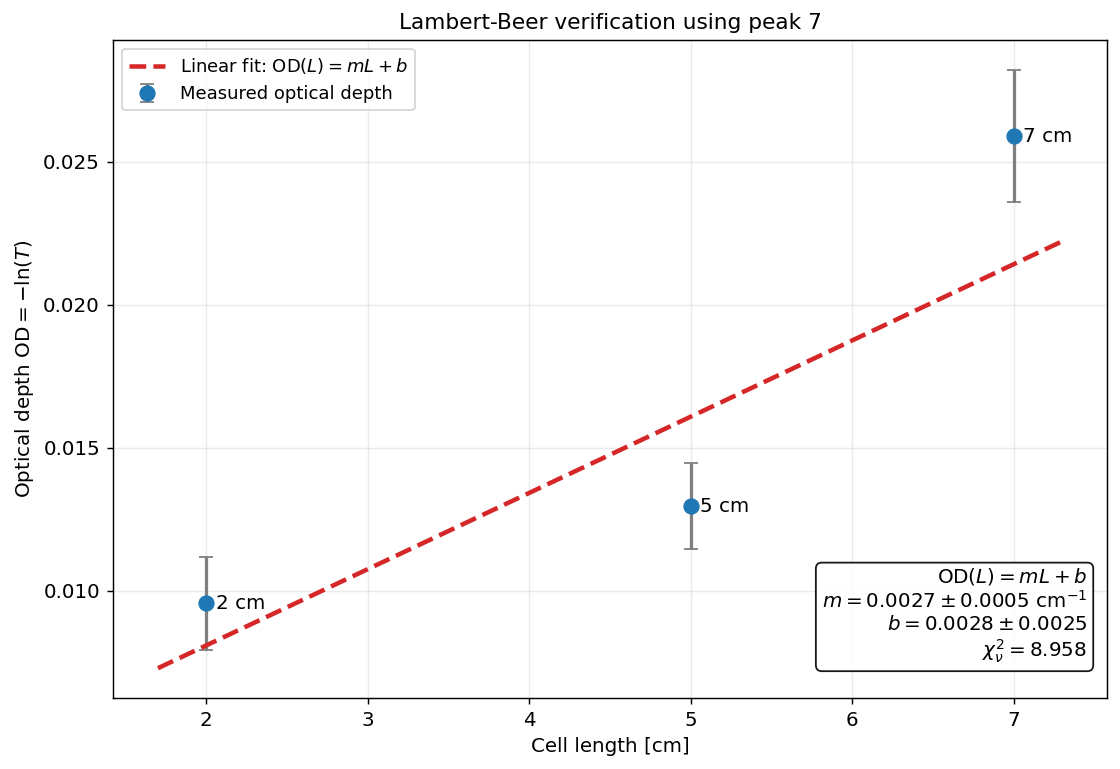

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit

# ============================================================
# USER SETTINGS
# ============================================================

CSV_FILES = {
    "2 cm": {"path": "scope_23.csv", "L_cm": 2.0},
    "5 cm": {"path": "scope_24.csv", "L_cm": 5.0},
    "7 cm": {"path": "scope_20.csv", "L_cm": 7.0},
}

# Column names after loading
FPI_COL = "ch1"
ABS_COL = "ch2"
TRI_COL = "ch3"

# Fabry-Perot calibration
FPI_MODE_SPACING_GHZ = 149.9348e-3
USE_DESCENDING_BRANCH = True
FPI_SAVGOL_WINDOW = 9
FPI_SAVGOL_ORDER = 2
FPI_PEAK_DISTANCE = 10
FPI_PROMINENCE = 2e-4
CALIB_POLY_DEGREE = 3

# Spectrum model
FIT_POLY_DEGREE = 2
N_DIPS = 7

# Target: peak 7
TARGET_PEAK_NUMBER = 7
TARGET_PEAK_INDEX = TARGET_PEAK_NUMBER - 1

# Initial guesses for the 7 dips in relative frequency [GHz]
MANUAL_MU_GUESS = np.array([1.27, 2.05, 3.96, 4.25, 7.28, 8.15, 8.91], dtype=float)
MANUAL_A_GUESS = np.array([-0.025, -0.008, -0.060, -0.035, -0.095, -0.020, -0.018], dtype=float)
MANUAL_SIGMA_GUESS = np.array([0.22, 0.20, 0.22, 0.26, 0.32, 0.22, 0.22], dtype=float)

# Output figure file
SAVE_FIG = "lambert_beer_peak7_OD_fit.png"

# ============================================================
# HELPERS
# ============================================================

def odd(n: int) -> int:
    return n if n % 2 == 1 else n + 1

def load_scope_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1])
    df.columns = ["time_s", "ch1", "ch2", "ch3"]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def choose_monotonic_branch(t: np.ndarray, tri: np.ndarray, use_descending: bool = True):
    tri_s = savgol_filter(tri, odd(101), 2)
    i_max = np.argmax(tri_s)
    i_min = np.argmin(tri_s)

    if i_max < i_min:
        branch = slice(i_max, i_min + 1) if use_descending else slice(0, i_max + 1)
    else:
        branch = slice(i_min, i_max + 1) if use_descending else slice(0, i_min + 1)

    return branch, tri_s

def calibrate_fpi_time_to_frequency(t: np.ndarray, fpi: np.ndarray, degree: int = 3):
    fpi_s = savgol_filter(fpi, odd(FPI_SAVGOL_WINDOW), FPI_SAVGOL_ORDER)

    peak_idx, _ = find_peaks(
        fpi_s,
        distance=FPI_PEAK_DISTANCE,
        prominence=FPI_PROMINENCE
    )

    if len(peak_idx) < 10:
        raise RuntimeError(
            f"Too few FPI peaks found ({len(peak_idx)}). "
            "Try lowering FPI_PROMINENCE or FPI_PEAK_DISTANCE."
        )

    t_peaks = t[peak_idx]
    nu_peaks = np.arange(len(t_peaks), dtype=float) * FPI_MODE_SPACING_GHZ

    coeffs = np.polyfit(t_peaks, nu_peaks, degree)
    nu_rel = np.polyval(coeffs, t)
    nu_rel -= nu_rel.min()

    return {
        "nu_rel": nu_rel,
        "peak_idx": peak_idx,
        "t_peaks": t_peaks,
        "nu_peaks": nu_peaks,
        "coeffs": coeffs,
    }

def estimate_off_resonance_baseline(
    nu: np.ndarray,
    y: np.ndarray,
    exclusion_centers=None,
    exclusion_halfwidth: float = 0.35,
    poly_degree: int = 2
):
    if exclusion_centers is None:
        exclusion_centers = MANUAL_MU_GUESS

    mask = np.ones_like(nu, dtype=bool)
    for c in exclusion_centers:
        mask &= np.abs(nu - c) > exclusion_halfwidth

    if np.sum(mask) < 20:
        coeffs = np.polyfit(nu, y, 1)
    else:
        coeffs = np.polyfit(nu[mask], y[mask], poly_degree)

    baseline = np.polyval(coeffs, nu)
    return baseline, coeffs, mask

def poly_background(x: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeffs):
        y += ci * x**i
    return y

def gaussian_dip(x: np.ndarray, A: float, mu: float, sigma: float) -> np.ndarray:
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def build_model_function(poly_degree: int, n_dips: int):
    def model(x, *p):
        n_poly = poly_degree + 1
        coeffs = p[:n_poly]
        rest = p[n_poly:]

        y = poly_background(x, coeffs)
        for i in range(n_dips):
            A, mu, sigma = rest[3*i:3*i+3]
            y += gaussian_dip(x, A, mu, sigma)
        return y
    return model

def build_initial_guess(x: np.ndarray, y: np.ndarray, poly_degree: int) -> np.ndarray:
    coeffs_guess = np.polyfit(x, y, poly_degree)[::-1]
    p0 = list(coeffs_guess)
    for A0, mu0, s0 in zip(MANUAL_A_GUESS, MANUAL_MU_GUESS, MANUAL_SIGMA_GUESS):
        p0 += [A0, mu0, s0]
    return np.array(p0, dtype=float)

def build_bounds(x: np.ndarray, poly_degree: int):
    x0, x1 = x.min(), x.max()
    lower = []
    upper = []

    for _ in range(poly_degree + 1):
        lower.append(-10.0)
        upper.append(10.0)

    for i, mu0 in enumerate(MANUAL_MU_GUESS):
        sigma_high = 0.50 if i in [2, 3, 4] else 0.35
        lower += [-1.0, max(x0, mu0 - 0.45), 0.03]
        upper += [0.0, min(x1, mu0 + 0.45), sigma_high]

    return np.array(lower), np.array(upper)

def sort_fit_by_mu(popt: np.ndarray, pcov: np.ndarray, poly_degree: int, n_dips: int):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)

    order = np.argsort(gs[:, 1])
    gs_sorted = gs[order].reshape(-1)
    popt_sorted = np.concatenate([poly, gs_sorted])

    idx_map = list(range(n_poly))
    for j in order:
        idx_map.extend([n_poly + 3*j + 0, n_poly + 3*j + 1, n_poly + 3*j + 2])
    idx_map = np.array(idx_map, dtype=int)

    pcov_sorted = pcov[np.ix_(idx_map, idx_map)]
    return popt_sorted, pcov_sorted

def unpack_fit(popt: np.ndarray, pcov: np.ndarray, poly_degree: int, n_dips: int):
    n_poly = poly_degree + 1
    poly = popt[:n_poly]
    gs = popt[n_poly:].reshape(n_dips, 3)
    errs = np.sqrt(np.diag(pcov))
    gerrs = errs[n_poly:].reshape(n_dips, 3)
    return poly, gs, gerrs

def fit_normalized_spectrum(nu_rel: np.ndarray, y_norm: np.ndarray):
    model = build_model_function(FIT_POLY_DEGREE, N_DIPS)
    p0 = build_initial_guess(nu_rel, y_norm, FIT_POLY_DEGREE)
    lb, ub = build_bounds(nu_rel, FIT_POLY_DEGREE)

    popt, pcov = curve_fit(
        model,
        nu_rel, y_norm,
        p0=p0,
        bounds=(lb, ub),
        maxfev=500000
    )

    popt, pcov = sort_fit_by_mu(popt, pcov, FIT_POLY_DEGREE, N_DIPS)
    poly_coeffs, gauss_params, gauss_errs = unpack_fit(popt, pcov, FIT_POLY_DEGREE, N_DIPS)

    fit_total = model(nu_rel, *popt)
    fit_bg = poly_background(nu_rel, poly_coeffs)

    return {
        "poly_coeffs": poly_coeffs,
        "gauss_params": gauss_params,
        "gauss_errs": gauss_errs,
        "fit_total": fit_total,
        "fit_bg": fit_bg,
        "popt": popt,
        "pcov": pcov,
    }

def linear_with_offset(x, m, b):
    return m * x + b

# ============================================================
# MAIN: LOAD, CALIBRATE, NORMALIZE, FIT, EXTRACT PEAK 7
# ============================================================

results = {}

for label, meta in CSV_FILES.items():
    df = load_scope_csv(meta["path"])

    t_all = df["time_s"].to_numpy()
    fpi_all = df[FPI_COL].to_numpy()
    abs_all = df[ABS_COL].to_numpy()
    tri_all = df[TRI_COL].to_numpy()

    branch, _ = choose_monotonic_branch(
        t_all, tri_all, use_descending=USE_DESCENDING_BRANCH
    )

    t = t_all[branch]
    fpi = fpi_all[branch]
    abs_sig = abs_all[branch]

    cal = calibrate_fpi_time_to_frequency(t, fpi, degree=CALIB_POLY_DEGREE)
    nu_rel = cal["nu_rel"]

    baseline, _, _ = estimate_off_resonance_baseline(nu_rel, abs_sig)
    T_rel = abs_sig / baseline

    fit = fit_normalized_spectrum(nu_rel, T_rel)

    gp = fit["gauss_params"]
    ge = fit["gauss_errs"]

    mu = gp[TARGET_PEAK_INDEX, 1]
    dmu = ge[TARGET_PEAK_INDEX, 1]

    T_center = np.interp(mu, nu_rel, fit["fit_total"])

    # Guard against invalid log
    eps = 1e-9
    T_center_clipped = np.clip(T_center, eps, 1 - eps)

    OD = -np.log(T_center_clipped)

    # Uncertainty in OD from peak-center uncertainty and residual floor
    T_plus = np.interp(mu + dmu, nu_rel, fit["fit_total"])
    T_minus = np.interp(mu - dmu, nu_rel, fit["fit_total"])

    T_plus = np.clip(T_plus, eps, 1 - eps)
    T_minus = np.clip(T_minus, eps, 1 - eps)

    OD_plus = -np.log(T_plus)
    OD_minus = -np.log(T_minus)
    dOD_mu = 0.5 * abs(OD_plus - OD_minus)

    residuals = T_rel - fit["fit_total"]
    dT_floor = np.std(residuals, ddof=1)

    # Propagate dT -> dOD = dT / T
    dOD_floor = dT_floor / T_center_clipped

    dOD = np.sqrt(dOD_mu**2 + dOD_floor**2)

    results[label] = {
        "L_cm": meta["L_cm"],
        "mu_target": mu,
        "T_center": T_center_clipped,
        "OD": OD,
        "dOD": dOD,
    }

# ============================================================
# FINAL LINEAR FIT: OD(L) = m L + b
# ============================================================

labels_sorted = sorted(results.keys(), key=lambda k: results[k]["L_cm"])
L = np.array([results[k]["L_cm"] for k in labels_sorted], dtype=float)
OD = np.array([results[k]["OD"] for k in labels_sorted], dtype=float)
dOD = np.array([results[k]["dOD"] for k in labels_sorted], dtype=float)

popt, pcov = curve_fit(
    linear_with_offset,
    L, OD,
    sigma=dOD,
    absolute_sigma=True
)
m_fit, b_fit = popt
dm_fit, db_fit = np.sqrt(np.diag(pcov))

OD_fit = linear_with_offset(L, m_fit, b_fit)
chi2 = np.sum(((OD - OD_fit) / dOD) ** 2)
ndof = len(L) - 2
chi2_red = chi2 / ndof if ndof > 0 else np.nan

# ============================================================
# PRINT ONLY FINAL NUMBERS
# ============================================================

print(f"Lambert-Beer verification using peak {TARGET_PEAK_NUMBER}")
print()
for k in labels_sorted:
    r = results[k]
    print(
        f"{k}: L = {r['L_cm']:.1f} cm, "
        f"OD = {r['OD']:.6f} ± {r['dOD']:.6f}"
    )

print()
print("Fit: OD(L) = m L + b")
print(f"m = {m_fit:.6f} ± {dm_fit:.6f} cm^-1")
print(f"b = {b_fit:.6f} ± {db_fit:.6f}")
print(f"reduced chi^2 = {chi2_red:.6f}")

# ============================================================
# ONLY PLOT THAT MATTERS
# ============================================================

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

fig, ax = plt.subplots(figsize=(8.5, 5.8), constrained_layout=True)

ax.errorbar(
    L, OD, yerr=dOD,
    fmt="o",
    markersize=8,
    capsize=4,
    color="tab:blue",
    ecolor="tab:gray",
    label="Measured optical depth"
)

L_dense = np.linspace(min(L) - 0.3, max(L) + 0.3, 300)
ax.plot(
    L_dense,
    linear_with_offset(L_dense, m_fit, b_fit),
    linestyle="--",
    linewidth=2.5,
    color="tab:red",
    label=r"Linear fit: $\mathrm{OD}(L)=mL+b$"
)

for x, y, name in zip(L, OD, labels_sorted):
    ax.text(x + 0.06, y, name, va="center")

ax.set_title(f"Lambert-Beer verification using peak {TARGET_PEAK_NUMBER}")
ax.set_xlabel("Cell length [cm]")
ax.set_ylabel(r"Optical depth $\mathrm{OD}=-\ln(T)$")
ax.legend(loc="best", frameon=True)

fit_text = (
    r"$\mathrm{OD}(L)=mL+b$" "\n"
    rf"$m={m_fit:.4f}\pm{dm_fit:.4f}\ \mathrm{{cm^{{-1}}}}$" "\n"
    rf"$b={b_fit:.4f}\pm{db_fit:.4f}$" "\n"
    rf"$\chi^2_\nu={chi2_red:.3f}$"
)
ax.text(
    0.98, 0.05, fit_text,
    transform=ax.transAxes,
    ha="right", va="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.savefig(SAVE_FIG, dpi=300, bbox_inches="tight")
plt.show()

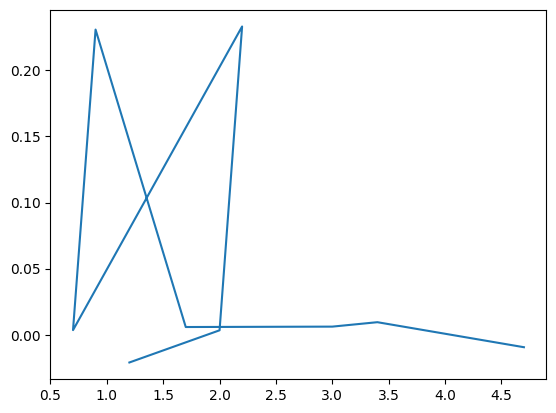

Reduced chi^2 for dataset 1: 0.777
Reduced chi^2 for dataset 2: 0.552
Reduced chi^2 for dataset 3: 1.176
Reduced chi^2 for dataset 4: 0.302
Reduced chi^2 for dataset 5: 0.406
Reduced chi^2 for dataset 6: 0.636
Reduced chi^2 for dataset 7: 0.783
Reduced chi^2 for dataset 8: 0.903
Reduced chi^2 for dataset 9: 0.898


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as scp
from scipy.optimize import curve_fit 
from scipy.signal import find_peaks, savgol_filter
import copy

def read_oscilloscope_csv(file_path):
    # skiprows=2 skips the 'x-axis...' and 'second...' header rows
    # usecols=[0, 1, 2, 3] ensures we grab all four columns provided in your format
    df = pd.read_csv(
        file_path, 
        skiprows=2, 
        header=None, 
        usecols=[0, 1, 2, 3], 
        names=['Time', 'Voltage1', 'Voltage2', 'Voltage3']
    )
    
    # Convert to numeric (handles the scientific notation E-03 etc. automatically)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # dropna() will remove the line '-37.55000E-03,,,' because the voltages are NaN
    return df.dropna().reset_index(drop=True)
    


def sinfit(x,x_0,a,b,c,d):
    return a*np.sin((x-x_0)*b)**2 +c + d*x

def sinfit2(x,x_0,a,b,c,d):
    return a*np.sin((x-x_0)*b)**2
    
def lorentzian(x,x0,a,b,c,d):
    return a*(b**2)/( (x-x0)**2 + b**2 ) +c + d*x
        
pump_beam_power = np.array([4.7, 3.4,  3, 1.7, 0.9, 0.7, 2.2, 2.0, 1.2 ]) #mW
power_err = 0.1
data_name = np.array(["scope_27.csv","scope_28.csv","scope_29.csv", "scope_30.csv", "scope_31.csv", "scope_32.csv", "scope_33.csv", "scope_34.csv", "scope_35.csv"]) 

array_pars = []
array_covs = []
chi = []
edg = [(0.042077, 0.0422566), (0.042041, 0.042281), (0.042048, 0.04227), (0.042047, 0.042266), (0.042005, 0.042259), (0.041984, 0.042289), (0.041987, 0.042226), (0.04197, 0.042257), (0.041814, 0.042255)]

for d in range(len(data_name)): 
    
    fpi = read_oscilloscope_csv(data_name[d])
    fpi["Time"] = fpi["Time"]
    fpi = fpi[(fpi["Time"] >=6/148) & (fpi["Time"] <= 9.5/148) ]
    fpi["Voltage2"] = fpi["Voltage2"]/fpi["Voltage2"].iloc[0]
       
    special = fpi[ (fpi["Time"] > 19.7/391) & (fpi["Time"] < 20.2/391) ]
    popt1,_ = curve_fit(sinfit, special["Time"], special["Voltage2"], p0 = [20.5/391, 0.0125, 391*np.pi/2, 1.18, 0], maxfev = 10000)
    
    special1 = fpi[ (fpi["Time"] > 19.5/391) & (fpi["Time"] < 20.7/391) ]
    popt_back, cov_back = curve_fit(sinfit, special1["Time"], special1["Voltage2"], p0 = popt1, maxfev = 10000)
    
    fpi["Voltage2"] = fpi["Voltage2"] - sinfit(fpi["Time"], *popt_back)
    
    prefiltered = copy.deepcopy(fpi)
    fpi["Voltage2"] = savgol_filter(fpi["Voltage2"], window_length=11, polyorder=3)
    
    
    
    intervals_pre = [edg[d]]
    

    for x in intervals_pre:
        start, end = x    
        intervall = prefiltered["Time"][(prefiltered["Time"] < end) & (prefiltered["Time"] >= start) ]
        vals = fpi["Voltage2"][(prefiltered["Time"] < end) & (prefiltered["Time"] >= start) ]
        p0 = [ (start + end)/2, 0.001, (start- end)/2, 1.125, 0 ]
        popt, cov = curve_fit(lorentzian, intervall, vals, p0 = p0, maxfev = 10000)
        array_pars.append(popt)
        array_covs.append(cov)
        chi_vals = prefiltered["Voltage2"][(prefiltered["Time"] < end) & (prefiltered["Time"] >= start) ]    
        chi.append(np.sum((( chi_vals - lorentzian(intervall, *popt))/0.00078 )**2)/(len(intervall) - len(popt)))
        axis = np.linspace(start, end, 1000)
        #if x == intervals_pre[len(intervals_pre) - 1]:
            #plt.plot(axis, lorentzian(axis,*popt), color = "red", label = "Fitted Lorentzian Functions") 
        #else:
            #plt.plot(axis, lorentzian(axis,*popt), color = "red") 
            
    
    #plt.plot(prefiltered["Time"], prefiltered["Voltage2"], color = "black", label = "Saturation Spectroscopy Data", alpha = 0.5)
    #plt.plot(prefiltered_presmooth["Time"], prefiltered_presmooth["Voltage2"], color = "gray", alpha = 0.2)
    #plt.xlabel("Oscilloscope Time (s)")
    #plt.ylabel("Signal Strenght (V + arbitrary shift)")
    #plt.legend()
    #plt.show()
plt.plot(pump_beam_power, [x[1] for x in array_pars])
plt.show()
#print reduced chi squared values
for i in range(len(chi)):
    print(f"Reduced chi^2 for dataset {i+1}: {chi[i]:.3f}")
    



Fit results:
A_inf = 0.0104385 ± 0.0061 V
P_sat = 2.05898 ± 2.5 mW
Reduced chi^2 = 3.913


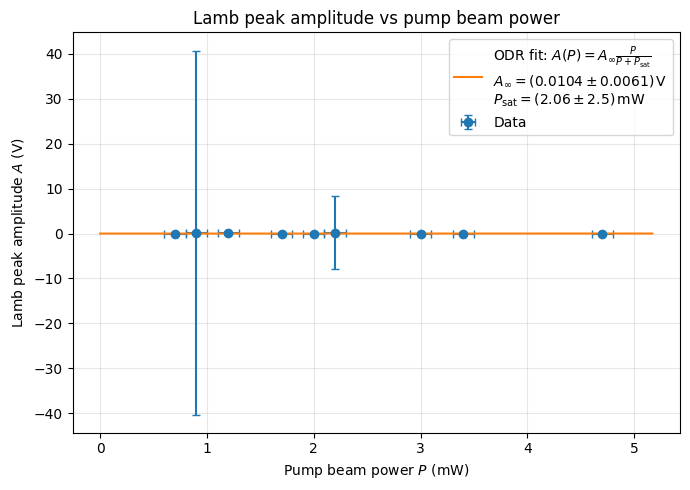

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr

# -----------------------------
# DATA FROM YOUR FIT CODE
# -----------------------------
pump_beam_power = np.array([4.7, 3.4, 3.0, 1.7, 0.9, 0.7, 2.2, 2.0, 1.2], dtype=float)
power_err = np.full_like(pump_beam_power, 0.1, dtype=float)

# amplitudes from your Lorentzian fits:
# array_pars is the list you already filled in your loop
amplitude_V = np.array([pars[1] for pars in array_pars], dtype=float)

# if your Lamb signal is fitted as a dip, make amplitudes positive for the saturation fit
amplitude_V = np.abs(amplitude_V)

# use covariance matrix from curve_fit to estimate amplitude uncertainties
amplitude_err_V = np.array([np.sqrt(cov[1, 1]) for cov in array_covs], dtype=float)

# sort for nicer plotting
idx = np.argsort(pump_beam_power)
x = pump_beam_power[idx]
y = amplitude_V[idx]
sx = power_err[idx]
sy = amplitude_err_V[idx]

# -----------------------------
# SATURATION MODEL
# analogous to the 1.0 report:
# I(P) ∝ P / (P + P_sat)
# here amplitude A is proportional to intensity
# -----------------------------
def sat_model(beta, P):
    A_inf, P_sat = beta
    return A_inf * P / (P + P_sat)

model = odr.Model(sat_model)
data = odr.RealData(x, y, sx=sx, sy=sy)

A_inf_guess = np.max(y)
P_sat_guess = np.median(x)

odr_fit = odr.ODR(data, model, beta0=[A_inf_guess, P_sat_guess])
out = odr_fit.run()

A_inf, P_sat = out.beta
A_inf_err, P_sat_err = out.sd_beta

# reduced chi^2 using vertical residuals for a simple diagnostic
y_fit_data = sat_model(out.beta, x)
dof = len(x) - len(out.beta)
chi2_red = np.sum(((y - y_fit_data) / sy) ** 2) / dof if dof > 0 else np.nan

print("Fit results:")
print(f"A_inf = {A_inf:.6g} ± {A_inf_err:.2g} V")
print(f"P_sat = {P_sat:.6g} ± {P_sat_err:.2g} mW")
print(f"Reduced chi^2 = {chi2_red:.3f}")

# -----------------------------
# PLOT
# -----------------------------
x_plot = np.linspace(0, 1.1 * np.max(x), 500)
y_plot = sat_model(out.beta, x_plot)

plt.figure(figsize=(7, 5))
plt.errorbar(
    x, y, xerr=sx, yerr=sy,
    fmt='o', capsize=3, label='Data'
)
plt.plot(
    x_plot, y_plot,
    label=(
        r'ODR fit: $A(P)=A_\infty \frac{P}{P+P_{\mathrm{sat}}}$' + "\n" +
        rf'$A_\infty = ({A_inf:.3g}\pm{A_inf_err:.2g})\,\mathrm{{V}}$' + "\n" +
        rf'$P_{{\mathrm{{sat}}}} = ({P_sat:.3g}\pm{P_sat_err:.2g})\,\mathrm{{mW}}$'
    )
)

plt.xlabel('Pump beam power $P$ (mW)')
plt.ylabel('Lamb peak amplitude $A$ (V)')
plt.title('Lamb peak amplitude vs pump beam power')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("amplitude_vs_power_fit.png", dpi=300)
plt.show()

Fit results:
I_inf = 1.65245e-06 ± 4.2e-07 V·s
P_sat = 0.0313275 ± 0.4 mW
Reduced chi^2 = 3.190


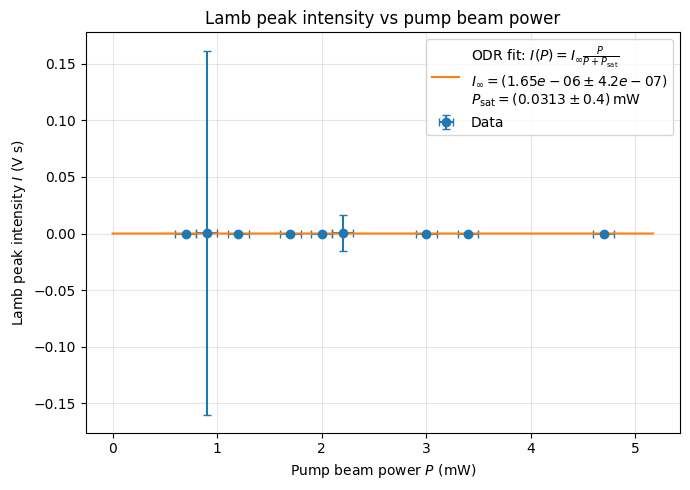

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr

# -----------------------------
# DATA FROM YOUR EXISTING FITS
# -----------------------------
pump_beam_power = np.array([4.7, 3.4, 3.0, 1.7, 0.9, 0.7, 2.2, 2.0, 1.2], dtype=float)
power_err = np.full_like(pump_beam_power, 0.1, dtype=float)

# From your Lorentzian:
# pars = [x0, a, b, c, d]
# a = amplitude, b = HWHM
a_vals = np.array([pars[1] for pars in array_pars], dtype=float)
b_vals = np.array([pars[2] for pars in array_pars], dtype=float)

# Physical intensity-like quantity = Lorentzian area
intensity = np.pi * np.abs(a_vals) * np.abs(b_vals)

# Error propagation for I = pi * a * b
# sigma_I^2 = (pi*b*sigma_a)^2 + (pi*a*sigma_b)^2
sigma_a = np.array([np.sqrt(cov[1, 1]) for cov in array_covs], dtype=float)
sigma_b = np.array([np.sqrt(cov[2, 2]) for cov in array_covs], dtype=float)

intensity_err = np.pi * np.sqrt((np.abs(b_vals) * sigma_a)**2 + (np.abs(a_vals) * sigma_b)**2)

# Sort by power for plotting
idx = np.argsort(pump_beam_power)
x = pump_beam_power[idx]
y = intensity[idx]
sx = power_err[idx]
sy = intensity_err[idx]

# -----------------------------
# SATURATION MODEL
# I(P) = I_inf * P / (P + P_sat)
# -----------------------------
def sat_model(beta, P):
    I_inf, P_sat = beta
    return I_inf * P / (P + P_sat)

model = odr.Model(sat_model)
data = odr.RealData(x, y, sx=sx, sy=sy)

I_inf_guess = np.max(y)
P_sat_guess = np.median(x)

odr_fit = odr.ODR(data, model, beta0=[I_inf_guess, P_sat_guess])
out = odr_fit.run()

I_inf, P_sat = out.beta
I_inf_err, P_sat_err = out.sd_beta

# Simple reduced chi^2 diagnostic
y_fit_data = sat_model(out.beta, x)
dof = len(x) - len(out.beta)
chi2_red = np.sum(((y - y_fit_data) / sy) ** 2) / dof if dof > 0 else np.nan

print("Fit results:")
print(f"I_inf = {I_inf:.6g} ± {I_inf_err:.2g} V·s")
print(f"P_sat = {P_sat:.6g} ± {P_sat_err:.2g} mW")
print(f"Reduced chi^2 = {chi2_red:.3f}")

# -----------------------------
# PLOT
# -----------------------------
x_plot = np.linspace(0, 1.1 * np.max(x), 500)
y_plot = sat_model(out.beta, x_plot)

plt.figure(figsize=(7,5))
plt.errorbar(
    x, y, xerr=sx, yerr=sy,
    fmt='o', capsize=3, label='Data'
)
plt.plot(
    x_plot, y_plot,
    label=(
        r'ODR fit: $I(P)=I_\infty \frac{P}{P+P_{\mathrm{sat}}}$' + "\n" +
        rf'$I_\infty = ({I_inf:.3g}\pm{I_inf_err:.2g})$' + "\n" +
        rf'$P_{{\mathrm{{sat}}}} = ({P_sat:.3g}\pm{P_sat_err:.2g})\,\mathrm{{mW}}$'
    )
)

plt.xlabel('Pump beam power $P$ (mW)')
plt.ylabel('Lamb peak intensity $I$ (V s)')
plt.title('Lamb peak intensity vs pump beam power')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("intensity_vs_power_fit.png", dpi=300)
plt.show()